In [3]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

# Exploring speed fits
1. Exponential (here)
2. Hill
3. Time first active

## Loading in activities

In [4]:
active_tile_activities_count_filtered = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000,-0.114075,0.120087
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383,-0.498641,0.803710
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723,0.282038,1.251861
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393,0.125816,1.429790
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000,NaN,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881,NaN,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294,NaN,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377,NaN,NaN


## Trying exponential fit

In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm

def rising_exponential(t, A, k, C):
    """Rising exponential: A*(1-exp(-k*t)) + C"""
    return A * (1 - np.exp(-k * t)) + C

def fit_rising_exponentials(df, time_col="time", activity_col="activity", error_col="error",
                            min_points=4, subtract_baseline=True, verbose=True):
    """
    Fit a rising exponential to each ADseq in the DataFrame and return fit metrics including R².
    """
    results = []
    grouped = df.groupby("ADseq")
    iterator = grouped.items() if not verbose else tqdm(grouped, desc="Fitting")
    
    for adseq, grp in iterator:
        grp = grp.sort_values(time_col)
        
        t = grp[time_col].values
        y = grp[activity_col].values
        if error_col in grp.columns and grp[error_col].notna().any():
            sigma = grp[error_col].values
            sigma = None if np.all(np.isnan(sigma)) else sigma
        else:
            sigma = None
        
            
        #sigma = grp[error_col].values if error_col in grp else None

        # subtract baseline if requested
        if subtract_baseline:
            baseline = y[0]
            y = y - baseline
            y = np.clip(y, 0, None)
        
        if len(t) < min_points:
            results.append({
                "ADseq": adseq,
                "A": np.nan, "k": np.nan, "C": np.nan,
                "t_half": np.nan, "t_half_obsmax": np.nan,
                "r_squared": np.nan,
                "flag": "too_few_points"
            })
            continue

        # initial guesses
        C0 = 0 if subtract_baseline else y[0]
        A0 = y[-1] - C0
        k0 = 1 / (t[-1] / 2 if t[-1] != 0 else 1)

        try:
            popt, pcov = curve_fit(
                rising_exponential, t, y,
                p0=[A0, k0, C0],
                sigma=sigma,
                absolute_sigma=True if sigma is not None else False,
                bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=10000
            )
            perr = np.sqrt(np.diag(pcov))

            A, k, C = popt
            A_err, k_err, C_err = perr

            # half-life
            t_half = np.log(2) / k
            t_half_err = np.log(2) / (k ** 2) * k_err

            # --- model-interpolated half-life (50% of observed max) ---
            t_grid = np.linspace(t.min(), t.max(), 500)
            y_model = rising_exponential(t_grid, A, k, C)
            
            obs_max = np.max(y_model)  # <-- was np.max(y)
            threshold = 0.5 * obs_max
            
            idx = np.argmin(np.abs(y_model - threshold))
            t_half_model_empirical = t_grid[idx]
            
            # dense time grid for smooth inversion
            t_grid = np.linspace(t.min(), t.max(), 500)
            
            y_model = rising_exponential(t_grid, A, k, C)
            

            # compute R²
            y_fit = rising_exponential(t, A, k, C)
            ss_res = np.sum((y - y_fit) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

            results.append({
                "ADseq": adseq,
                "A": A, "A_err": A_err,
                "k": k, "k_err": k_err,
                "C": C, "C_err": C_err,
                "t_half": t_half,
                "t_half_err": t_half_err,
                "obs_max": obs_max,
                "t_half_model_empirical": t_half_model_empirical,
                "r_squared": r_squared,
                "flag": "ok"
            })

        except Exception as e:
            results.append({
                "ADseq": adseq,
                "A": np.nan, "k": np.nan, "C": np.nan,
                "t_half": np.nan, "t_half_obsmax": np.nan,
                "r_squared": np.nan,
                "flag": f"fit_error: {e}"
            })

    return pd.DataFrame(results)

In [6]:
fit_results = fit_rising_exponentials(
    active_tile_activities_count_filtered,
    time_col="time",
    activity_col="activity",
    error_col="error",
    min_points=5,
    subtract_baseline=False,
    verbose=True
)

print(fit_results['flag'].value_counts())

Fitting: 100%|██████████| 4713/4713 [01:03<00:00, 74.09it/s] 

ok                                                           4679
too_few_points                                                 19
fit_error: Residuals are not finite in the initial point.      15
Name: flag, dtype: int64


In [7]:
fit_results

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.530625,0.319867,6.022144,1.926989,4.035523,4.569138,0.972274,ok,NaN
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,0.601177,0.059638,9.289001,7.834024,1.838727,3.486974,0.960851,ok,NaN
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,-0.066138,0.040876,4.727820,0.548043,2.102846,4.869739,0.985961,ok,NaN
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,-0.286056,0.118027,4.346844,0.528314,1.690053,5.230461,0.995732,ok,NaN
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,1.109990,0.154746,4.455660,0.689937,3.607231,2.044088,0.998874,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,3.368061,0.071460,0.141788,0.007293,0.069468,0.051669,4.888605,0.251443,3.389661,4.629259,0.999213,ok,NaN
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,3.441662,0.104211,0.157731,0.008328,0.451281,0.102140,4.394499,0.232036,3.862623,3.547094,0.990357,ok,NaN
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,2.523455,0.092592,0.133525,0.011832,0.311140,0.065568,5.191132,0.460007,2.788641,4.208417,0.997692,ok,NaN
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.689938,0.100656,0.055910,0.007066,0.016752,0.031002,12.397552,1.566757,1.390878,9.198397,0.998031,ok,NaN


## Filtering to reasonable fits and plotting

In [8]:
fit_results["A+C"] = fit_results["A"] + fit_results["C"]
fit_results["A*k"] = fit_results["A"] * fit_results["k"]
fit_results["1/k"] = 1 / fit_results["k"]
fit_results

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.530625,0.319867,6.022144,1.926989,4.035523,4.569138,0.972274,ok,NaN,4.150082,0.416598,8.688118
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,0.601177,0.059638,9.289001,7.834024,1.838727,3.486974,0.960851,ok,NaN,1.986402,0.103366,13.401196
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,-0.066138,0.040876,4.727820,0.548043,2.102846,4.869739,0.985961,ok,NaN,2.129853,0.321955,6.820803
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,-0.286056,0.118027,4.346844,0.528314,1.690053,5.230461,0.995732,ok,NaN,1.706721,0.317768,6.271170
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,1.109990,0.154746,4.455660,0.689937,3.607231,2.044088,0.998874,ok,NaN,3.630930,0.392171,6.428159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,3.368061,0.071460,0.141788,0.007293,0.069468,0.051669,4.888605,0.251443,3.389661,4.629259,0.999213,ok,NaN,3.437529,0.477552,7.052766
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,3.441662,0.104211,0.157731,0.008328,0.451281,0.102140,4.394499,0.232036,3.862623,3.547094,0.990357,ok,NaN,3.892943,0.542856,6.339923
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,2.523455,0.092592,0.133525,0.011832,0.311140,0.065568,5.191132,0.460007,2.788641,4.208417,0.997692,ok,NaN,2.834594,0.336945,7.489220
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.689938,0.100656,0.055910,0.007066,0.016752,0.031002,12.397552,1.566757,1.390878,9.198397,0.998031,ok,NaN,1.706690,0.094484,17.885887


In [9]:
total = len(fit_results)

conditions = {
    "flag == 'ok'":         fit_results['flag'] == 'ok',
    "A_err < A":            fit_results["A_err"] < fit_results["A"],
    "k_err < k":            fit_results["k_err"].astype(float) < fit_results["k"],
    "r_squared > 0.7":      fit_results['r_squared'] > 0.7,
    "A+C < 2*obs_max":      fit_results["A+C"] < 2 * fit_results["obs_max"],
}

for name, mask in conditions.items():
    n = mask.sum()
    print(f"{name:25s}  {n:>6} / {total}  ({100*n/total:.1f}%)")

flag == 'ok'                 4679 / 4713  (99.3%)
A_err < A                    4521 / 4713  (95.9%)
k_err < k                    4295 / 4713  (91.1%)
r_squared > 0.7              4545 / 4713  (96.4%)
A+C < 2*obs_max              4387 / 4713  (93.1%)


In [10]:
#max_time = activities['time'].max()

ok = fit_results[
    (fit_results['flag'] == 'ok') &
    (fit_results["A_err"] < fit_results["A"]) &
    (fit_results["k_err"].astype(float) < fit_results["k"]) &
    (fit_results['k_err'] > 0) & 
    (fit_results['r_squared'] > 0.7) & 
    (fit_results["A+C"] < 2 * fit_results["obs_max"])
].copy()

print(f"Keeping {len(ok)} / {len(fit_results)} sequences ({100*len(ok)/len(fit_results):.1f}%)")

Keeping 4107 / 4713 sequences (87.1%)


In [11]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/exponential_fit.csv")

In [12]:
ok.sort_values(by = "k", ascending = False)

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
4036,TAGDPWFPLFPQESTTATKDVTSIEEIQKLQTDQSPALNG,2.185279,0.337580,0.583590,0.578067,-1.492242,0.289627,1.187729,1.176488,0.693037,3.126253,0.956871,ok,NaN,0.693037,1.275308,1.713531
976,FAPPQSDFVLYDQPAQVSQRPLRAPSVPQPGHTFNNGQHF,1.331876,0.006664,0.452034,0.009756,-0.910342,0.005664,1.533395,0.033093,0.421533,4.088176,0.999953,ok,NaN,0.421534,0.602054,2.212222
3564,SLPAQSPQHKSHQDFSLPDPQPQPHQDFVLFERSPSVRST,0.948860,0.021506,0.439665,0.041556,-0.428759,0.018252,1.576533,0.149011,0.520099,2.945892,0.999026,ok,NaN,0.520101,0.417181,2.274457
2673,PCSYPSTDVDLDDFTVFEGGASTAFSSPAVASSFDFSSGA,2.572422,0.039715,0.438980,0.028211,2.432783,0.033703,1.578996,0.101473,5.005199,0.060120,0.999548,ok,NaN,5.005204,1.129241,2.278009
1535,HDTWFPLFAQDTSVAAGPVAGGVSASPASRPVDDIEESET,0.830838,0.052709,0.430380,0.111070,-0.444501,0.044686,1.610548,0.415643,0.386335,3.366733,0.992421,ok,NaN,0.386337,0.357576,2.323529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,HLGTTDFESINHPAPASDSVQTISPKDIMMDTMSAPPSTT,2.666062,0.860824,0.025502,0.012247,0.781165,0.057890,27.179960,13.052487,2.206698,5.050100,0.993322,ok,NaN,3.447227,0.067990,39.212394
1662,IHSSVIGSIFEDPDAETAPMFEPREDSSSWEPLFKEEDDL,2.570305,0.192025,0.025368,0.002813,0.416752,0.012775,27.323612,3.030021,1.786264,8.056112,0.999645,ok,NaN,2.987057,0.065204,39.419639
1780,KCPLLLHCGETITIGEPSDLNLFDALVLGAKRIGHGYALA,2.812996,1.452758,0.025054,0.017188,0.816917,0.054427,27.666017,18.979570,2.303302,5.050100,0.978497,ok,NaN,3.629913,0.070477,39.913625
293,ASPQTDFVLYDQPAPPRRAPSAPQPAPTFNNGQHFYANSA,3.198762,0.746596,0.019755,0.006285,0.513232,0.029721,35.087669,11.163676,1.943511,7.815631,0.998230,ok,NaN,3.711994,0.063191,50.620805


In [13]:
not_ok = fit_results[~fit_results["ADseq"].isin(ok["ADseq"])]
not_ok

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
5,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,55047.252939,5.640412e-12,5.331843e-07,4.206800e-07,-0.145534,0.294459,1.300014e+06,1.025705e+06,0.734969,17.494990,0.985431,ok,NaN,55047.107405,0.029350,1.875524e+06
9,AAGLSPLTSSSDSTRSPSPADVELEEFTAFEGGANTAFSS,1.790065,1.240841e+00,4.657282e-02,6.301255e-02,0.539097,0.276705,1.488308e+01,2.013666e+01,1.886493,5.470942,0.857409,ok,NaN,2.329162,0.083368,2.147175e+01
14,AALPADSKSEVSHKSSDEGEPPPPYTEGFSPLHSFSYMMA,1.148108,1.673629e+00,5.325362e-02,1.591986e-01,1.107606,0.458530,1.301596e+01,3.891045e+01,2.023360,0.000000,0.981055,ok,NaN,2.255714,0.061141,1.877806e+01
22,AARKSRERKAQRLEELEAKIEELIAERDRWKNLALAHGAS,0.755131,1.414759e-01,1.533431e-01,7.016000e-02,-0.757897,0.104746,4.520238e+00,2.068172e+00,-0.010354,30.000000,0.941039,ok,NaN,-0.002766,0.115794,6.521324e+00
24,AARRSRARKMQRMDQLELKCQSLLTENNDLKNQLEILKKL,3.471756,2.292426e+01,1.050064e-02,8.177537e-02,-0.586931,0.250588,6.600998e+01,5.140629e+02,0.351225,23.627255,0.771548,ok,NaN,2.884826,0.036456,9.523227e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4671,YLPLSIYGEASESVGEAVKLFKQLPLSPKVKRSQSEAALS,36635.522335,5.288789e-11,1.361757e-06,7.883734e-07,-1.850682,0.456656,5.090093e+05,2.946849e+05,-0.354052,30.000000,0.598695,ok,NaN,36633.671653,0.049889,7.343451e+05
4678,YNKALQWGDVIKLVGVARTMQDNFDLAAFKAEMLASHSTP,1.875966,1.308096e+00,2.738896e-02,2.920579e-02,0.026725,0.101816,2.530754e+01,2.698630e+01,1.077833,11.663327,0.963249,ok,NaN,1.902690,0.051381,3.651106e+01
4694,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,2.829459,2.094465e+00,2.324079e-02,2.440913e-02,-0.325088,0.121292,2.982459e+01,3.132391e+01,1.095397,15.871743,0.858346,ok,NaN,2.504371,0.065759,4.302779e+01
4697,YSLFPPTTTSSEDSSPSSTESPDTSPRYHSSSGAHKRSST,0.788899,1.905165e-01,4.645117e+00,1.187789e+08,-0.396665,0.164992,1.492206e-01,3.815675e+06,0.392234,0.300601,0.901428,ok,NaN,0.392234,3.664530,2.152798e-01


In [14]:
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000,-0.114075,0.120087
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383,-0.498641,0.803710
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723,0.282038,1.251861
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393,0.125816,1.429790
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000,NaN,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881,NaN,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294,NaN,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377,NaN,NaN


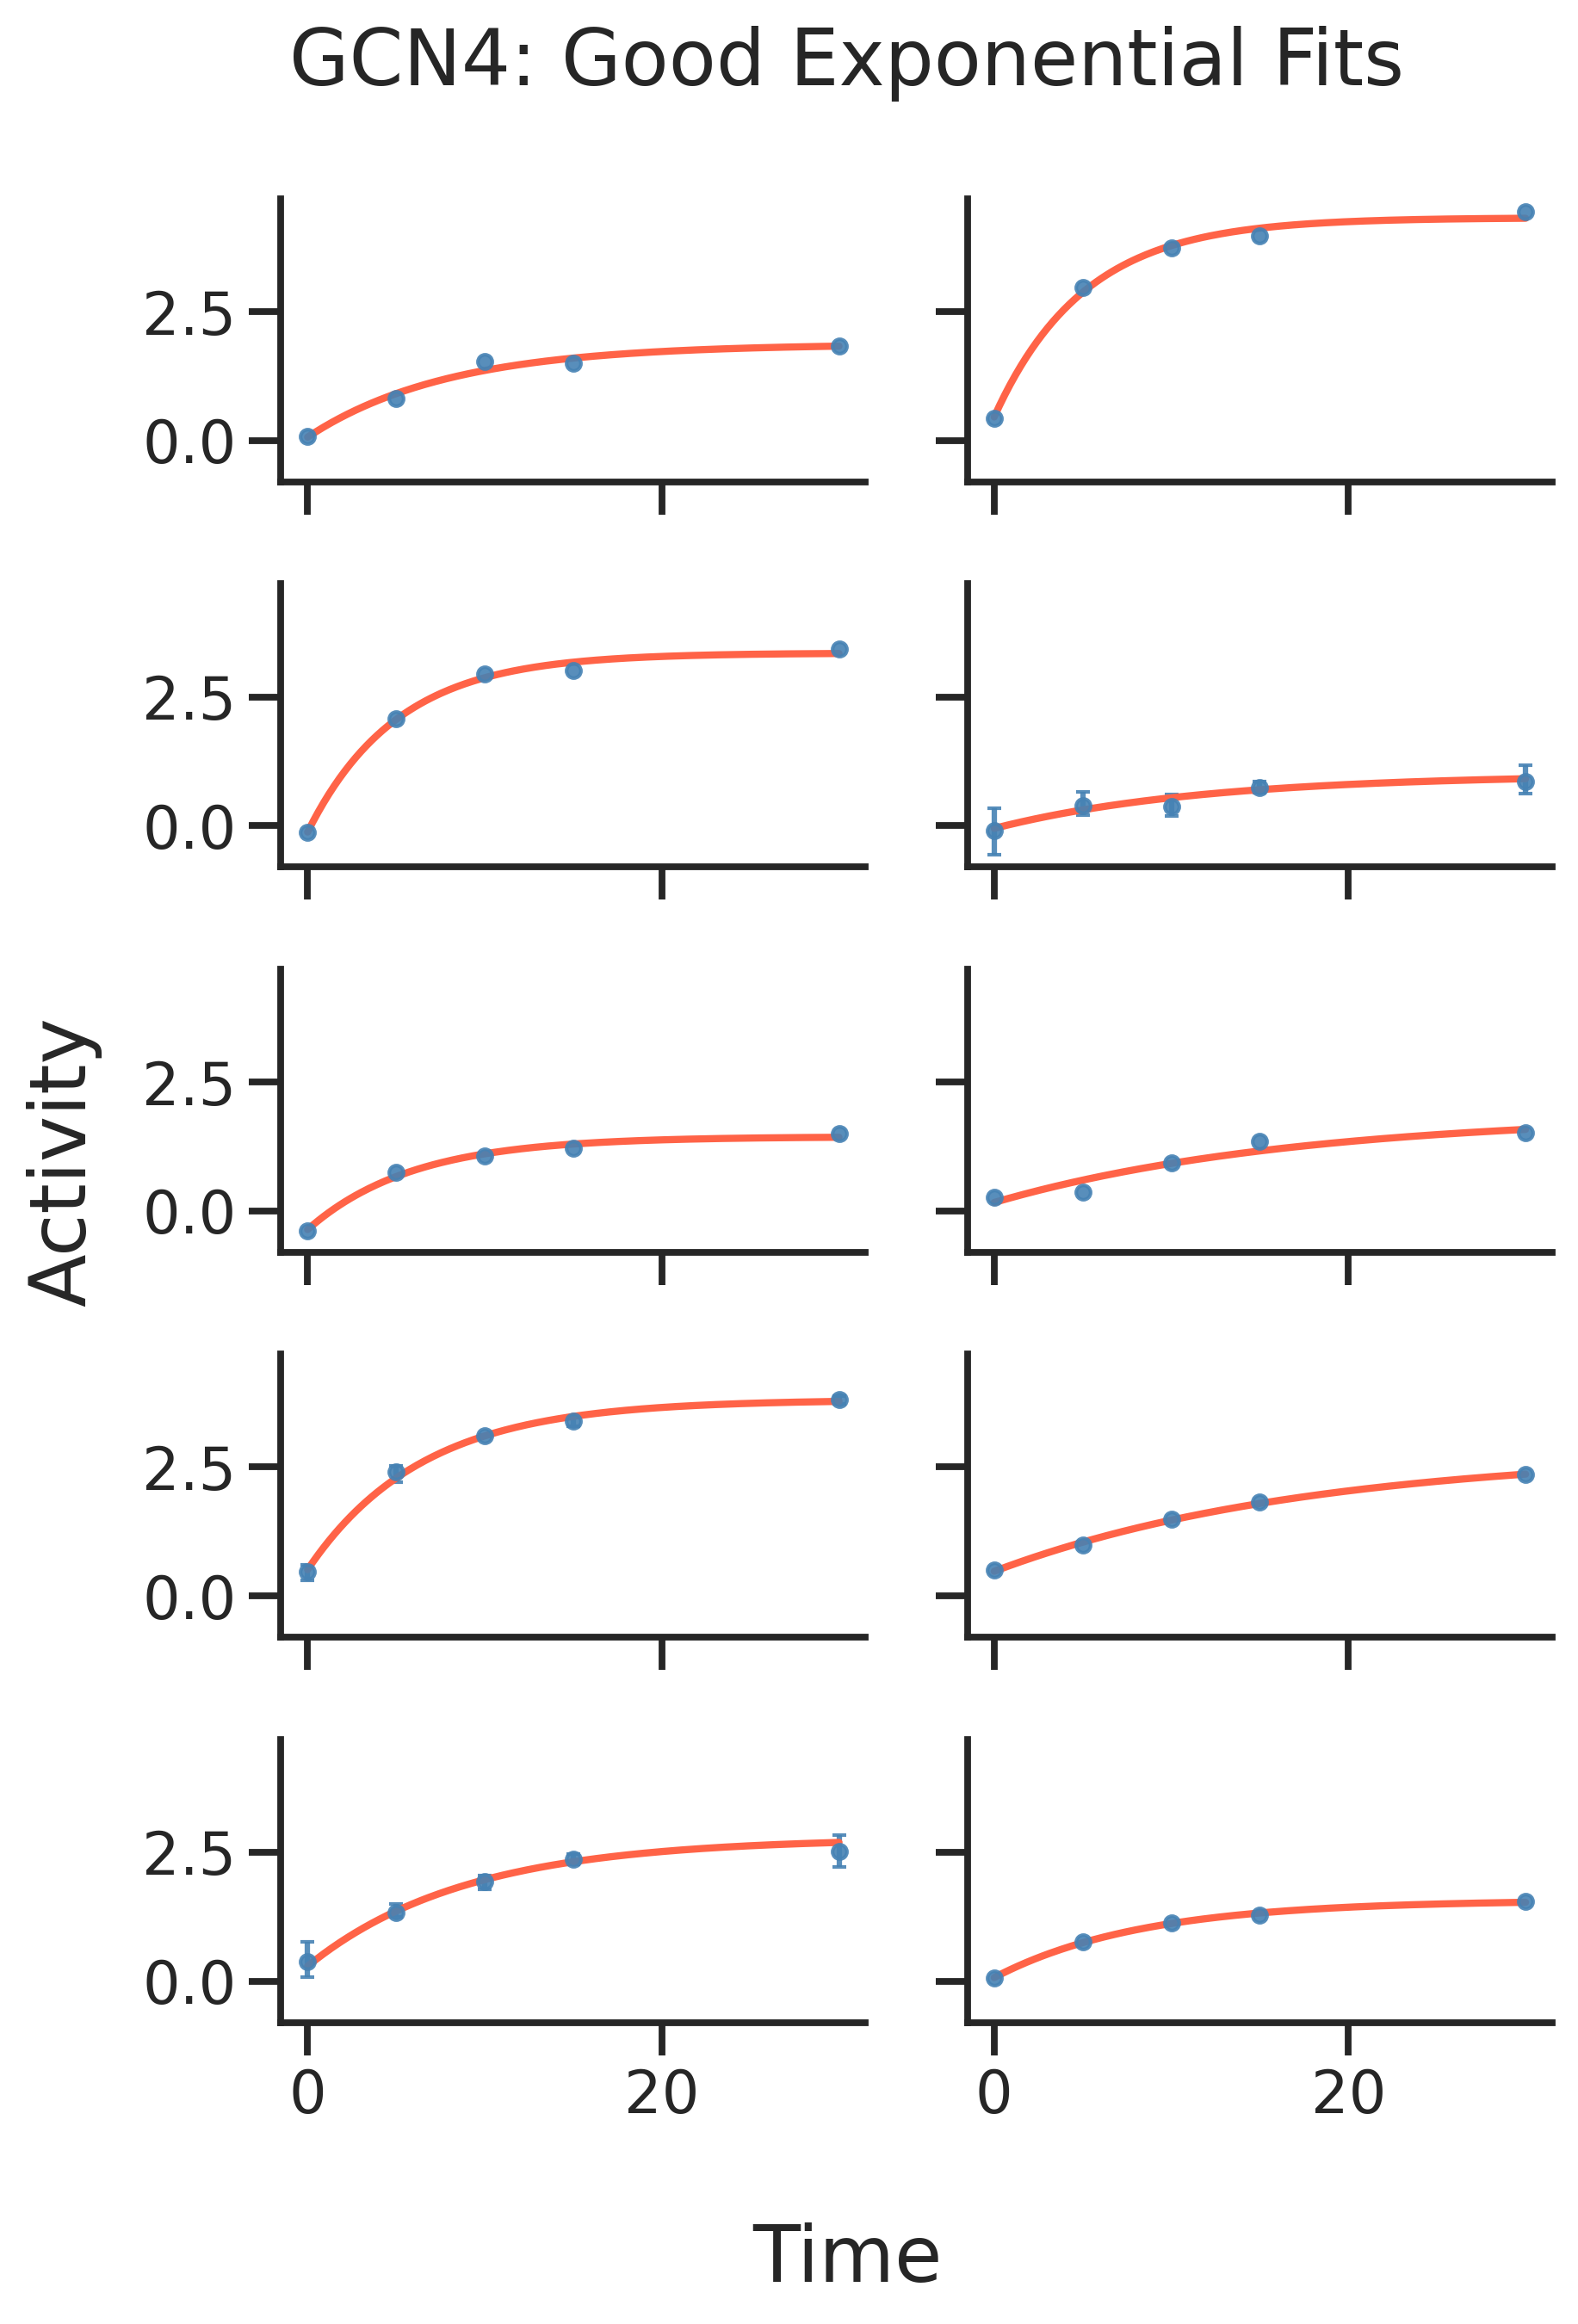

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ok.sample(16, random_state=42)["ADseq"].values

speed_plotting_helpers.plot_model_fits(
    activities=active_tile_activities_count_filtered,
    fit_results=fit_results,
    sample_adseqs=sample_adseqs,
    model_fn=rising_exponential,
    model_params=["A", "k", "C"],
    y_col="activity",
    title="GCN4: Good Exponential Fits",
)

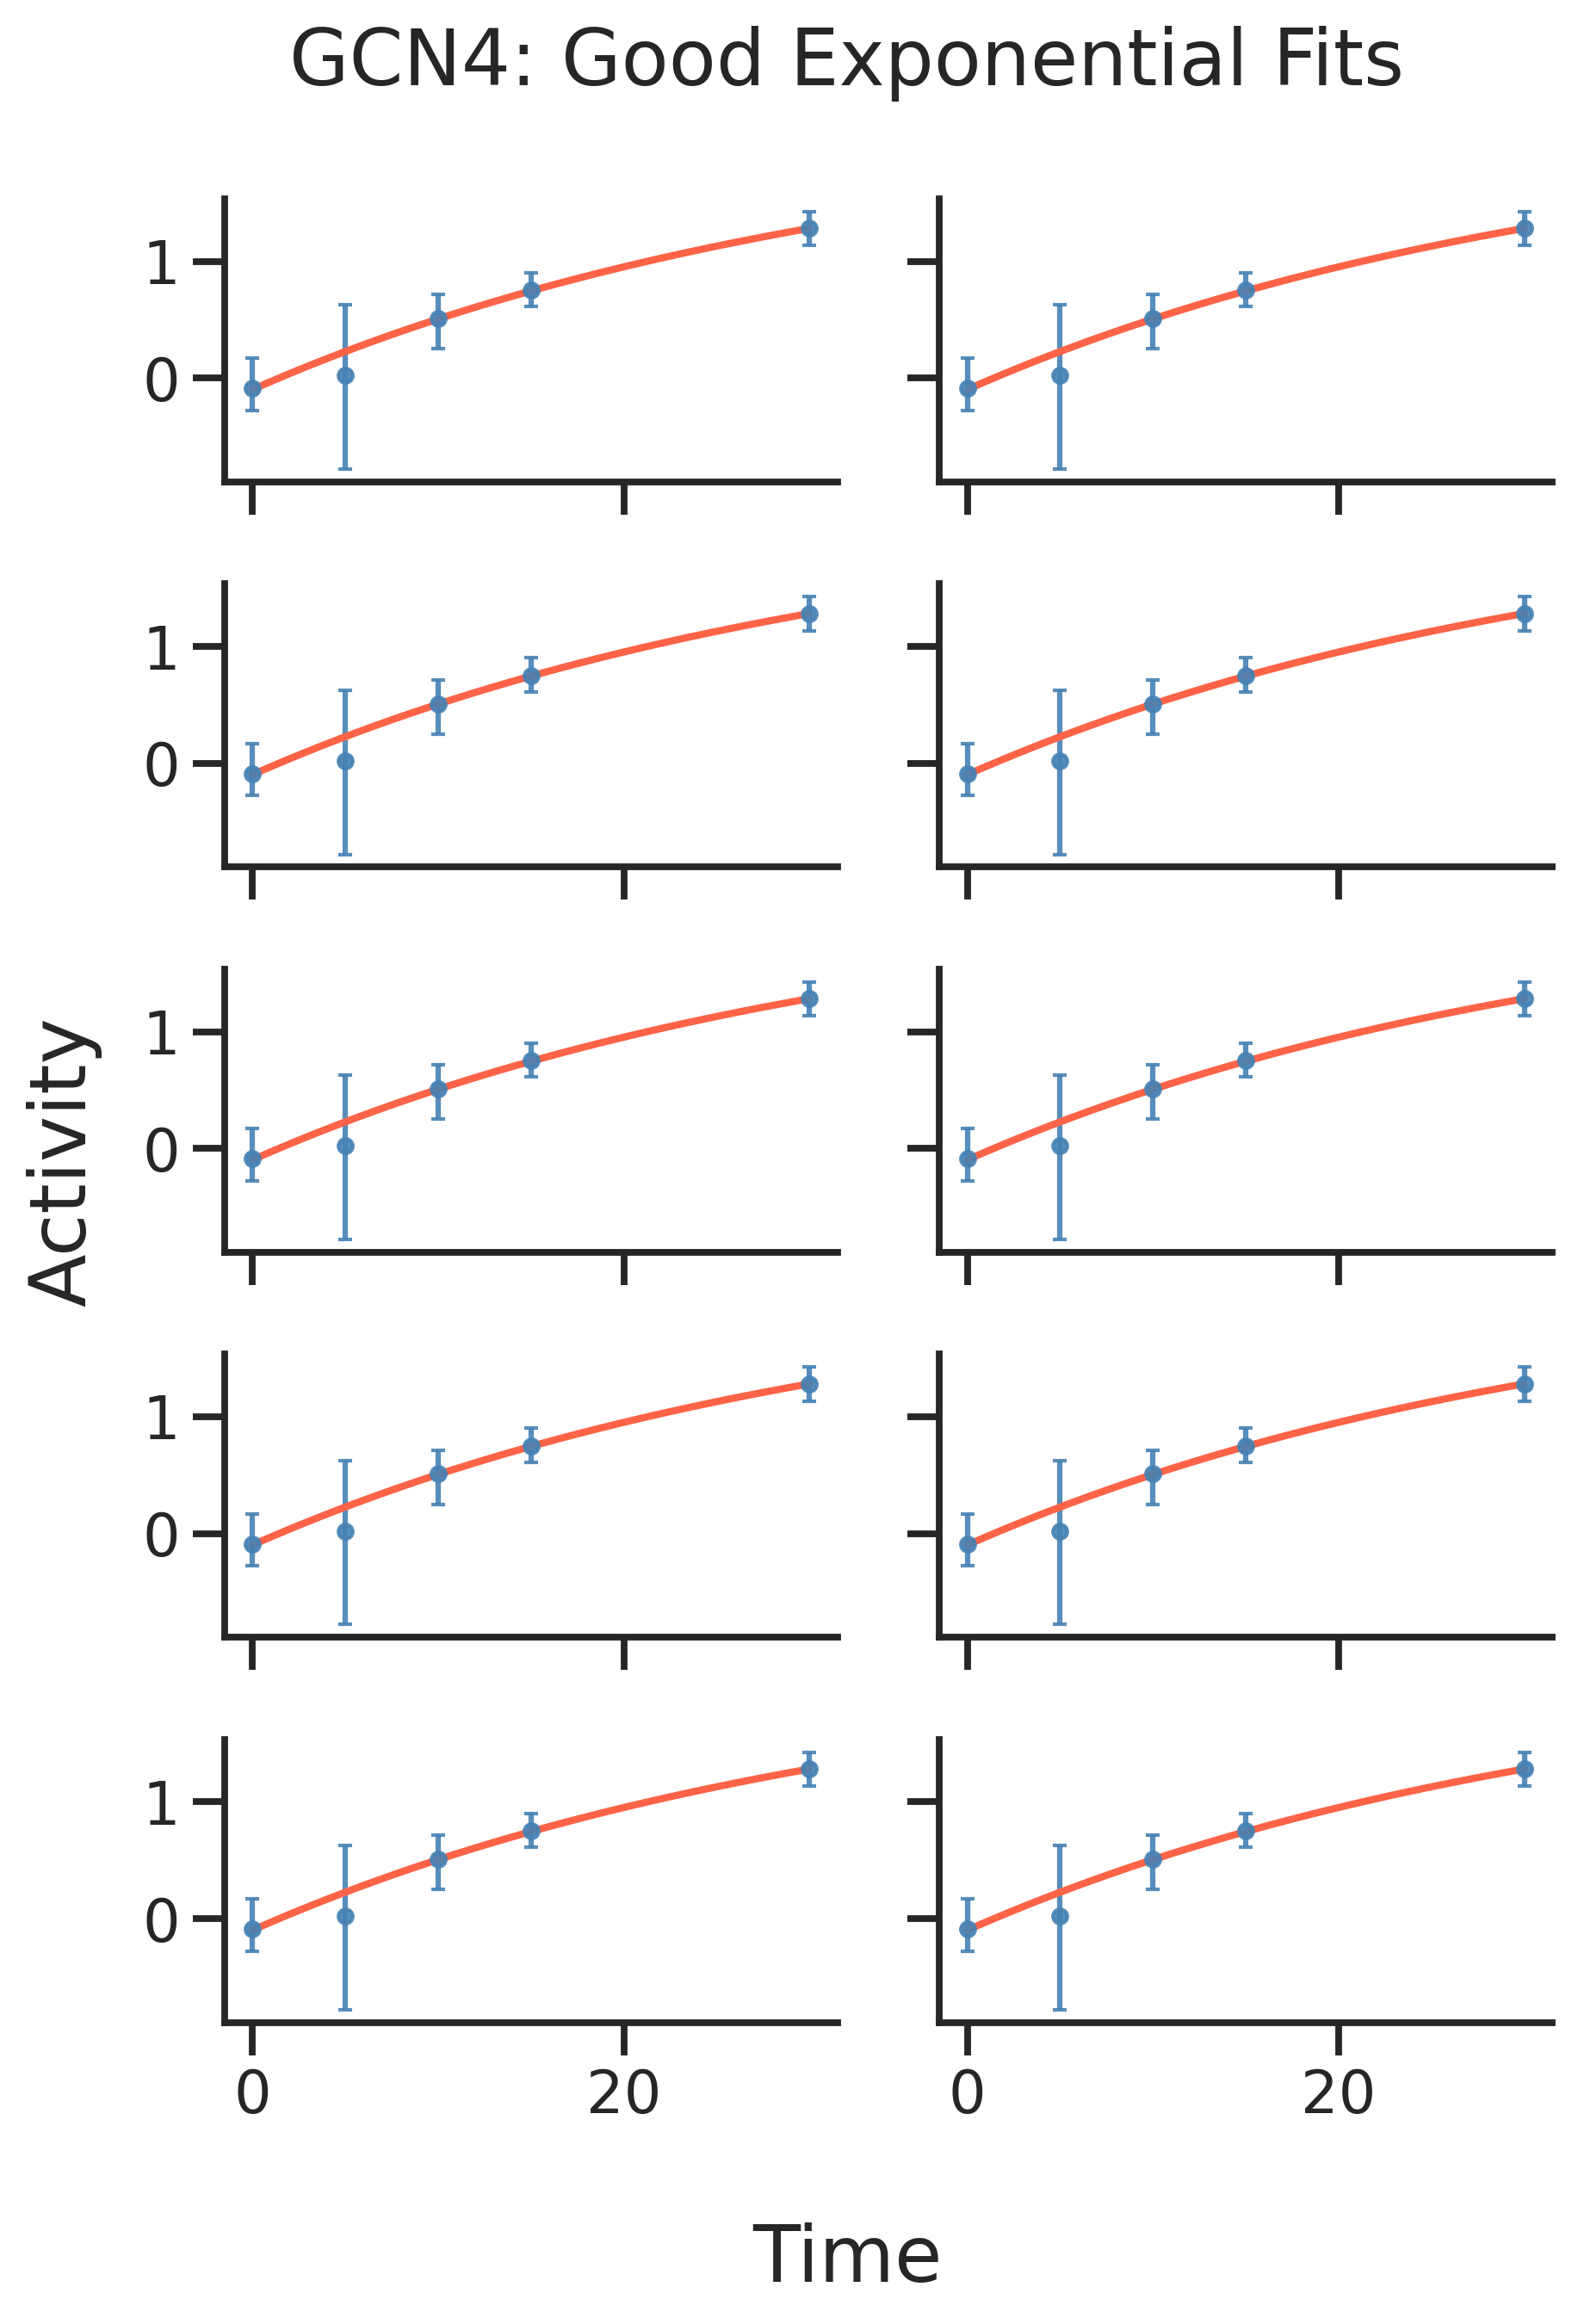

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ["DLGGDITAFVQPSSLYGDEDSCAMDRTFSSTSMASSTPSC"] * 16
#ok.sample(16, random_state=42)["ADseq"].values

speed_plotting_helpers.plot_model_fits(
    activities=active_tile_activities_count_filtered,
    fit_results=fit_results,
    sample_adseqs=sample_adseqs,
    model_fn=rising_exponential,
    model_params=["A", "k", "C"],
    y_col="activity",
    title="GCN4: Good Exponential Fits",
)

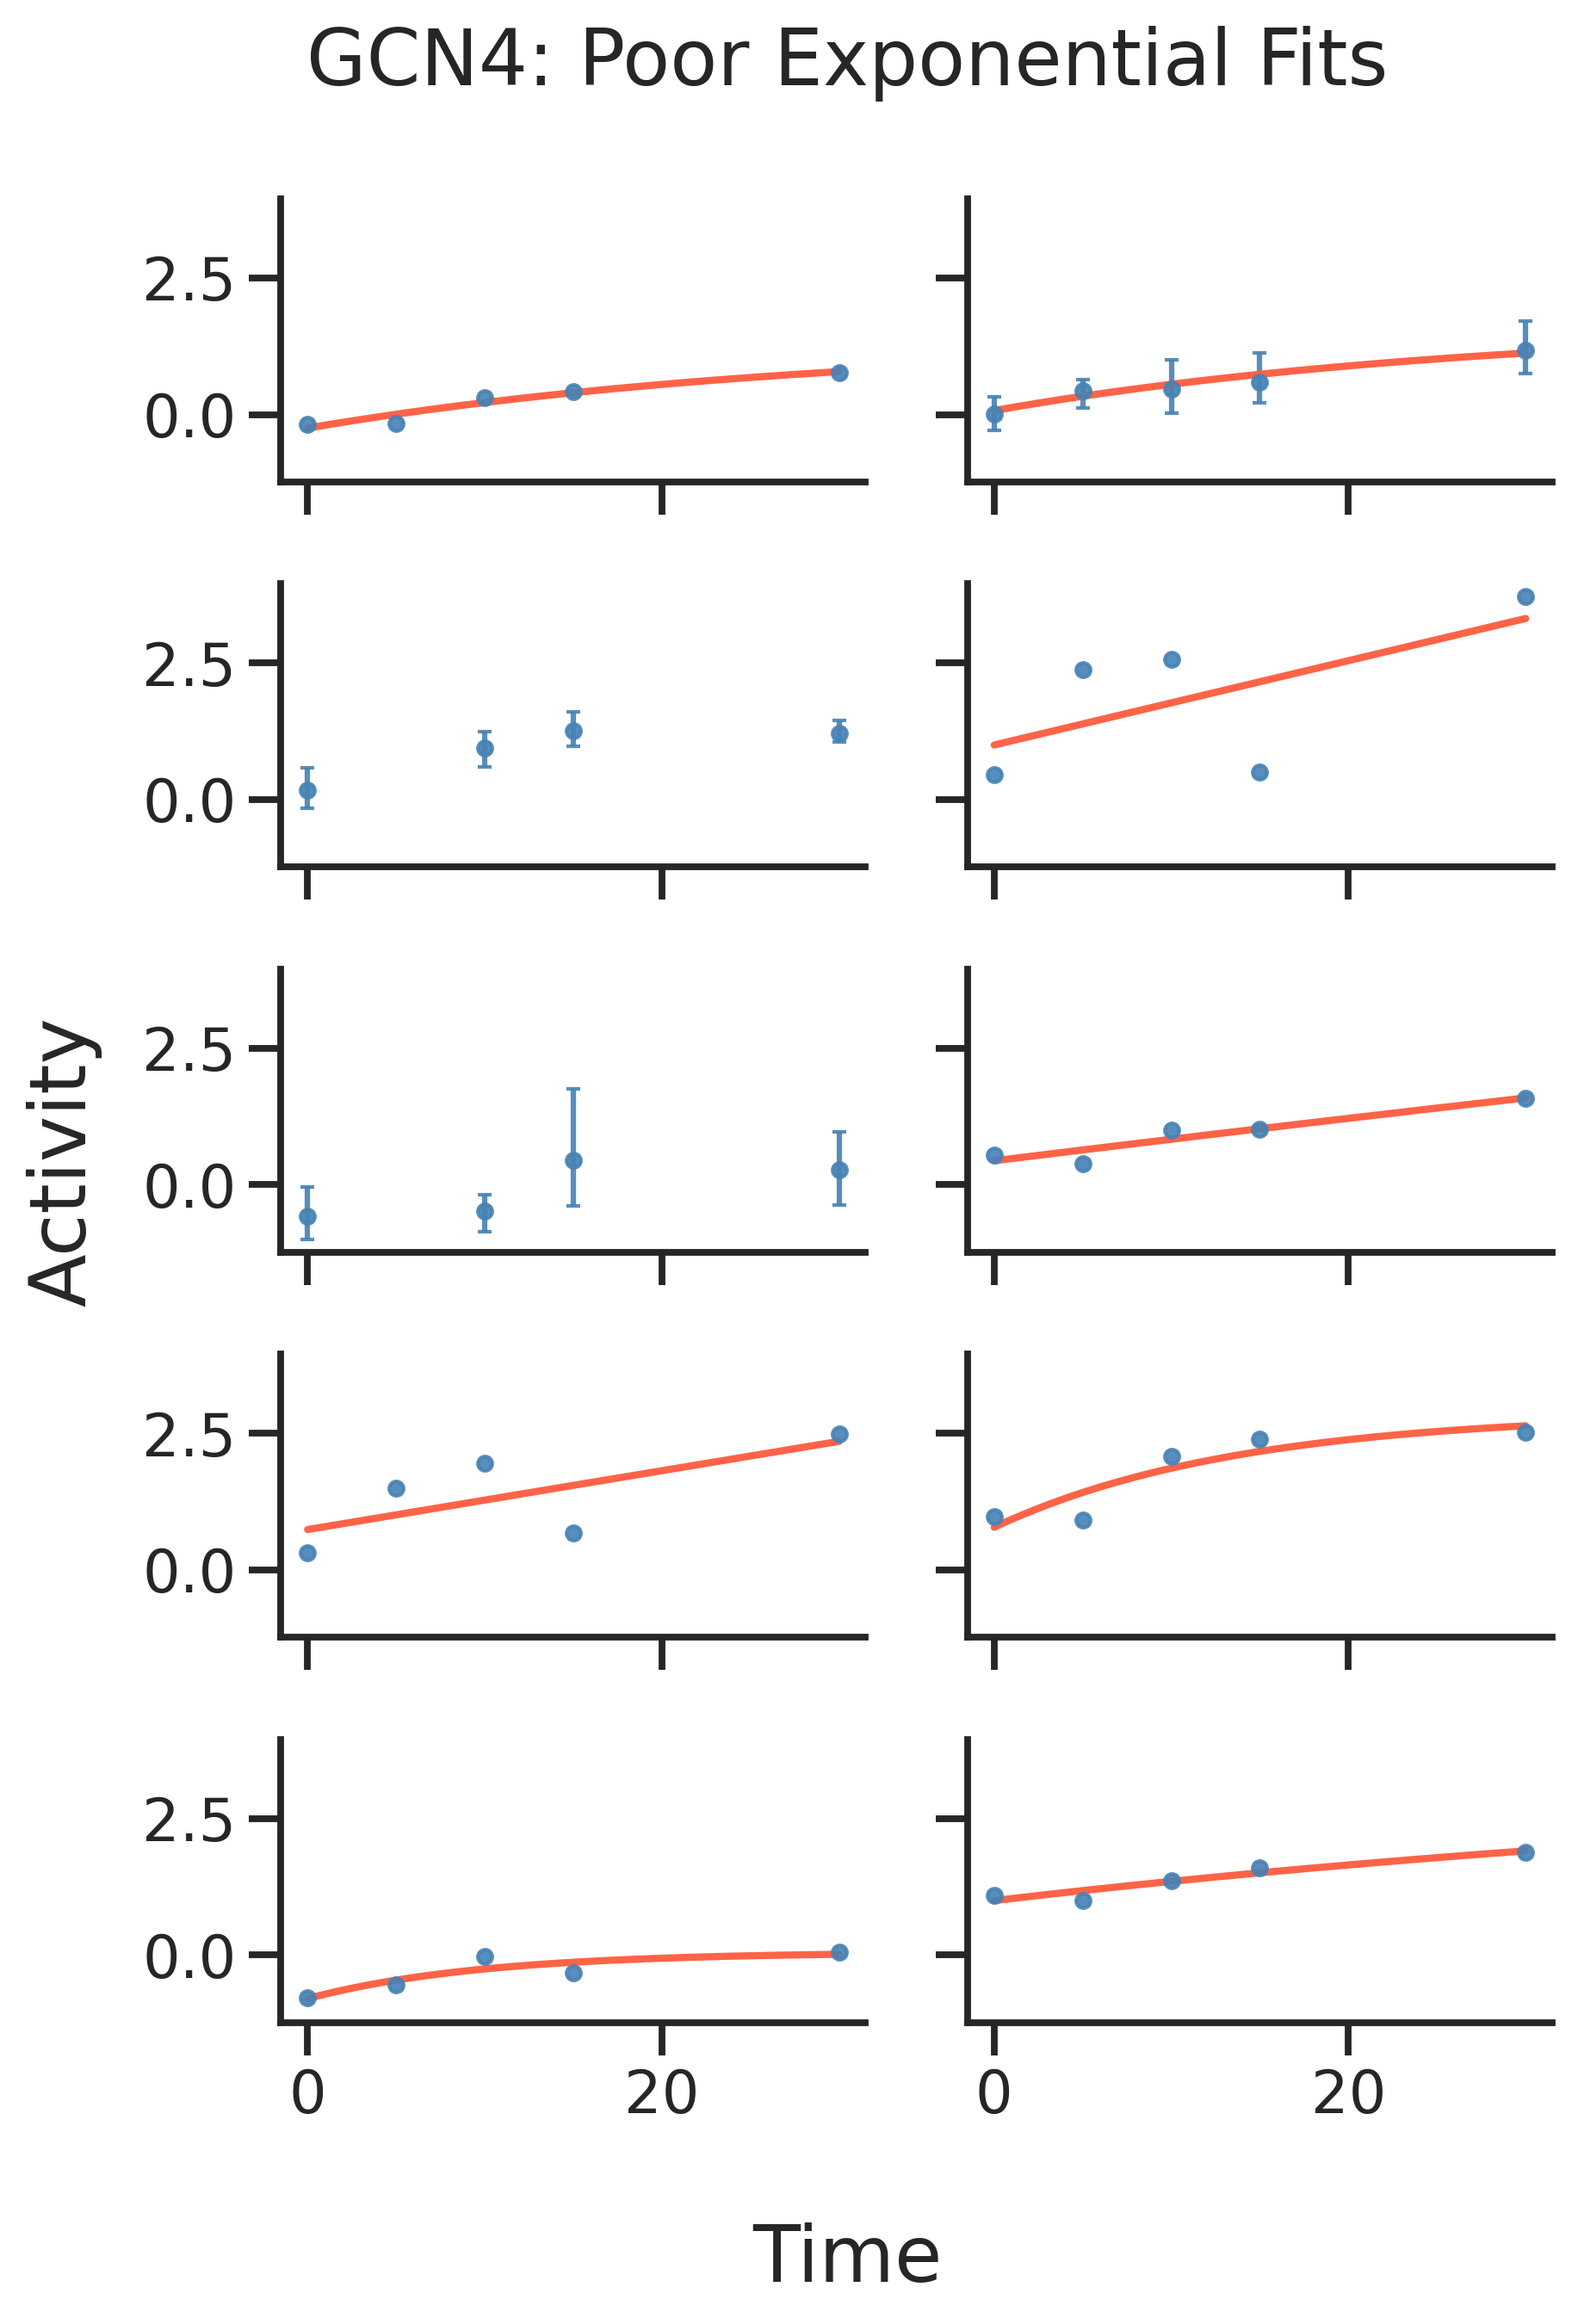

In [17]:
sample_adseqs = not_ok.sample(16, random_state=42)["ADseq"].values

speed_plotting_helpers.plot_model_fits(
    activities=active_tile_activities_count_filtered,
    fit_results=fit_results,
    sample_adseqs=sample_adseqs,
    model_fn=rising_exponential,
    model_params=["A", "k", "C"],
    y_col="activity",
    title="GCN4: Poor Exponential Fits",
)

In [18]:
import numpy as np
import pandas as pd

# --- filter the valid range first ---
filtered = ok[
    (ok['k'] >= 0) & (ok['k'] <= 0.2) &
    (ok['obs_max'] >= 0) & (ok['obs_max'] <= 5)
].copy()

# --- 1. Similar A, different k ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.2  # ±0.3 SD around median

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) & (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('k')

# Pick two sequences with widely separated k
seq_simA_diffk = similar_A_sorted.iloc[[0, -1]]  # first and last k

# --- 2. Similar k, different A ---
k_target = filtered['k'].median()
k_tol = filtered['k'].std() * 0.2  # ±0.3 SD around median

similar_k = filtered[(filtered['k'] >= k_target - k_tol) & (filtered['k'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

# Pick two sequences with widely separated A
seq_simk_diffA = similar_k_sorted.iloc[[0, -1]]  # lowest and highest A

# --- Combine for inspection ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA])
to_plot

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
307,ASSSHLGTVSPGELLLREQFSAPNSTAFTNLTTPSNFGES,3.021020,2.017390,0.019366,0.017524,1.044744,0.077102,35.791320,32.386189,2.375975,2.525050,0.986403,ok,NaN,4.065765,0.058506,51.635959
3121,QMTAGVMAGPDSLADLPSGTISPKDLFMDASAPPSASFTD,2.554218,0.076505,0.198594,0.015226,0.098086,0.060008,3.490276,0.267589,2.645701,3.306613,0.998339,ok,NaN,2.652305,0.507252,5.035404
4446,VFNSFVSNMNTDFISASNPATTATASDTVVTNPSIIPDSV,1.084658,0.252971,0.118635,0.066186,-0.938439,0.188315,5.842705,3.259633,0.115343,21.102204,0.992654,ok,NaN,0.146219,0.128678,8.429241
4331,TTEPDALFNWALDVACGADPIQQWTFITSTSAPPSPVPSL,3.948221,0.567667,0.131319,0.044644,0.954868,0.377842,5.278356,1.794446,4.826270,3.486974,0.986691,ok,NaN,4.903089,0.518475,7.615058


In [19]:
ok["A_prop"] = ok["A+C"] / ok["obs_max"]
ok.sort_values(by = "A_prop")

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k,A_prop
4036,TAGDPWFPLFPQESTTATKDVTSIEEIQKLQTDQSPALNG,2.185279,0.337580,0.583590,0.578067,-1.492242,0.289627,1.187729,1.176488,0.693037,3.126253,0.956871,ok,NaN,0.693037,1.275308,1.713531,1.000000
2673,PCSYPSTDVDLDDFTVFEGGASTAFSSPAVASSFDFSSGA,2.572422,0.039715,0.438980,0.028211,2.432783,0.033703,1.578996,0.101473,5.005199,0.060120,0.999548,ok,NaN,5.005204,1.129241,2.278009,1.000001
3564,SLPAQSPQHKSHQDFSLPDPQPQPHQDFVLFERSPSVRST,0.948860,0.021506,0.439665,0.041556,-0.428759,0.018252,1.576533,0.149011,0.520099,2.945892,0.999026,ok,NaN,0.520101,0.417181,2.274457,1.000003
2404,NDELARVAGDLLDKVKDDQSDKFQQSNFLALMRRFRDHEV,1.721680,0.266300,0.380051,0.210609,3.036032,0.224187,1.823828,1.010695,4.757693,0.000000,0.956541,ok,NaN,4.757712,0.654326,2.631227,1.000004
976,FAPPQSDFVLYDQPAQVSQRPLRAPSVPQPGHTFNNGQHF,1.331876,0.006664,0.452034,0.009756,-0.910342,0.005664,1.533395,0.033093,0.421533,4.088176,0.999953,ok,NaN,0.421534,0.602054,2.212222,1.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,FTPAQSPHQFYASSAPSSTTALQQQRPTRPQVPLFSQSTG,1.207370,0.597196,0.036755,0.031644,-0.315189,0.084295,18.858611,16.236270,0.491346,17.014028,0.958041,ok,NaN,0.892181,0.044377,27.207224,1.815791
804,EFHASPIRVSPLYALATWEPPVPGPLNFSIASRSSSSSPN,1.525713,0.404639,0.058782,0.033760,-0.961363,0.135222,11.791735,6.772240,0.302769,22.244489,0.957767,ok,NaN,0.564349,0.089685,17.011878,1.863963
634,DPKSWGSLFDNDIPVTVNDASLATSAIEVPTEDSTAPSPV,1.448160,0.190952,0.143299,0.045844,-1.406350,0.138540,4.837067,1.547456,0.022140,26.873747,0.970376,ok,NaN,0.041809,0.207520,6.978412,1.888431
293,ASPQTDFVLYDQPAPPRRAPSAPQPAPTFNNGQHFYANSA,3.198762,0.746596,0.019755,0.006285,0.513232,0.029721,35.087669,11.163676,1.943511,7.815631,0.998230,ok,NaN,3.711994,0.063191,50.620805,1.909942


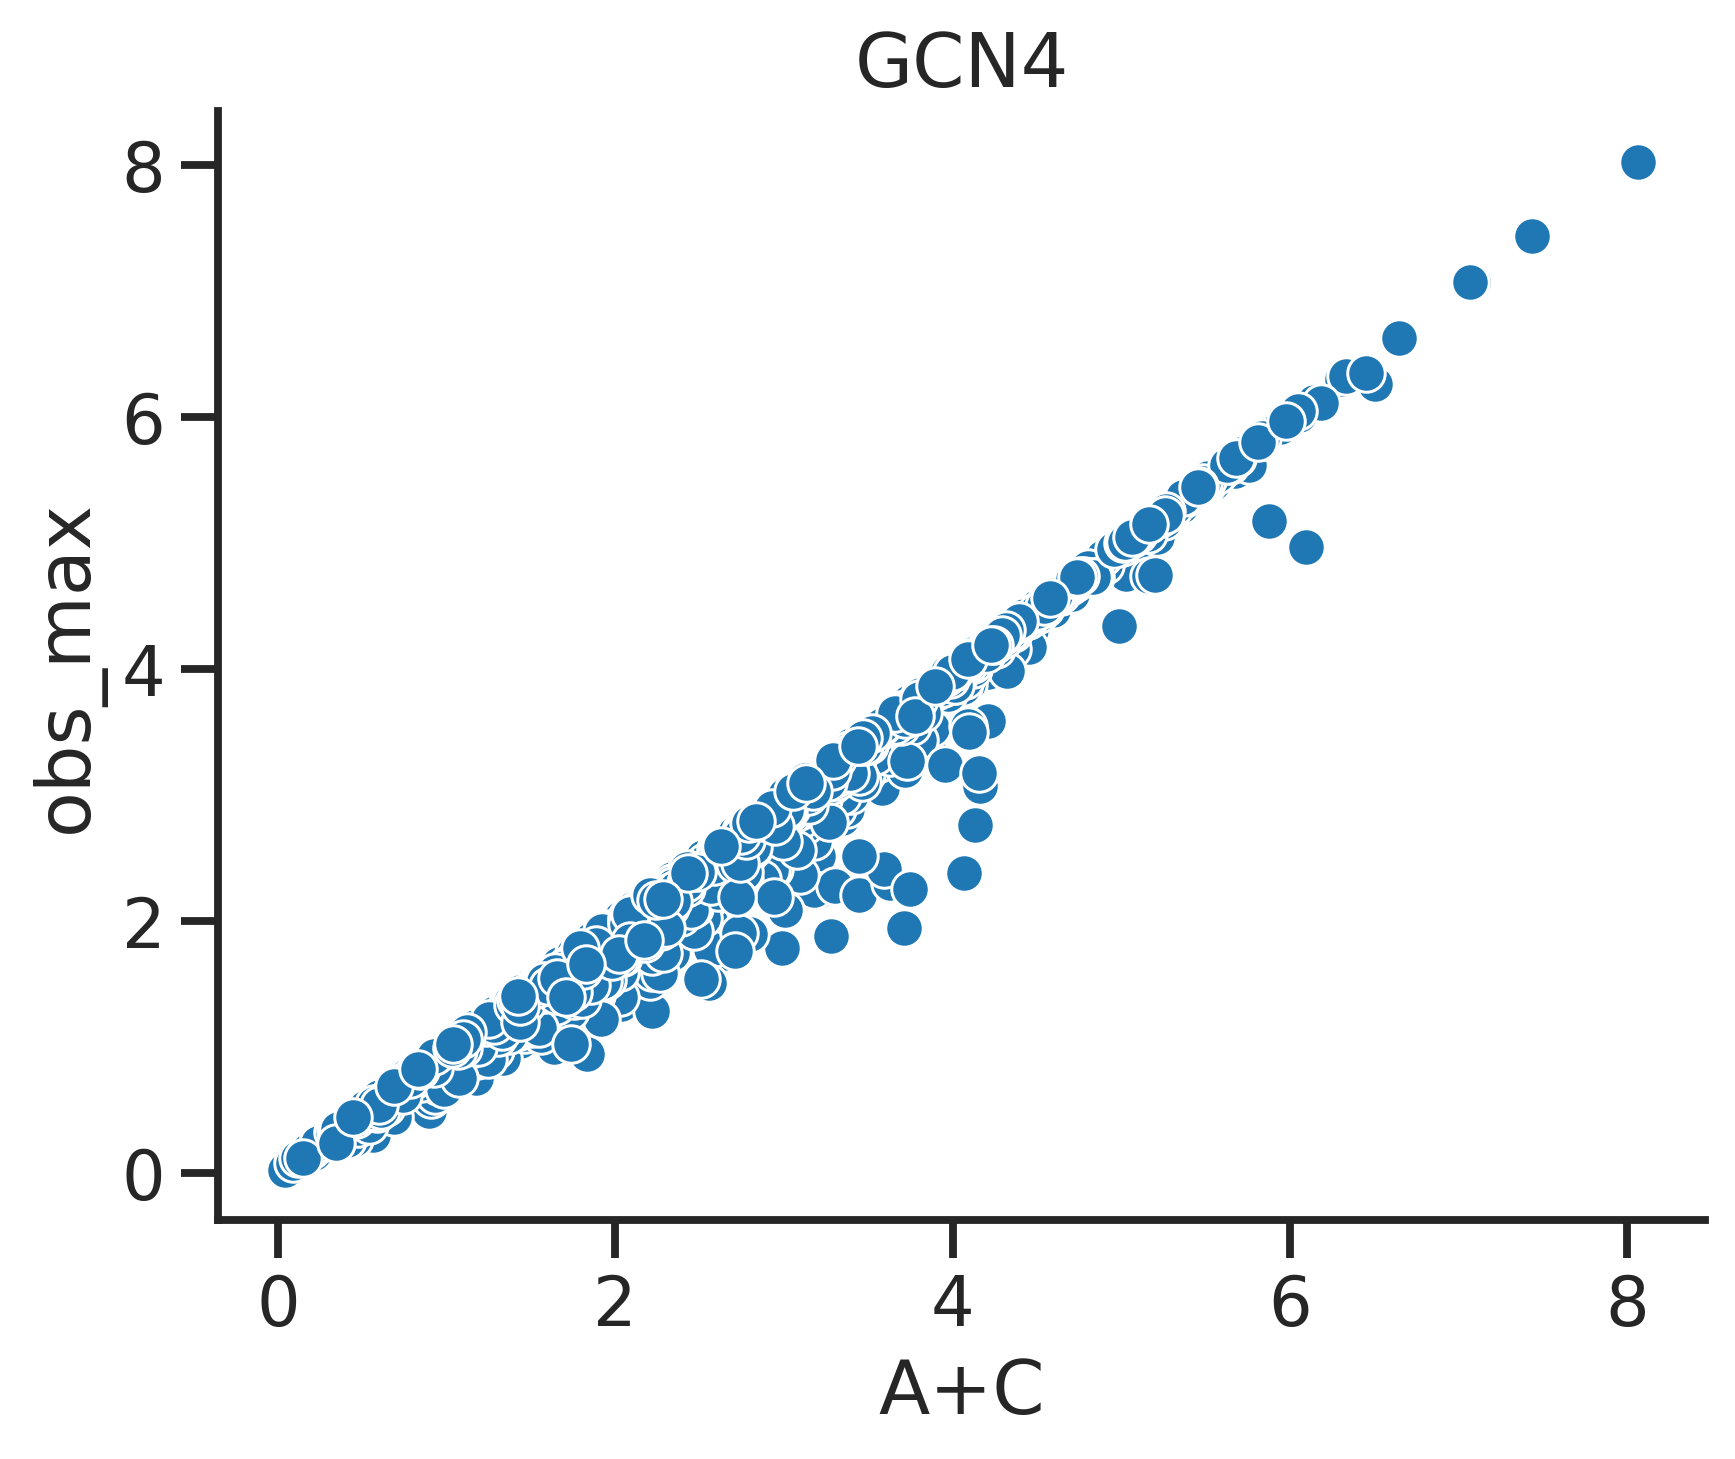

In [20]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "A+C", y = "obs_max")
plt.title("GCN4")
sns.despine()

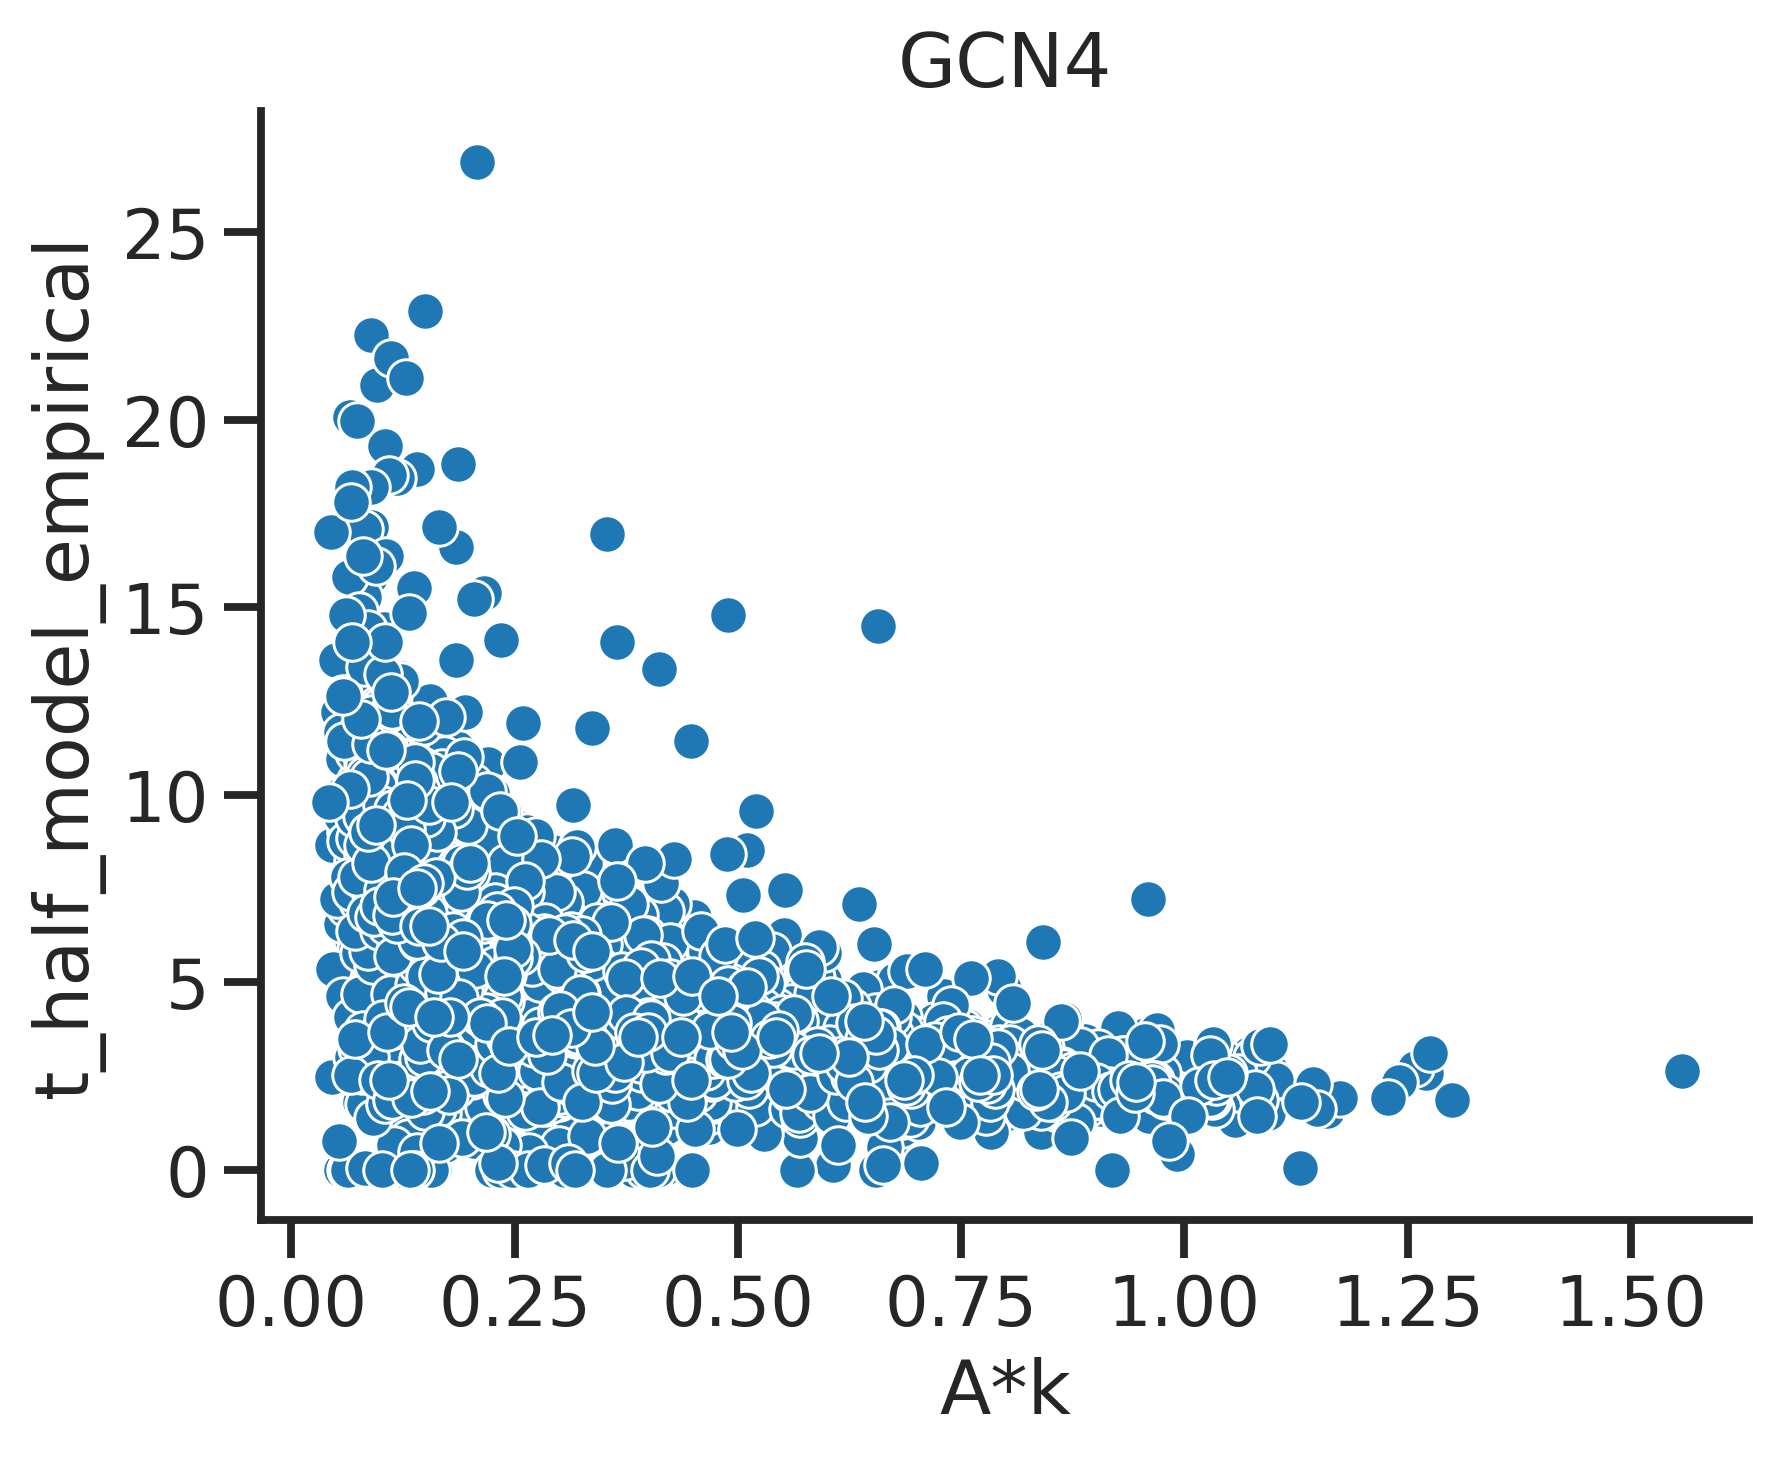

In [21]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "A*k", y = "t_half_model_empirical")
plt.title("GCN4")
sns.despine()

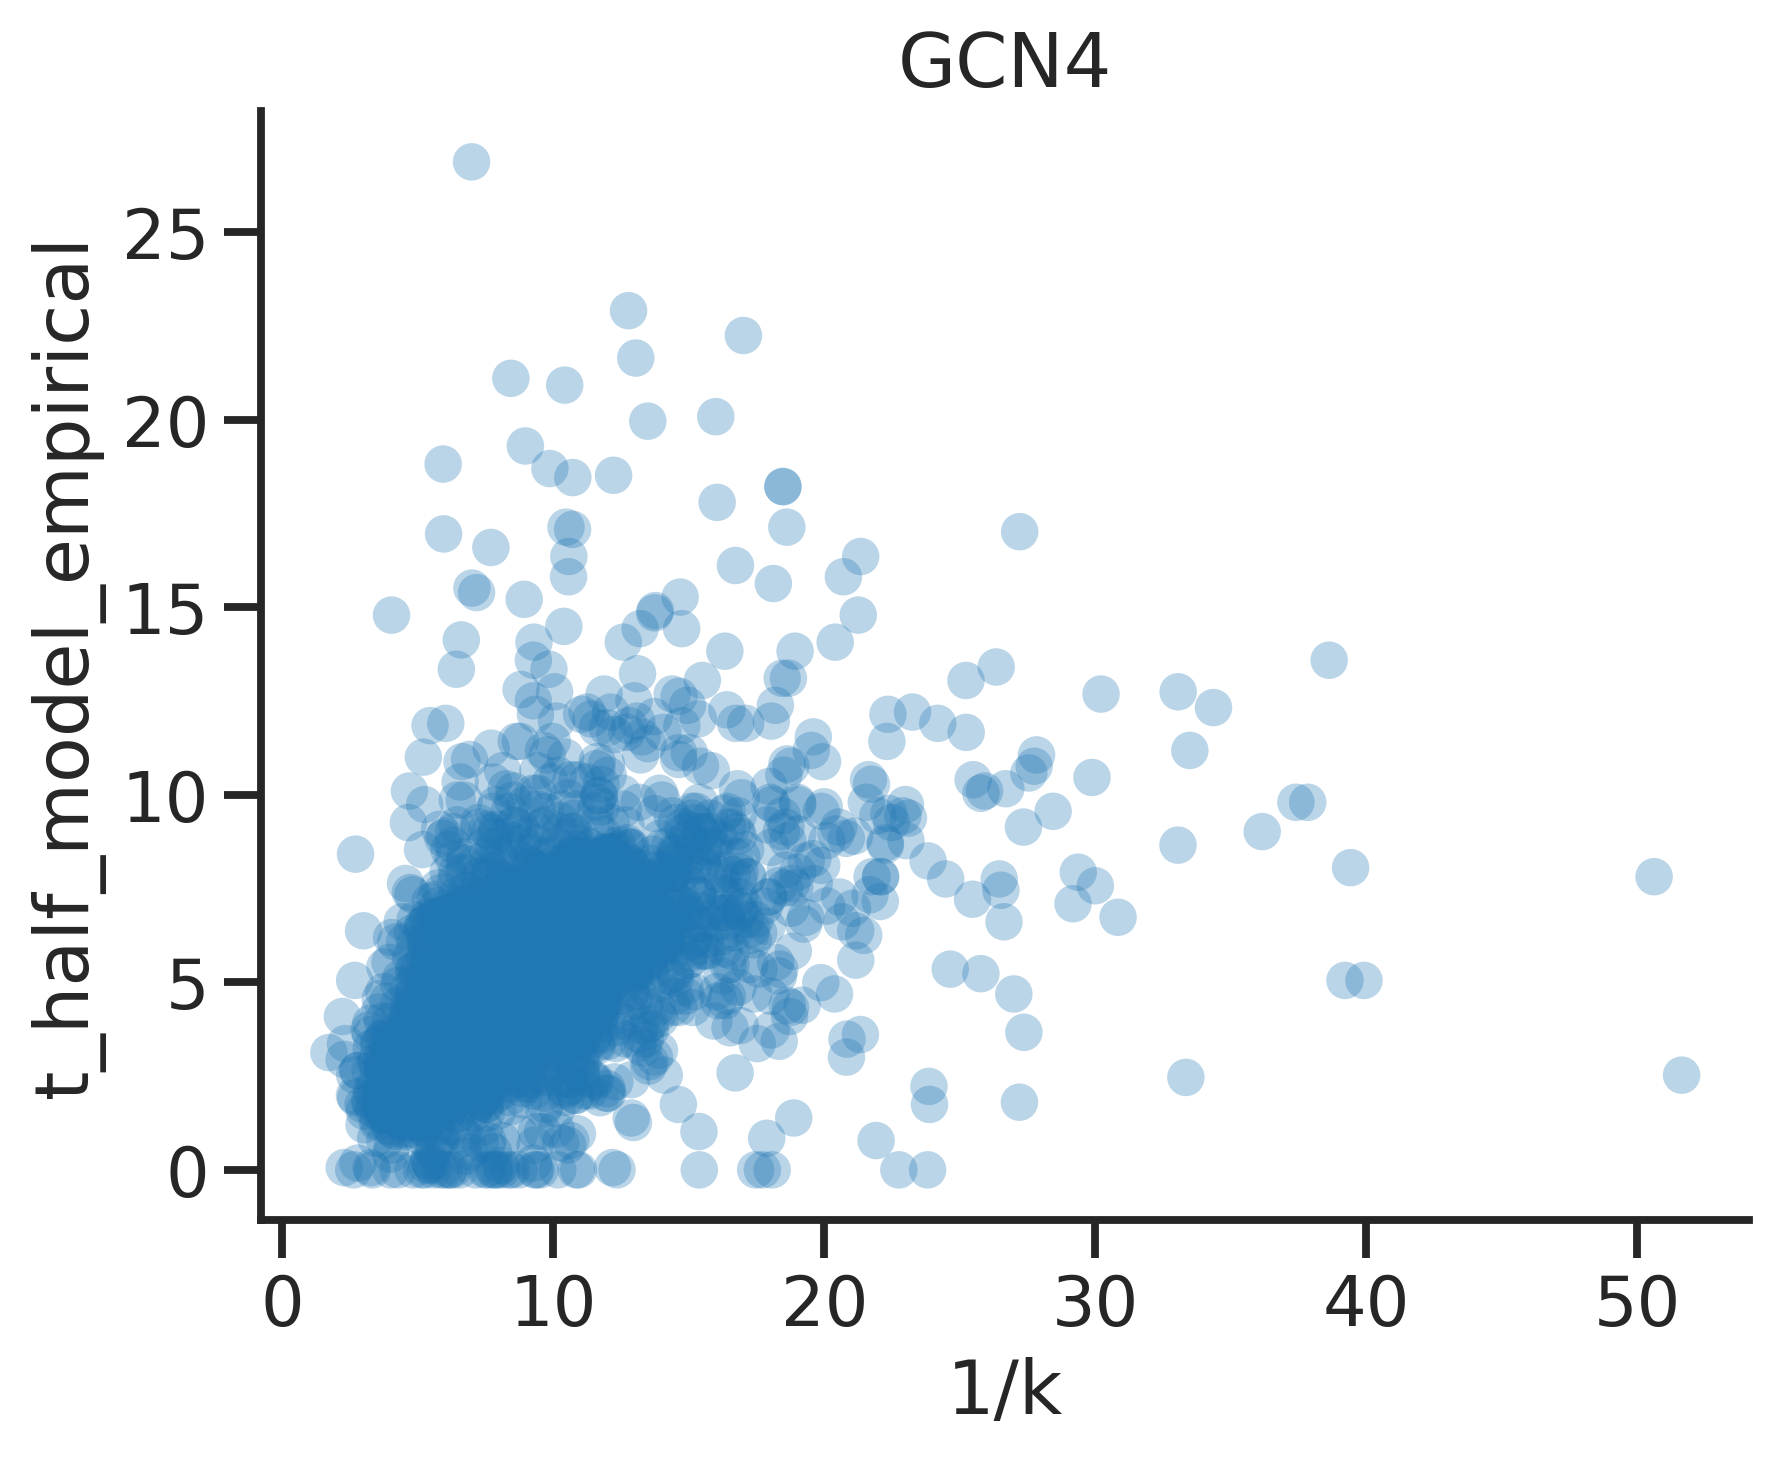

In [22]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "1/k", y = "t_half_model_empirical", edgecolor = 'none', alpha = 0.3)
plt.title("GCN4")
sns.despine()

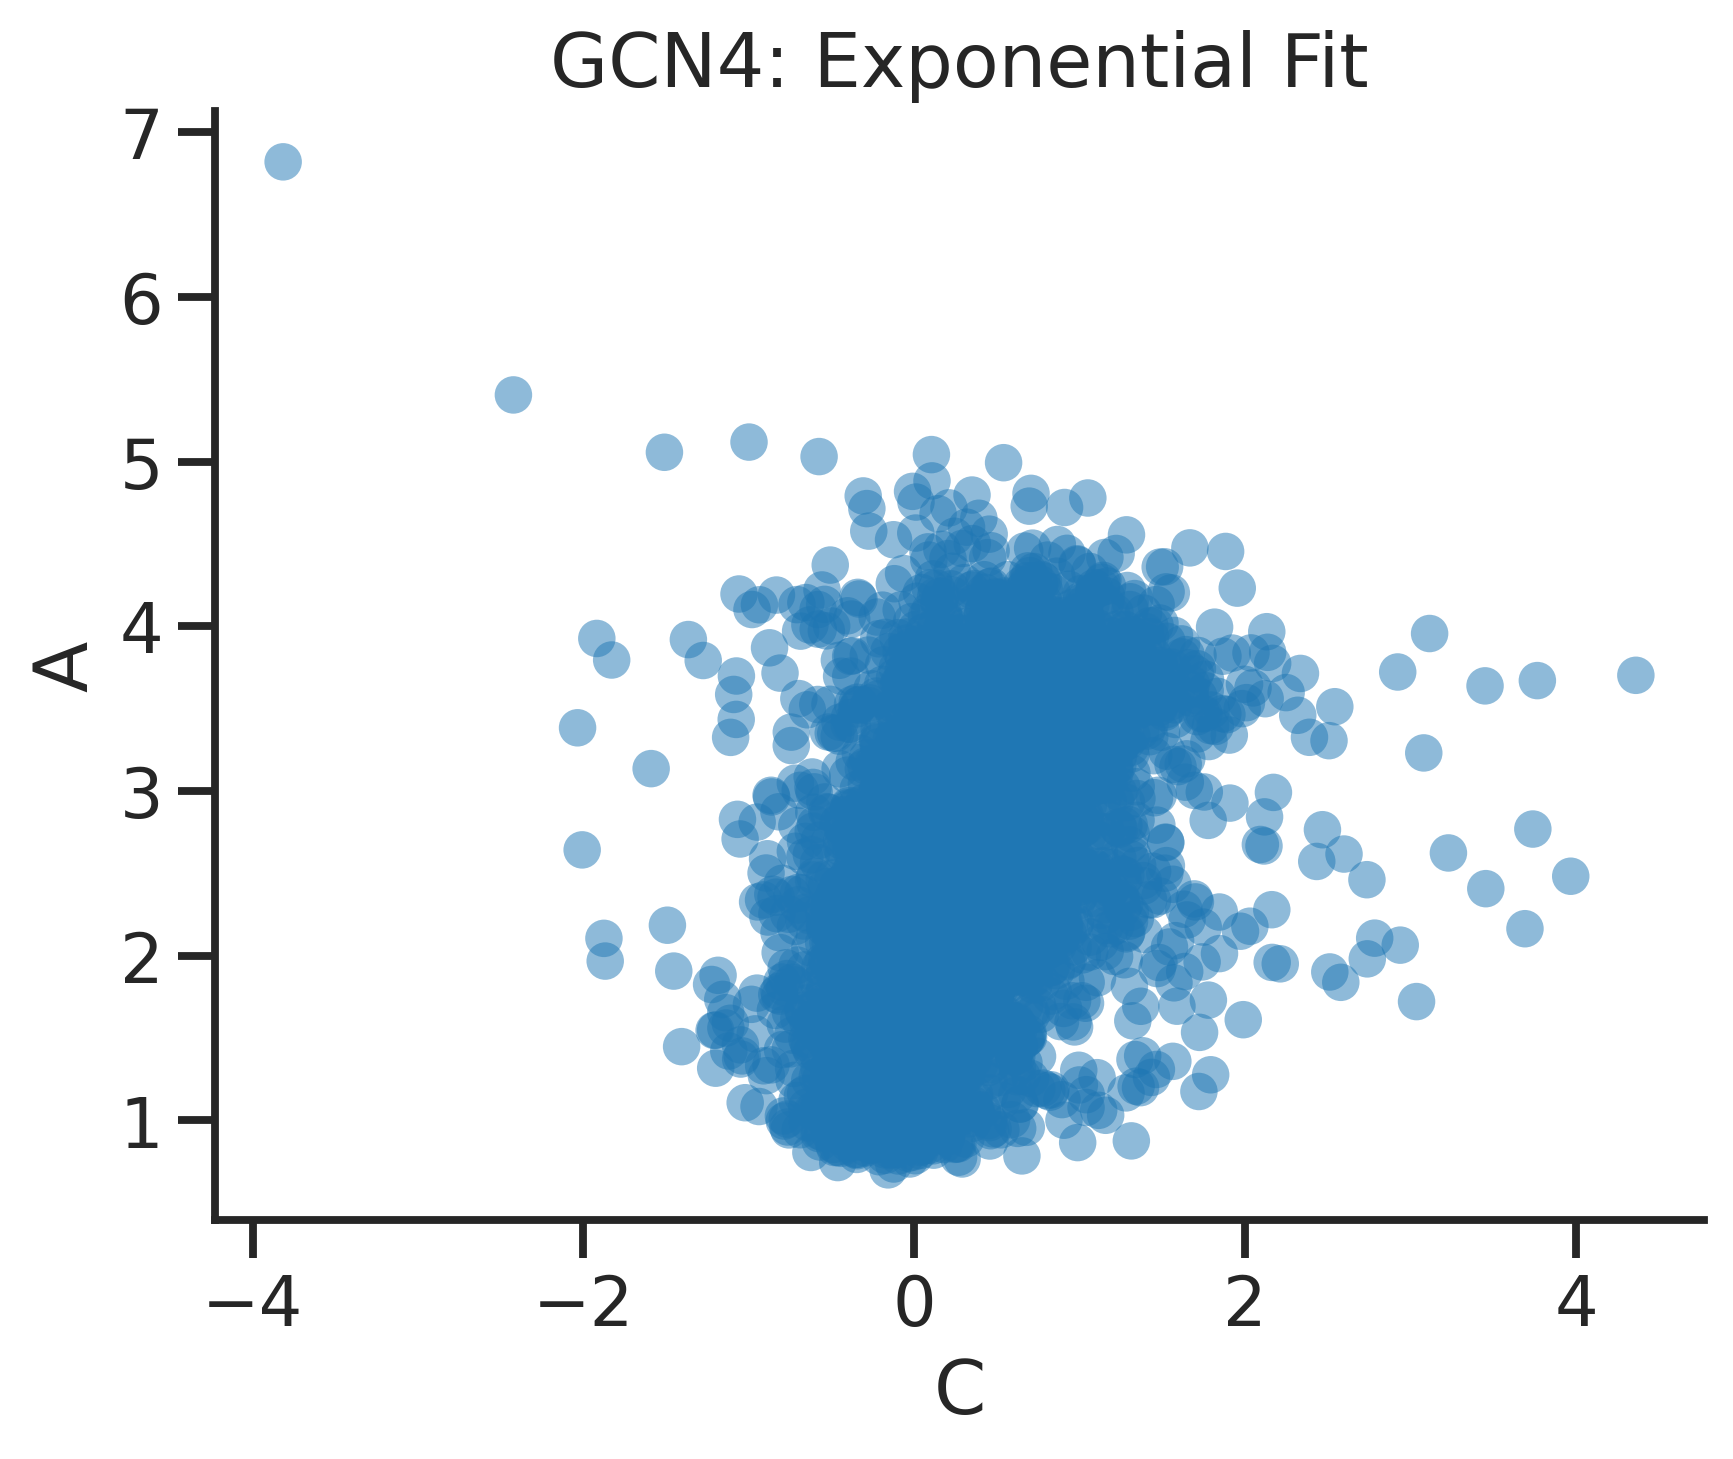

In [23]:
# The rise from baseline does not correlate with the starting activity
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "C", y = "A", edgecolor = 'none', alpha = 0.5)
plt.title("GCN4: Exponential Fit")
sns.despine()

Pearson r = 0.428, p = 1.27e-182
Spearman rho = 0.486, p = 1.52e-242


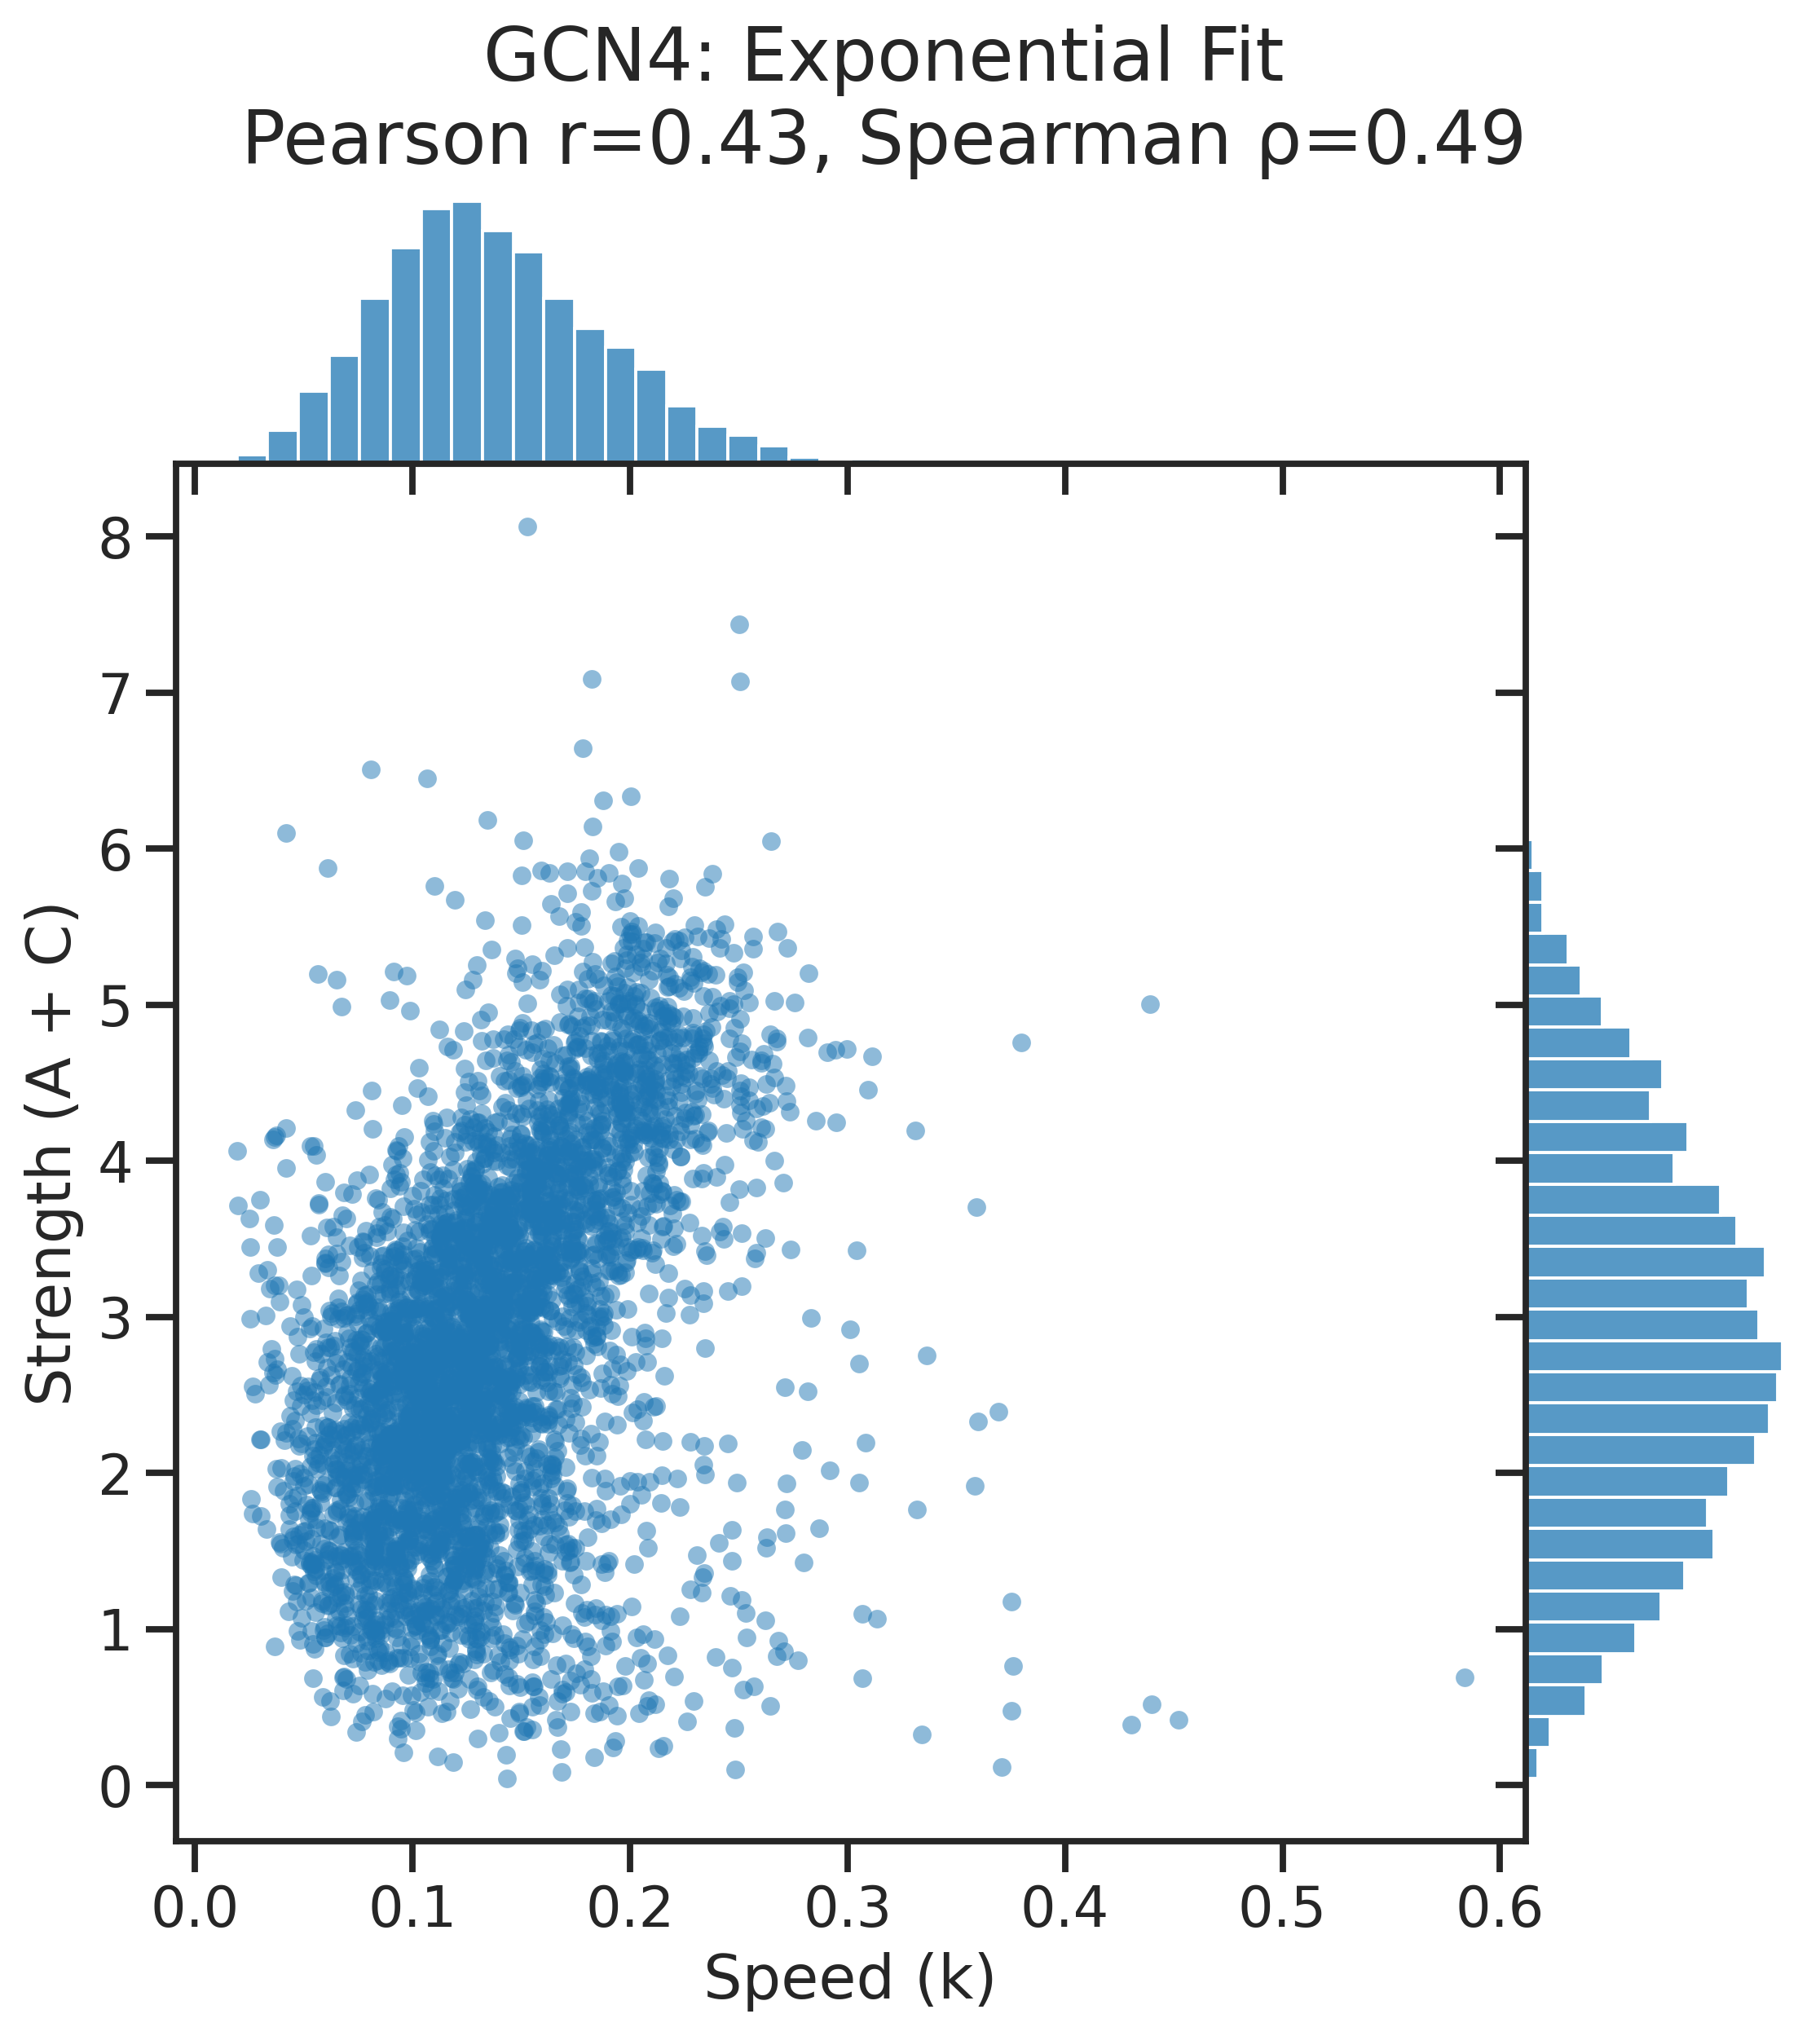

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok['A+C'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- joint scatter + marginal histograms ---
g = sns.JointGrid(
    data=ok,
    x='k',
    y='A+C',
    height=8,
    ratio=5,
    space=0
)

# scatter
g.plot_joint(
    plt.scatter,
    alpha=0.5,
    s=30,
    linewidths=0
)

# marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=40,
    kde=False
)

g.fig.set_dpi(300)

# labels + title
g.ax_joint.set_xlabel('Speed (k)')
g.ax_joint.set_ylabel('Strength (A + C)')

g.fig.suptitle(
    f'GCN4: Exponential Fit\n'
    f'Pearson r={pearson_corr:.2f}, '
    f'Spearman ρ={spearman_corr:.2f}',
    y=1.05
)

# optional limits
# g.ax_joint.set_xlim(-0.01, 0.2)
# g.ax_joint.set_ylim(0.5, 2.7)

sns.despine()
sns.despine(ax=g.ax_marg_x, left=True)
sns.despine(ax=g.ax_marg_y, bottom=True)

plt.show()

Pearson r = 0.428, p = 1.27e-182
Spearman rho = 0.486, p = 1.52e-242


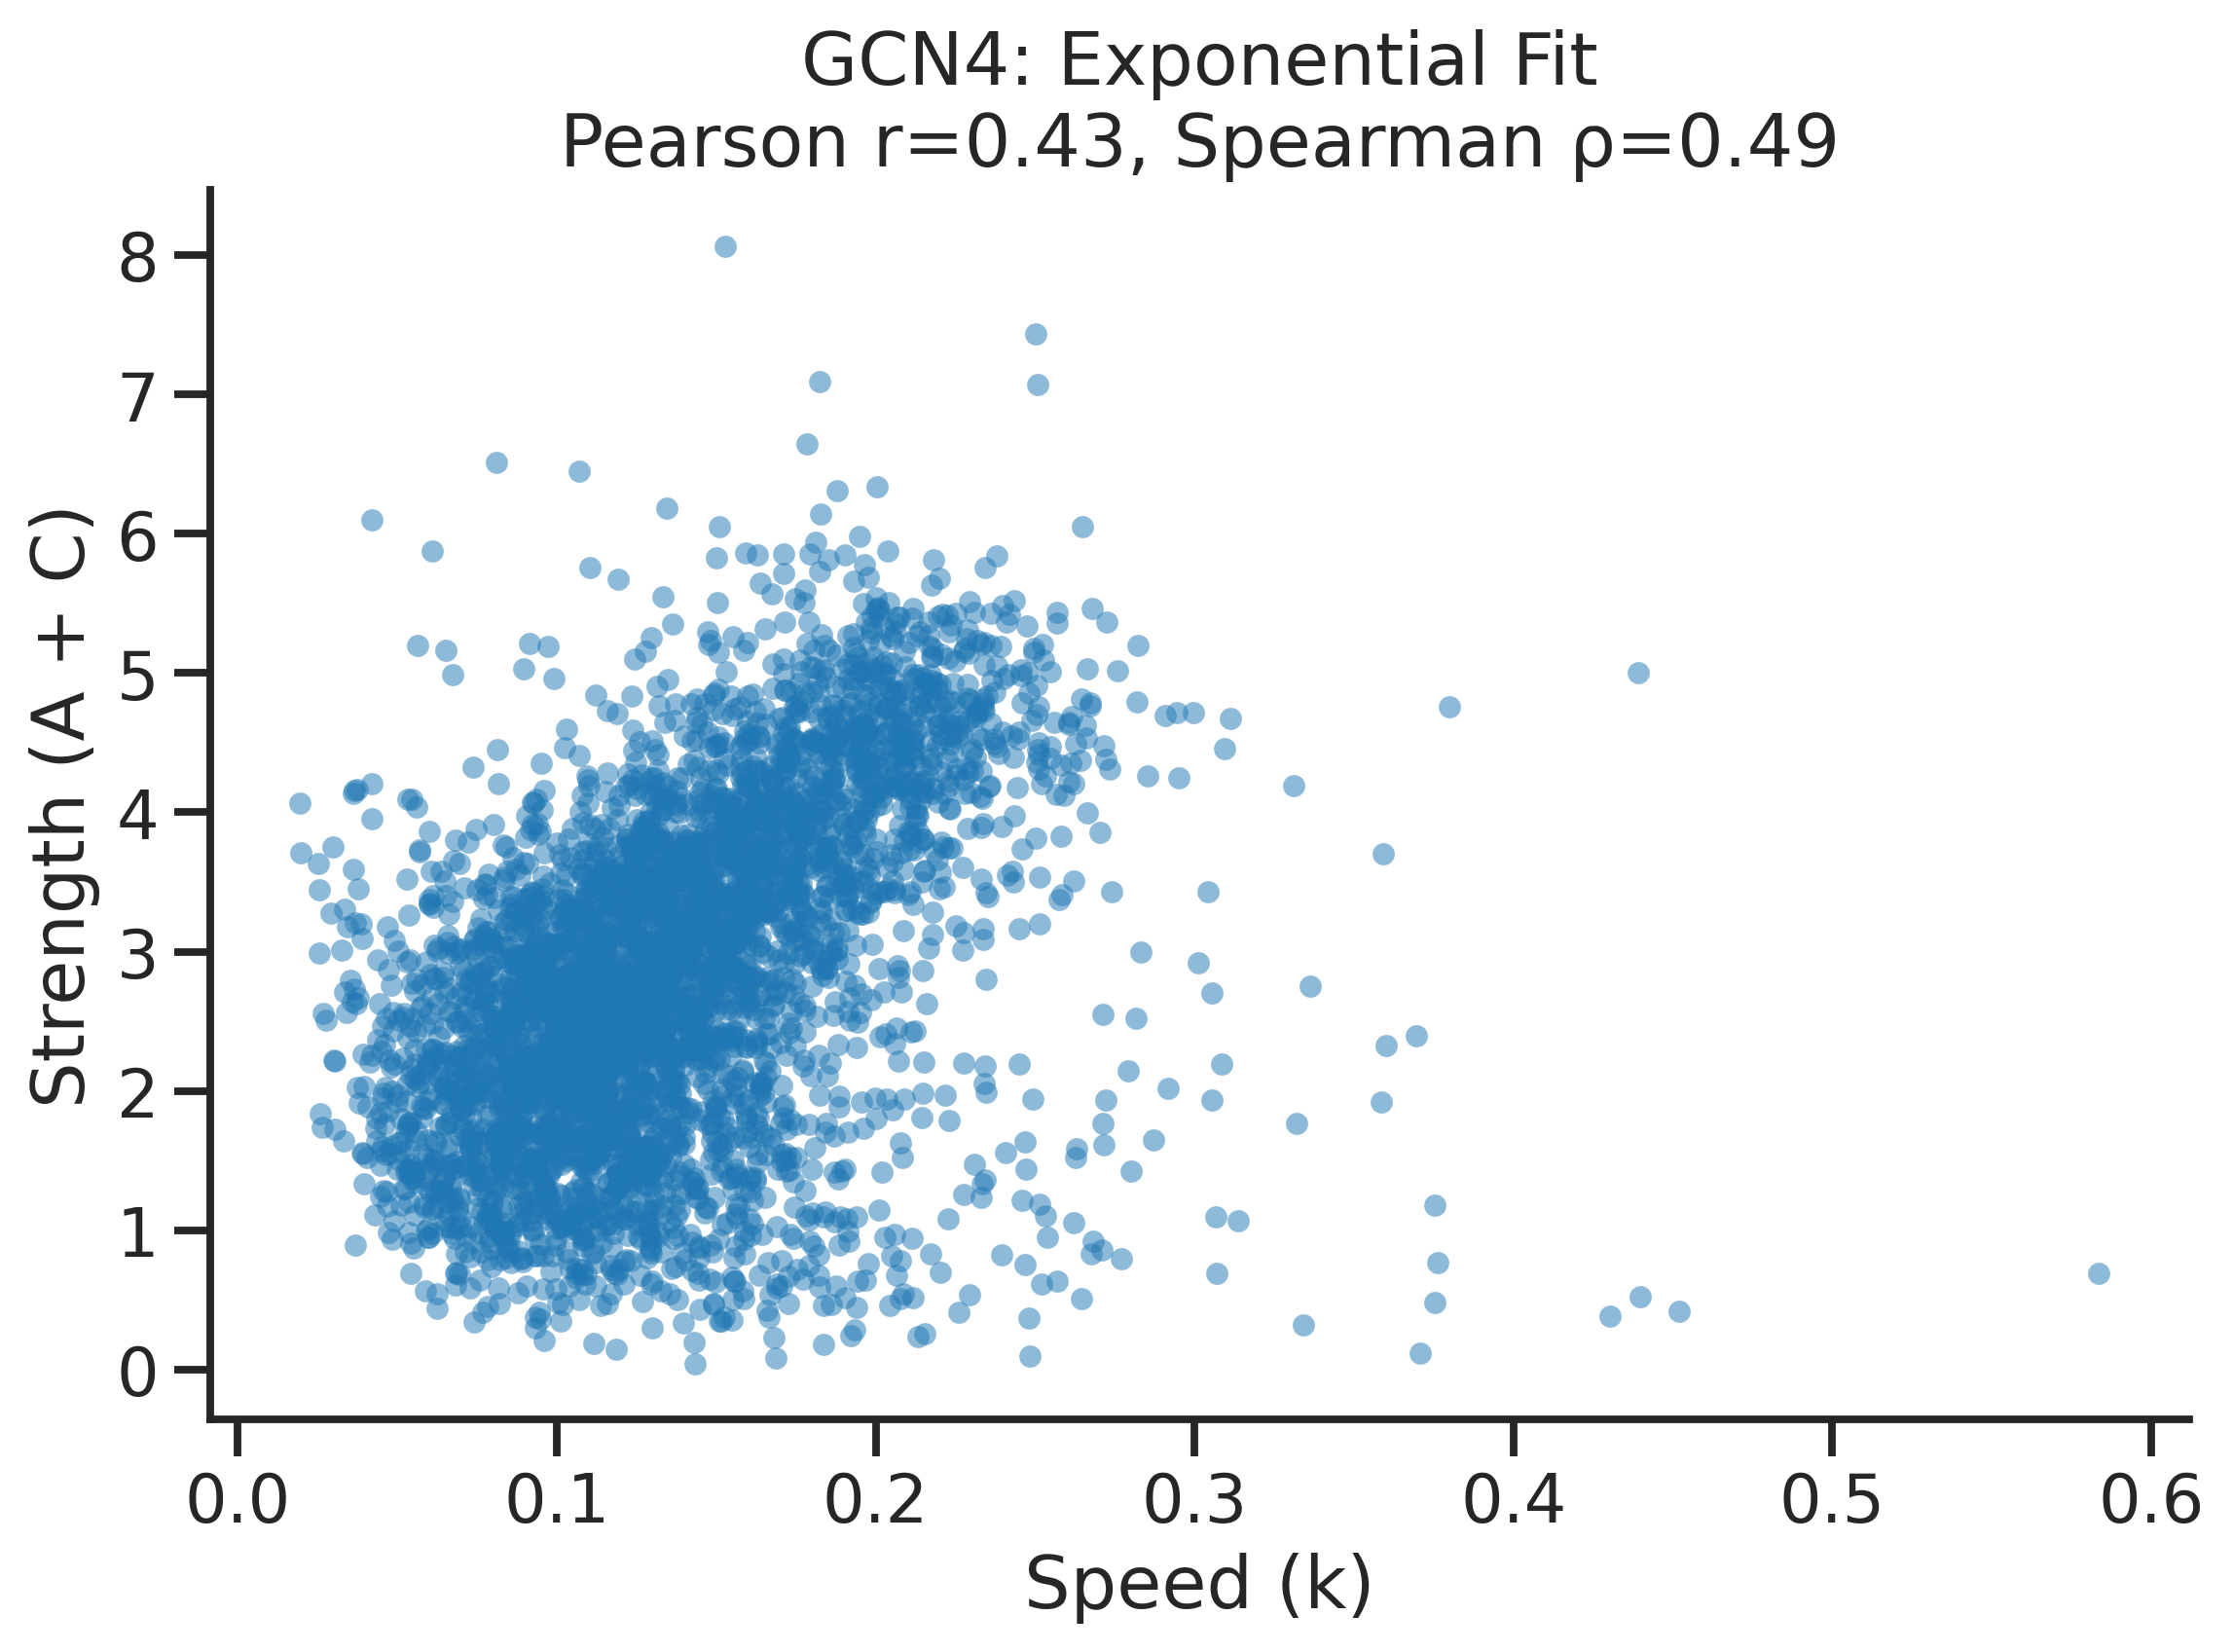

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['A+C'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['A+C'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Strength (A + C)')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.771, p = 0
Spearman rho = 0.794, p = 0


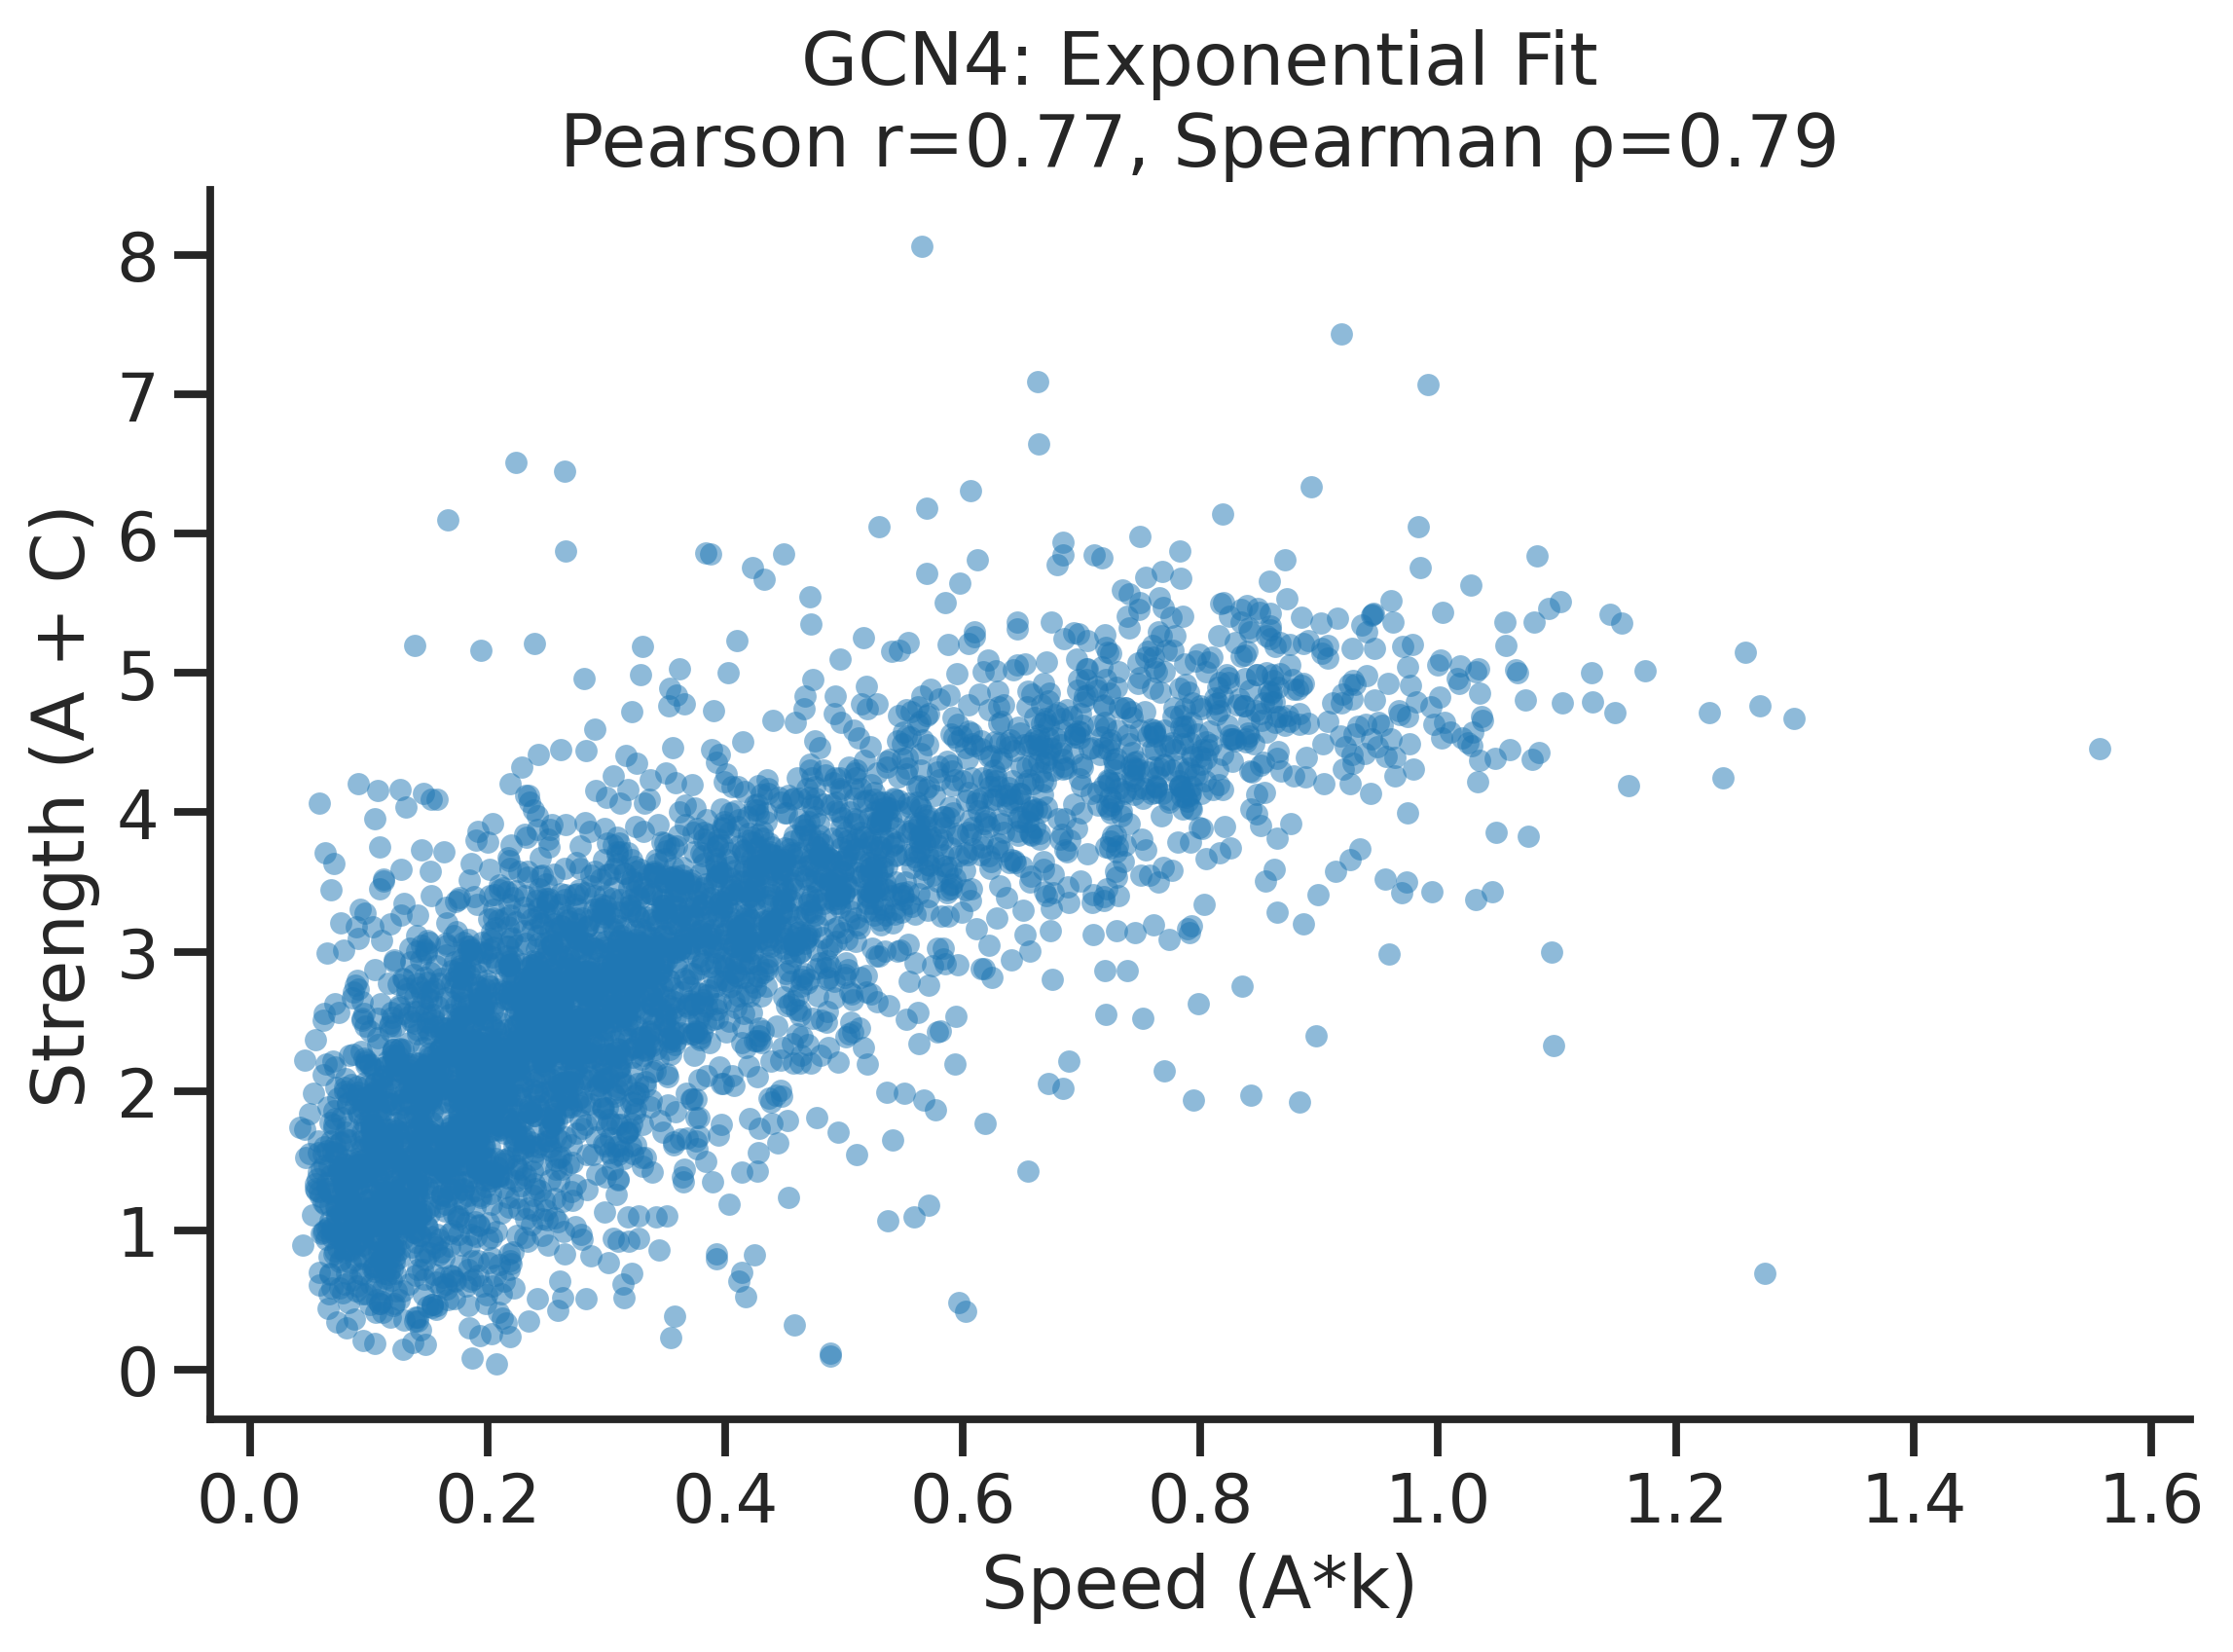

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['A*k'], ok ['A+C'])
spearman_corr, spearman_p = spearmanr(ok['A*k'], ok ['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['A*k'], ok['A+C'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (A*k)')
ax.set_ylabel('Strength (A + C)')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.854, p = 0
Spearman rho = 0.876, p = 0


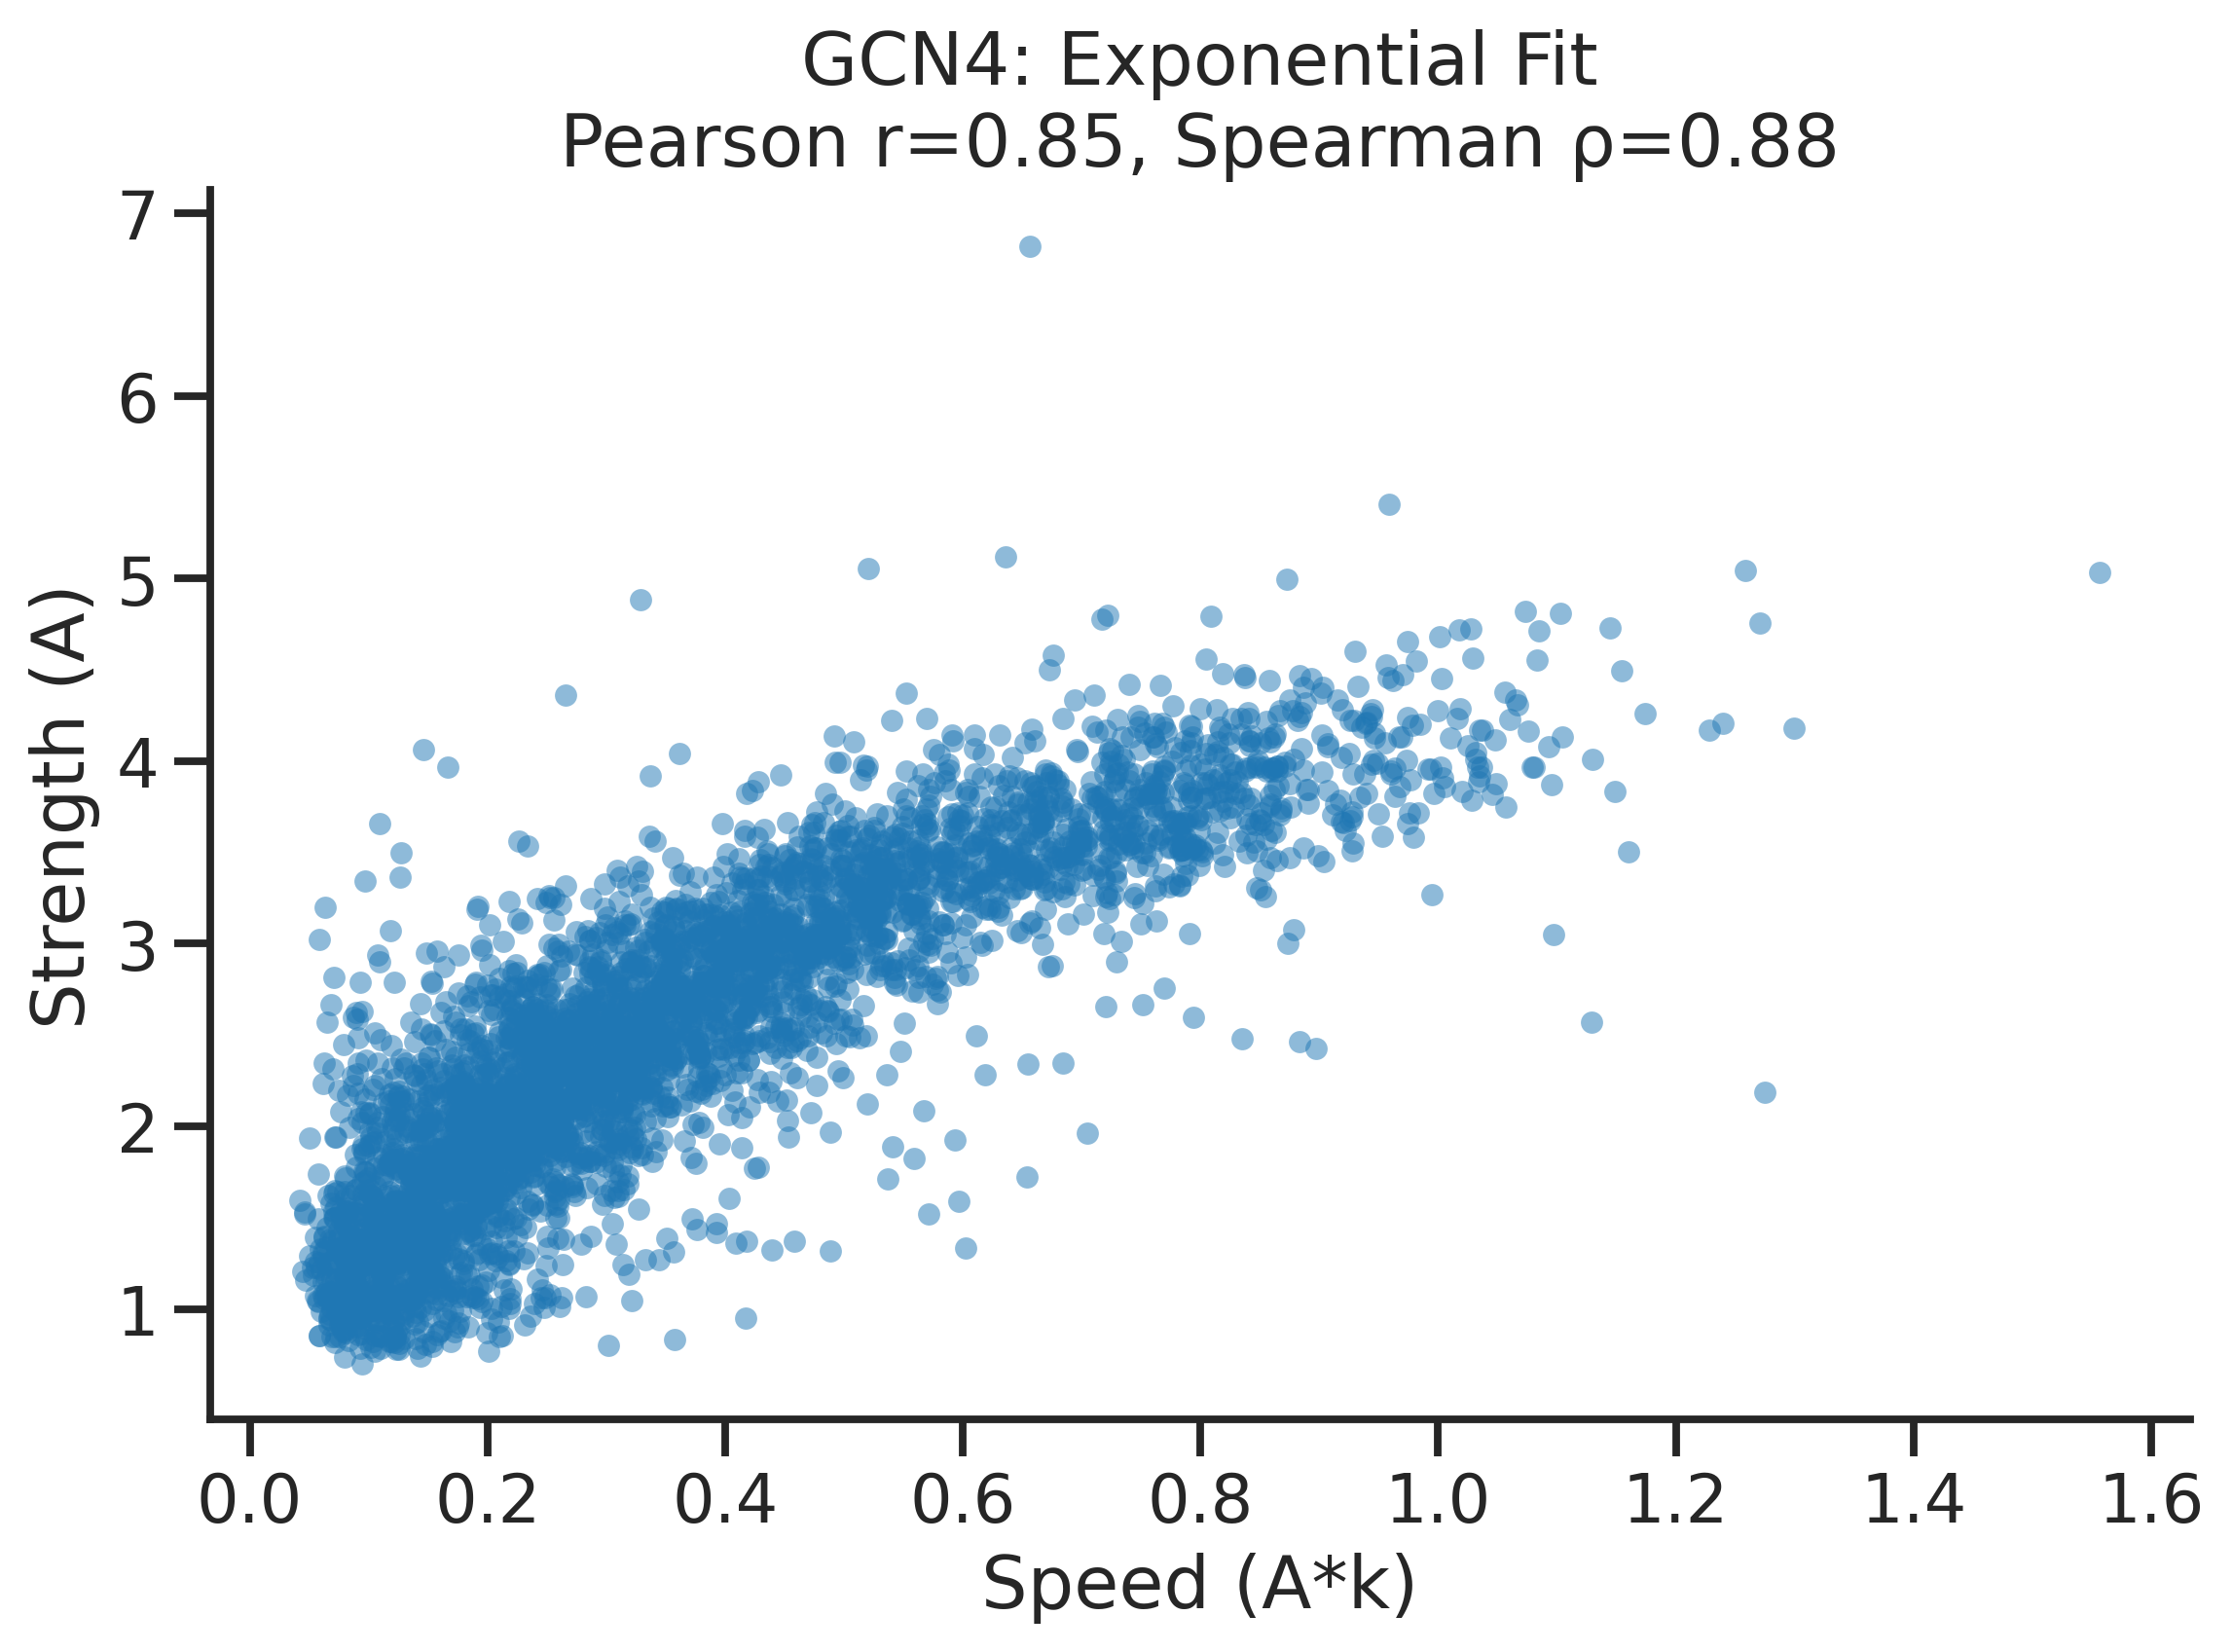

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['A*k'], ok ['A'])
spearman_corr, spearman_p = spearmanr(ok['A*k'], ok ['A'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['A*k'], ok['A'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (A*k)')
ax.set_ylabel('Strength (A)')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = -0.708, p = 0
Spearman rho = -0.768, p = 0


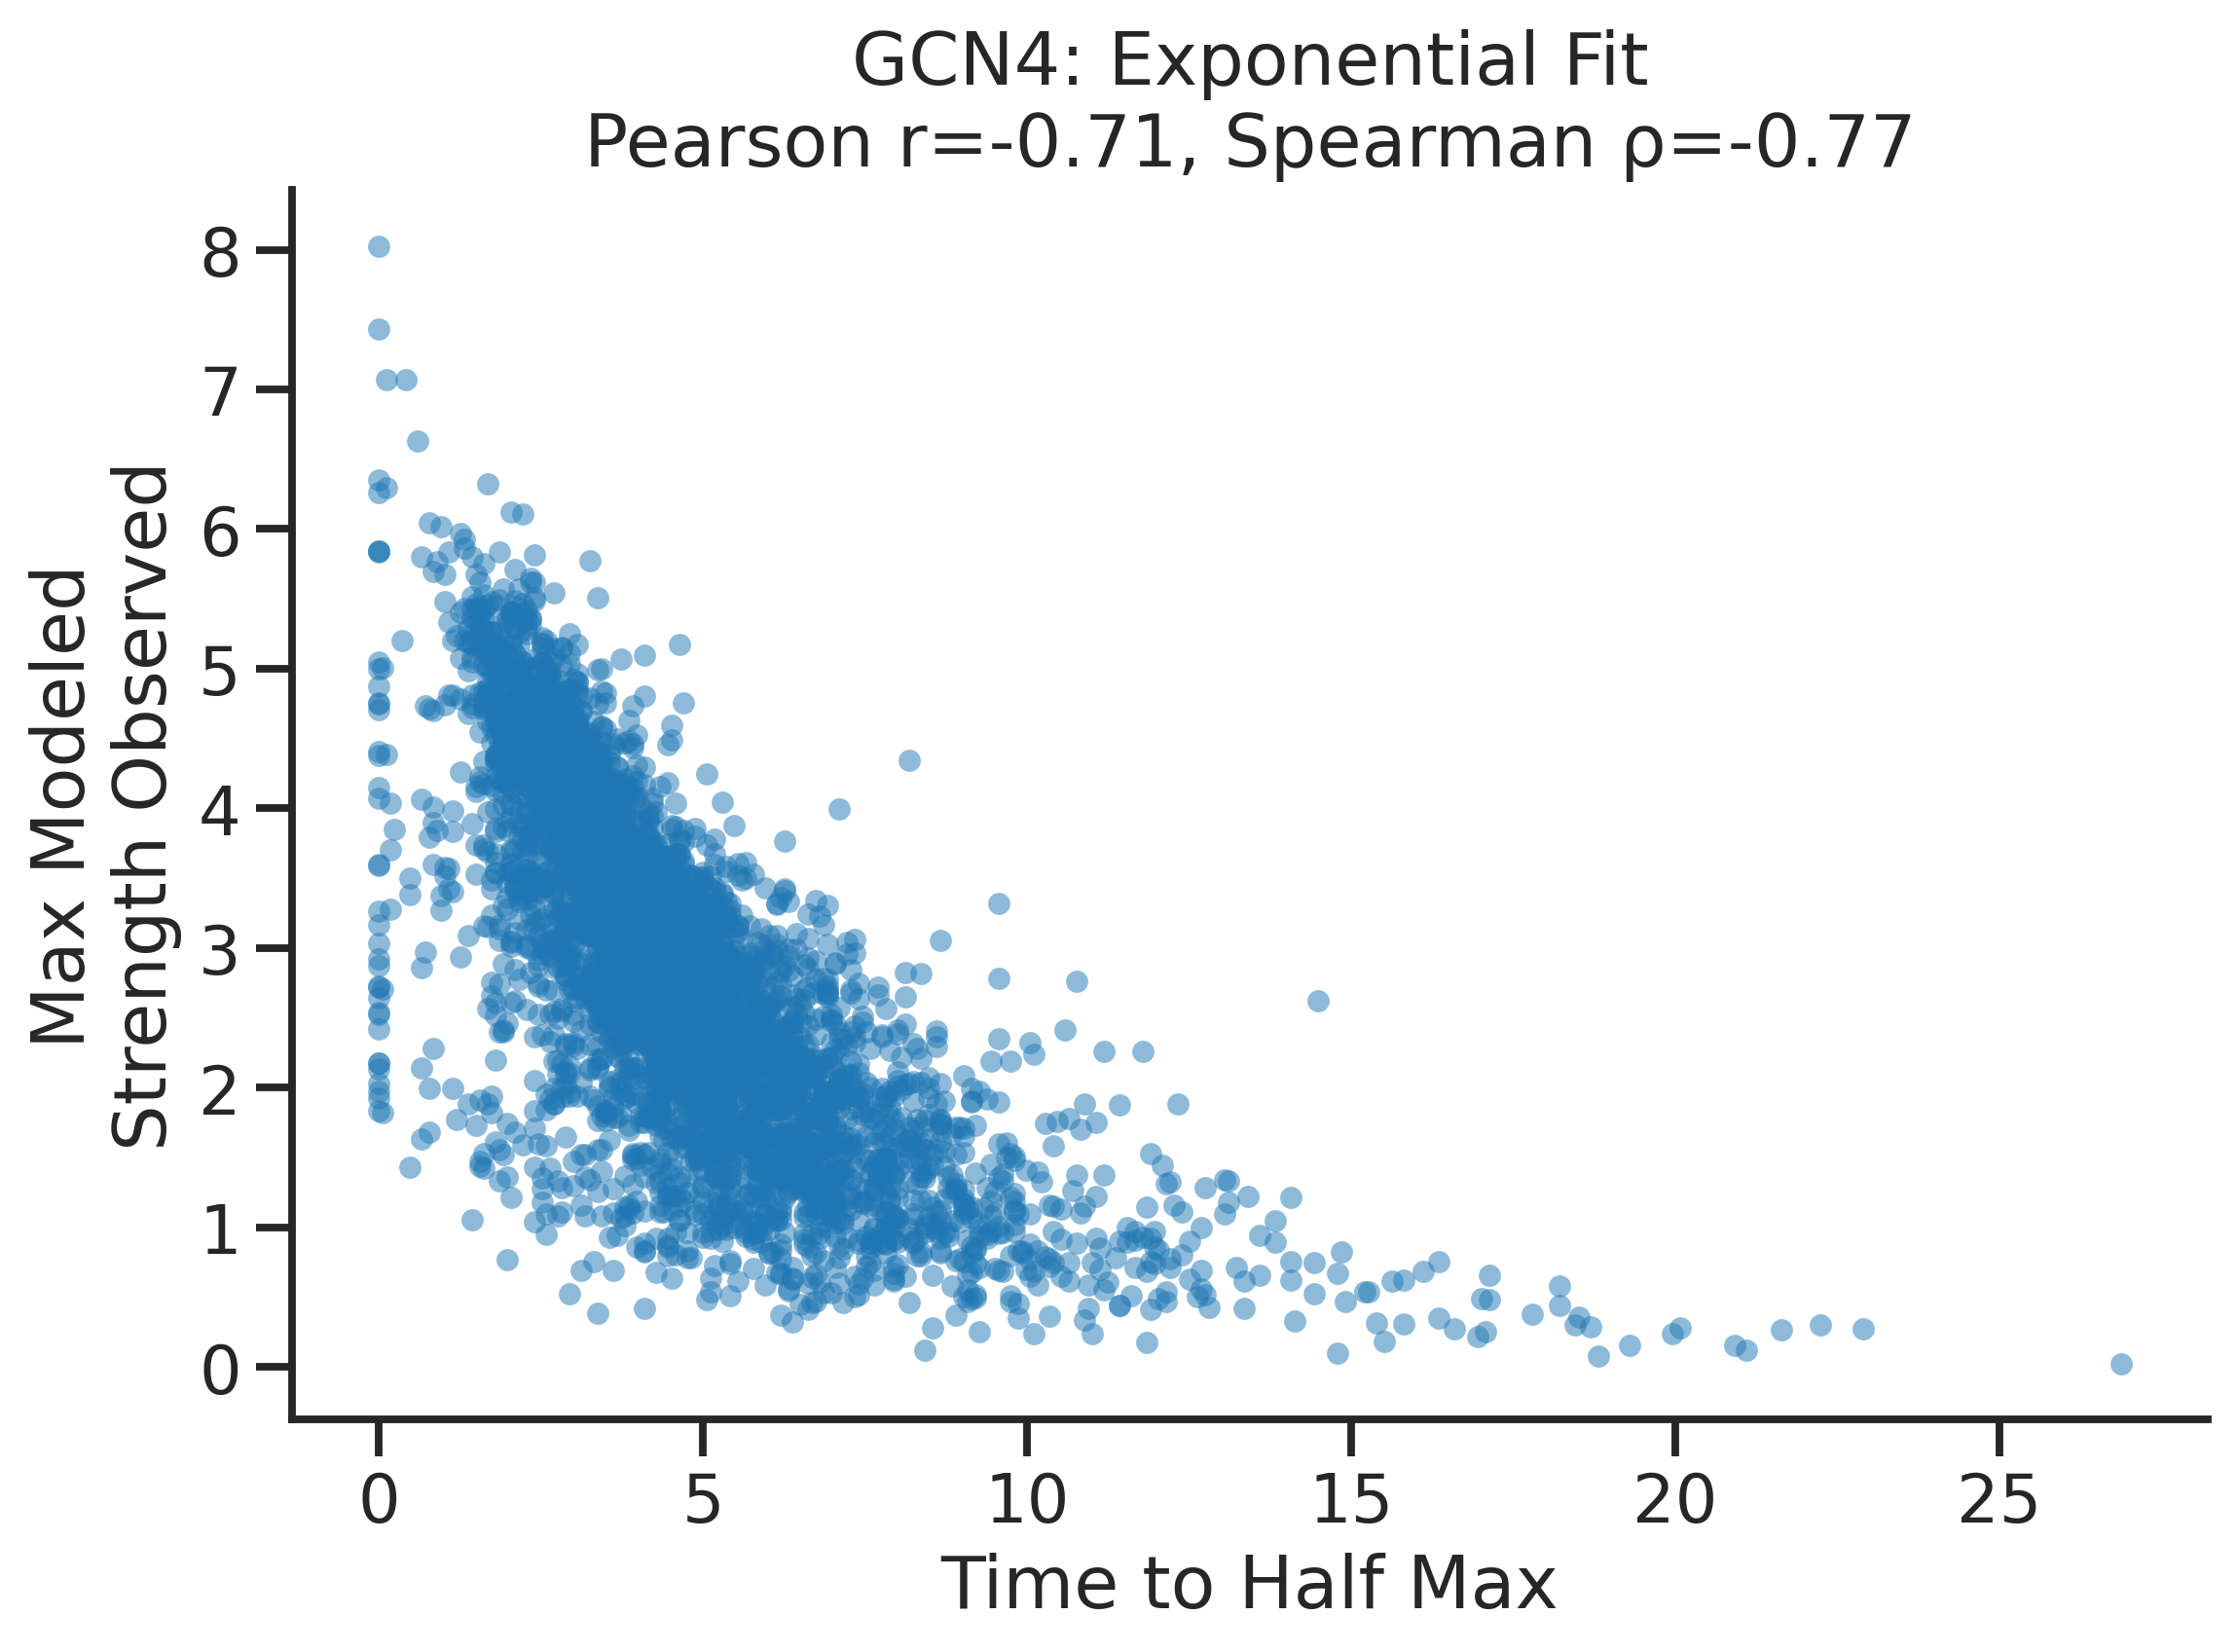

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_model_empirical'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_model_empirical'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_model_empirical'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.486, p = 1.87e-242
Spearman rho = 0.539, p = 8.9e-309


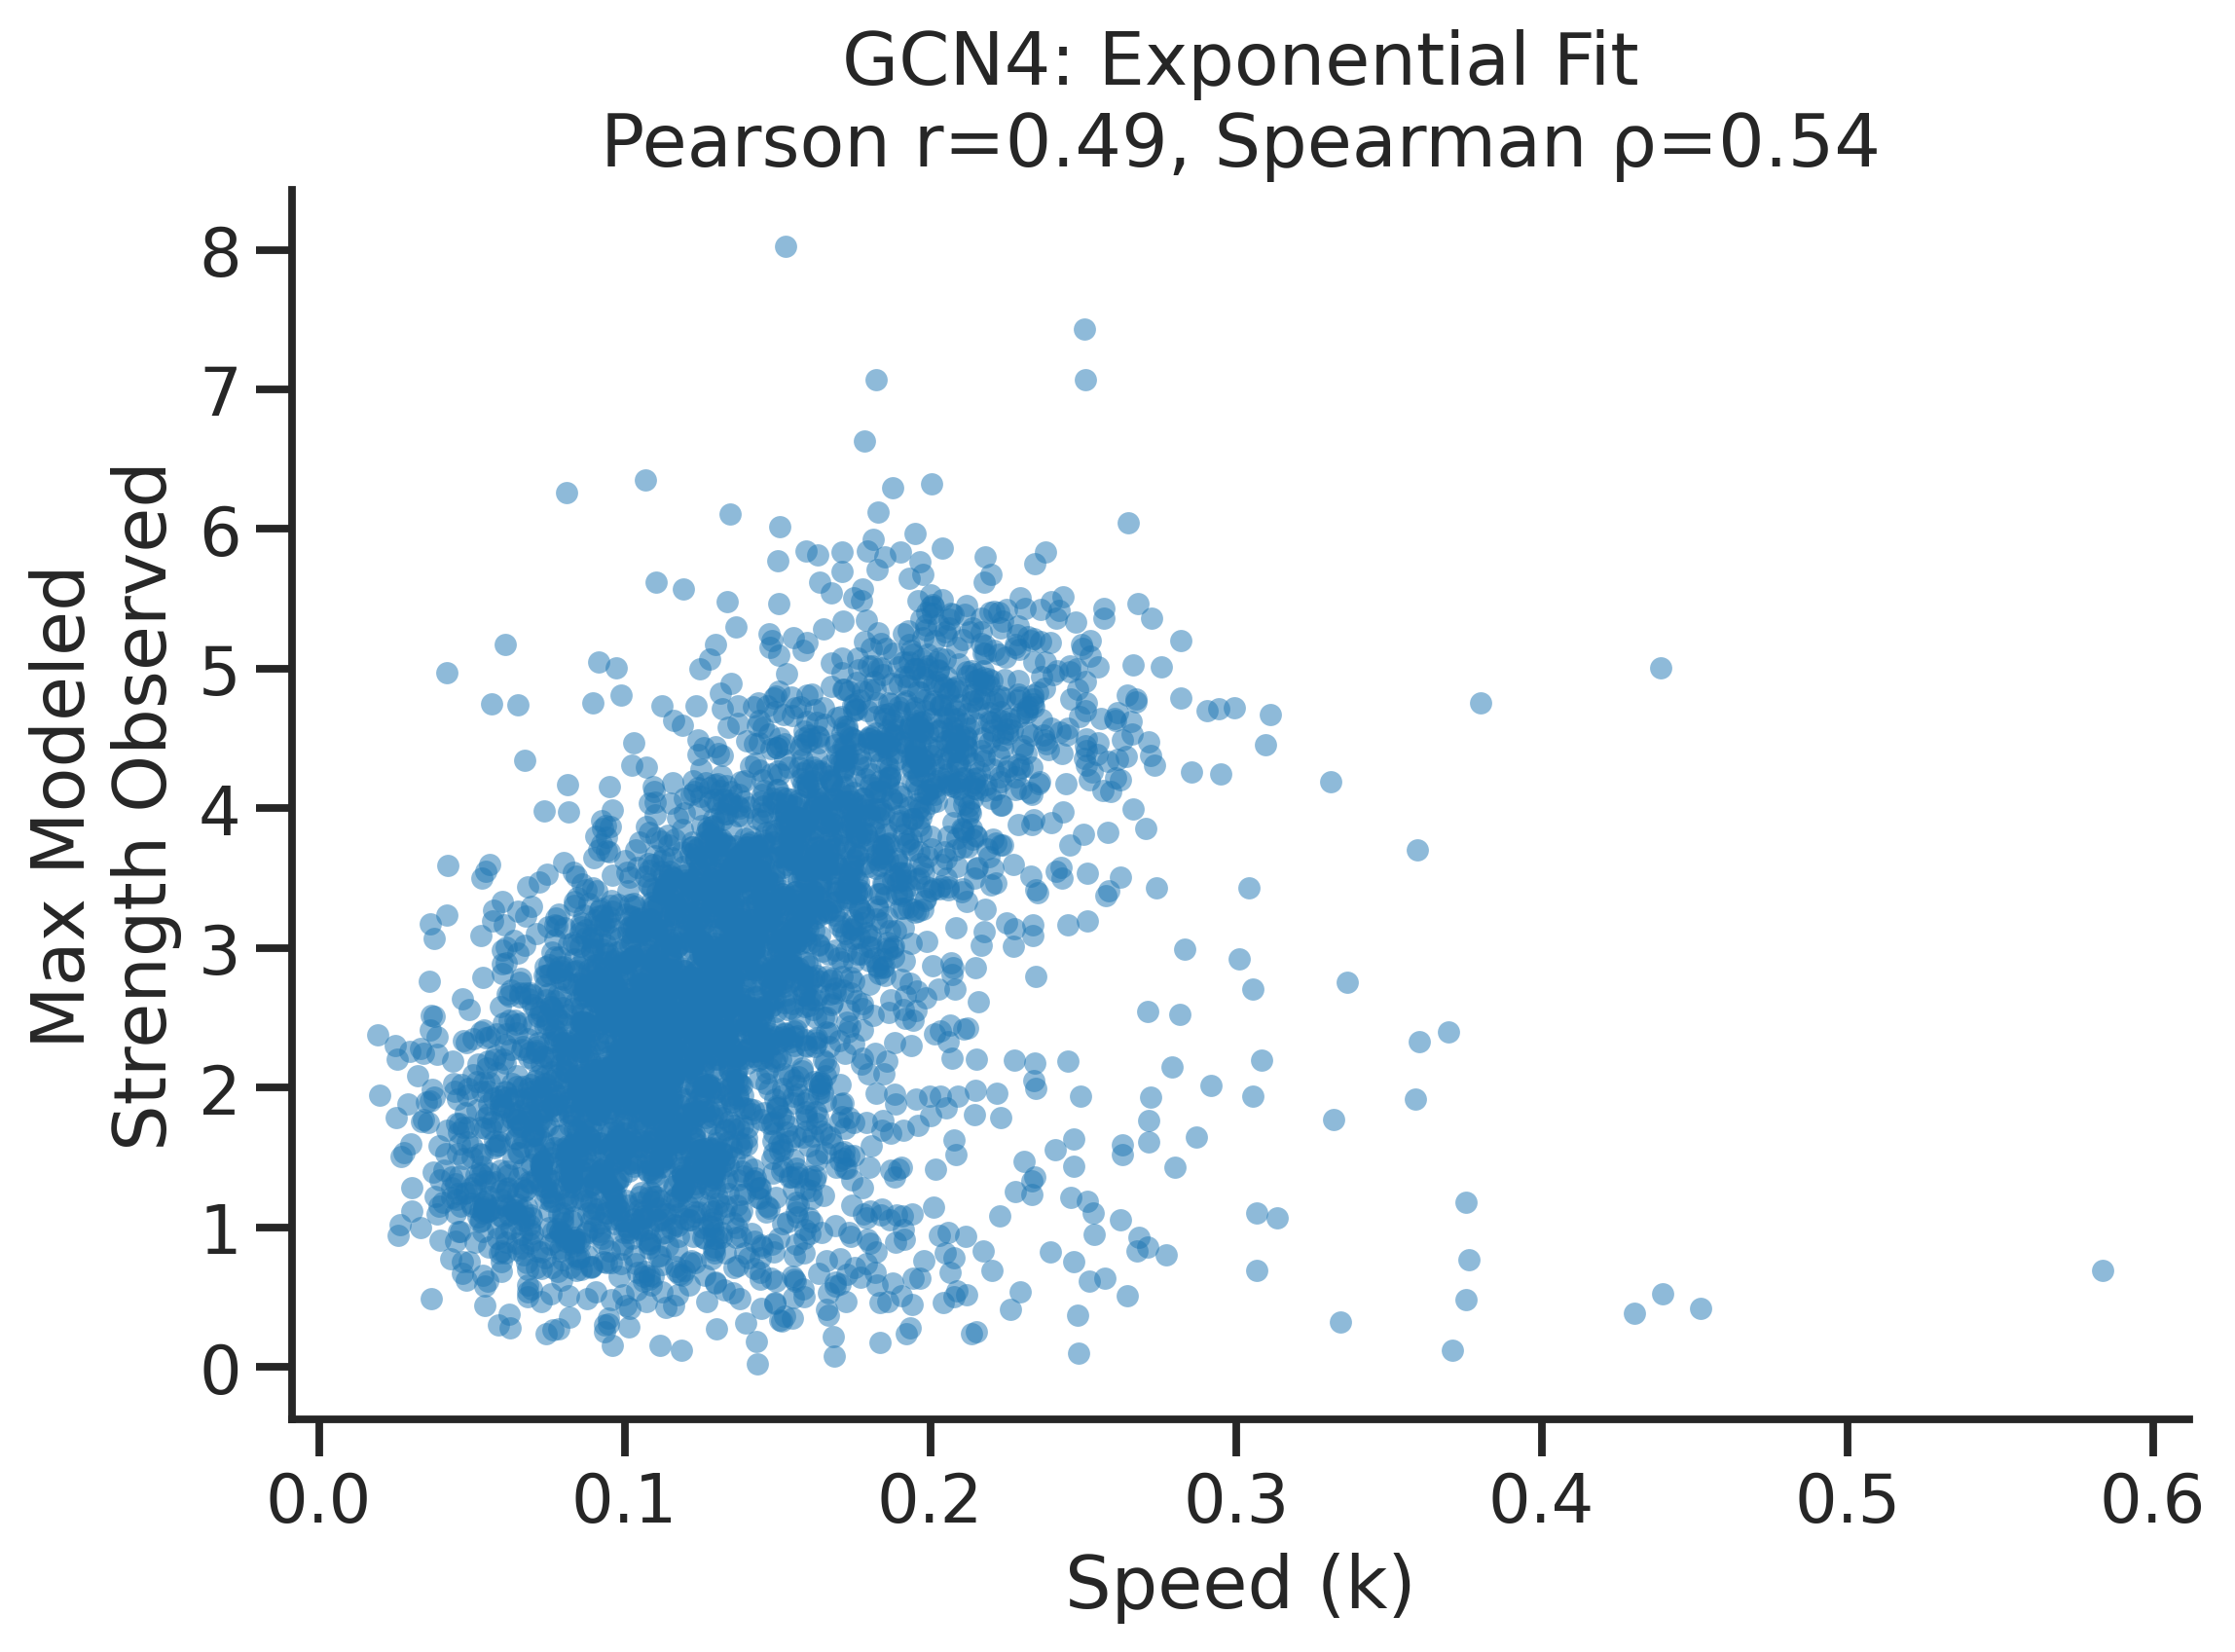

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.486, p = 1.87e-242
Spearman rho = 0.539, p = 8.9e-309


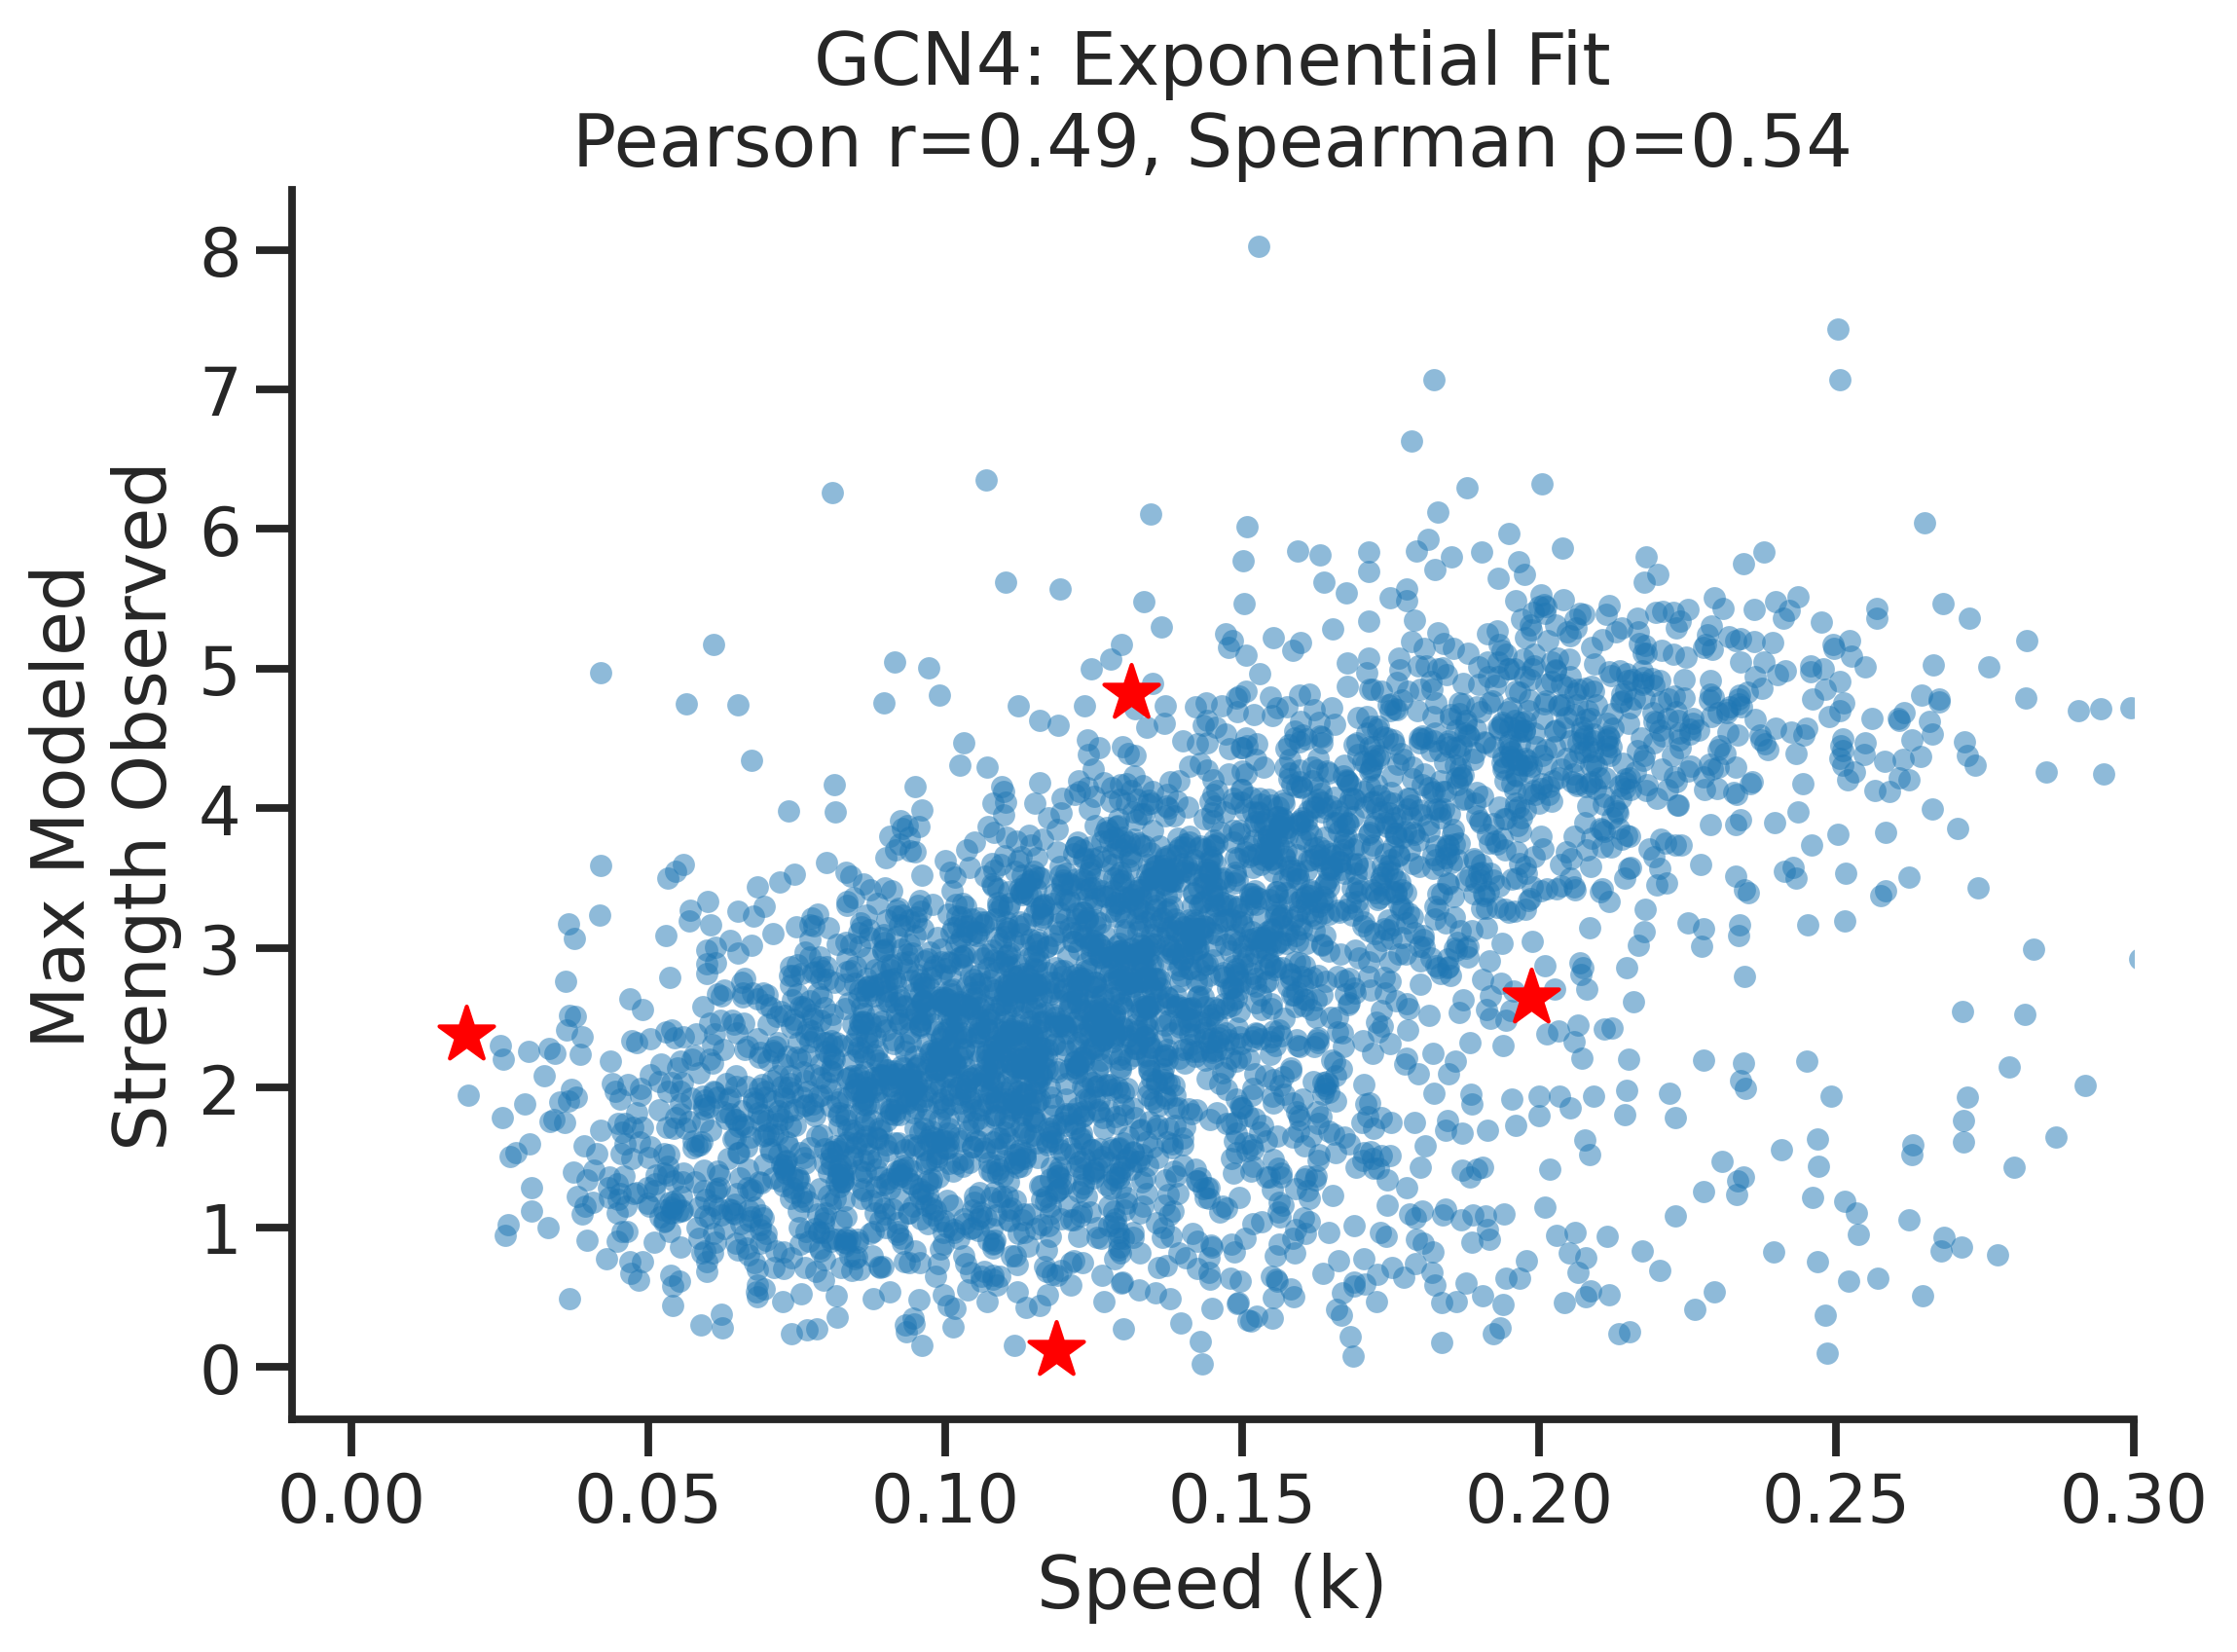

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['k'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)
ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

ax.set_xlim(-0.01, 0.3)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [31]:
 sns.color_palette('colorblind', n_colors=len(to_plot))

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

In [32]:
max_time = 30

<Figure size 1920x1440 with 0 Axes>

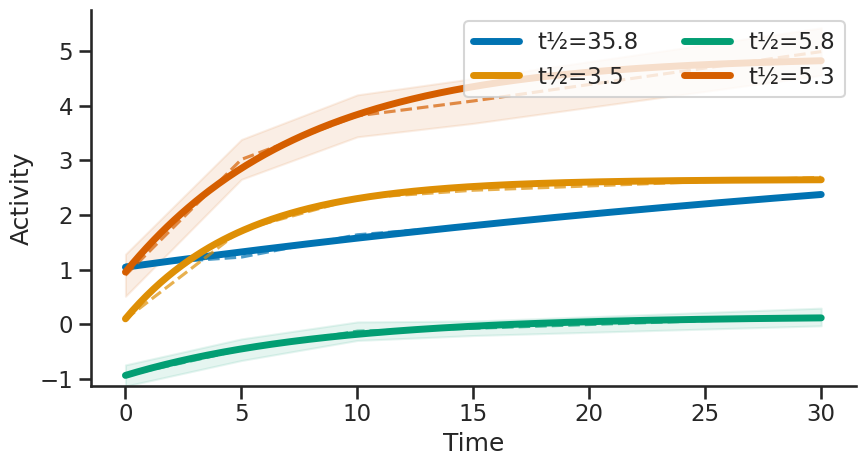

In [33]:
plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)
fig, ax = plt.subplots(figsize=(9,5))

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

for (_, row), color in zip(to_plot.iterrows(), colors):
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    ax.fill_between(t, y - sigma, y + sigma, color=color, alpha=0.1)
    ax.plot(t, y, color=color, markersize=4, alpha=0.7, linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
            color=color, linewidth=5, alpha=1,
            label=f"t½={row['t_half']:.1f}")

ax.set_xlabel('Time')
ax.set_ylabel('Activity')

# get lowest observed value across all plotted sequences
grps = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity'] - grps['error']).min()
ax.set_ylim(bottom=y_min)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1,1), loc='upper right', ncols = 2)
sns.despine()
plt.tight_layout()
plt.show()

<Figure size 1920x1440 with 0 Axes>

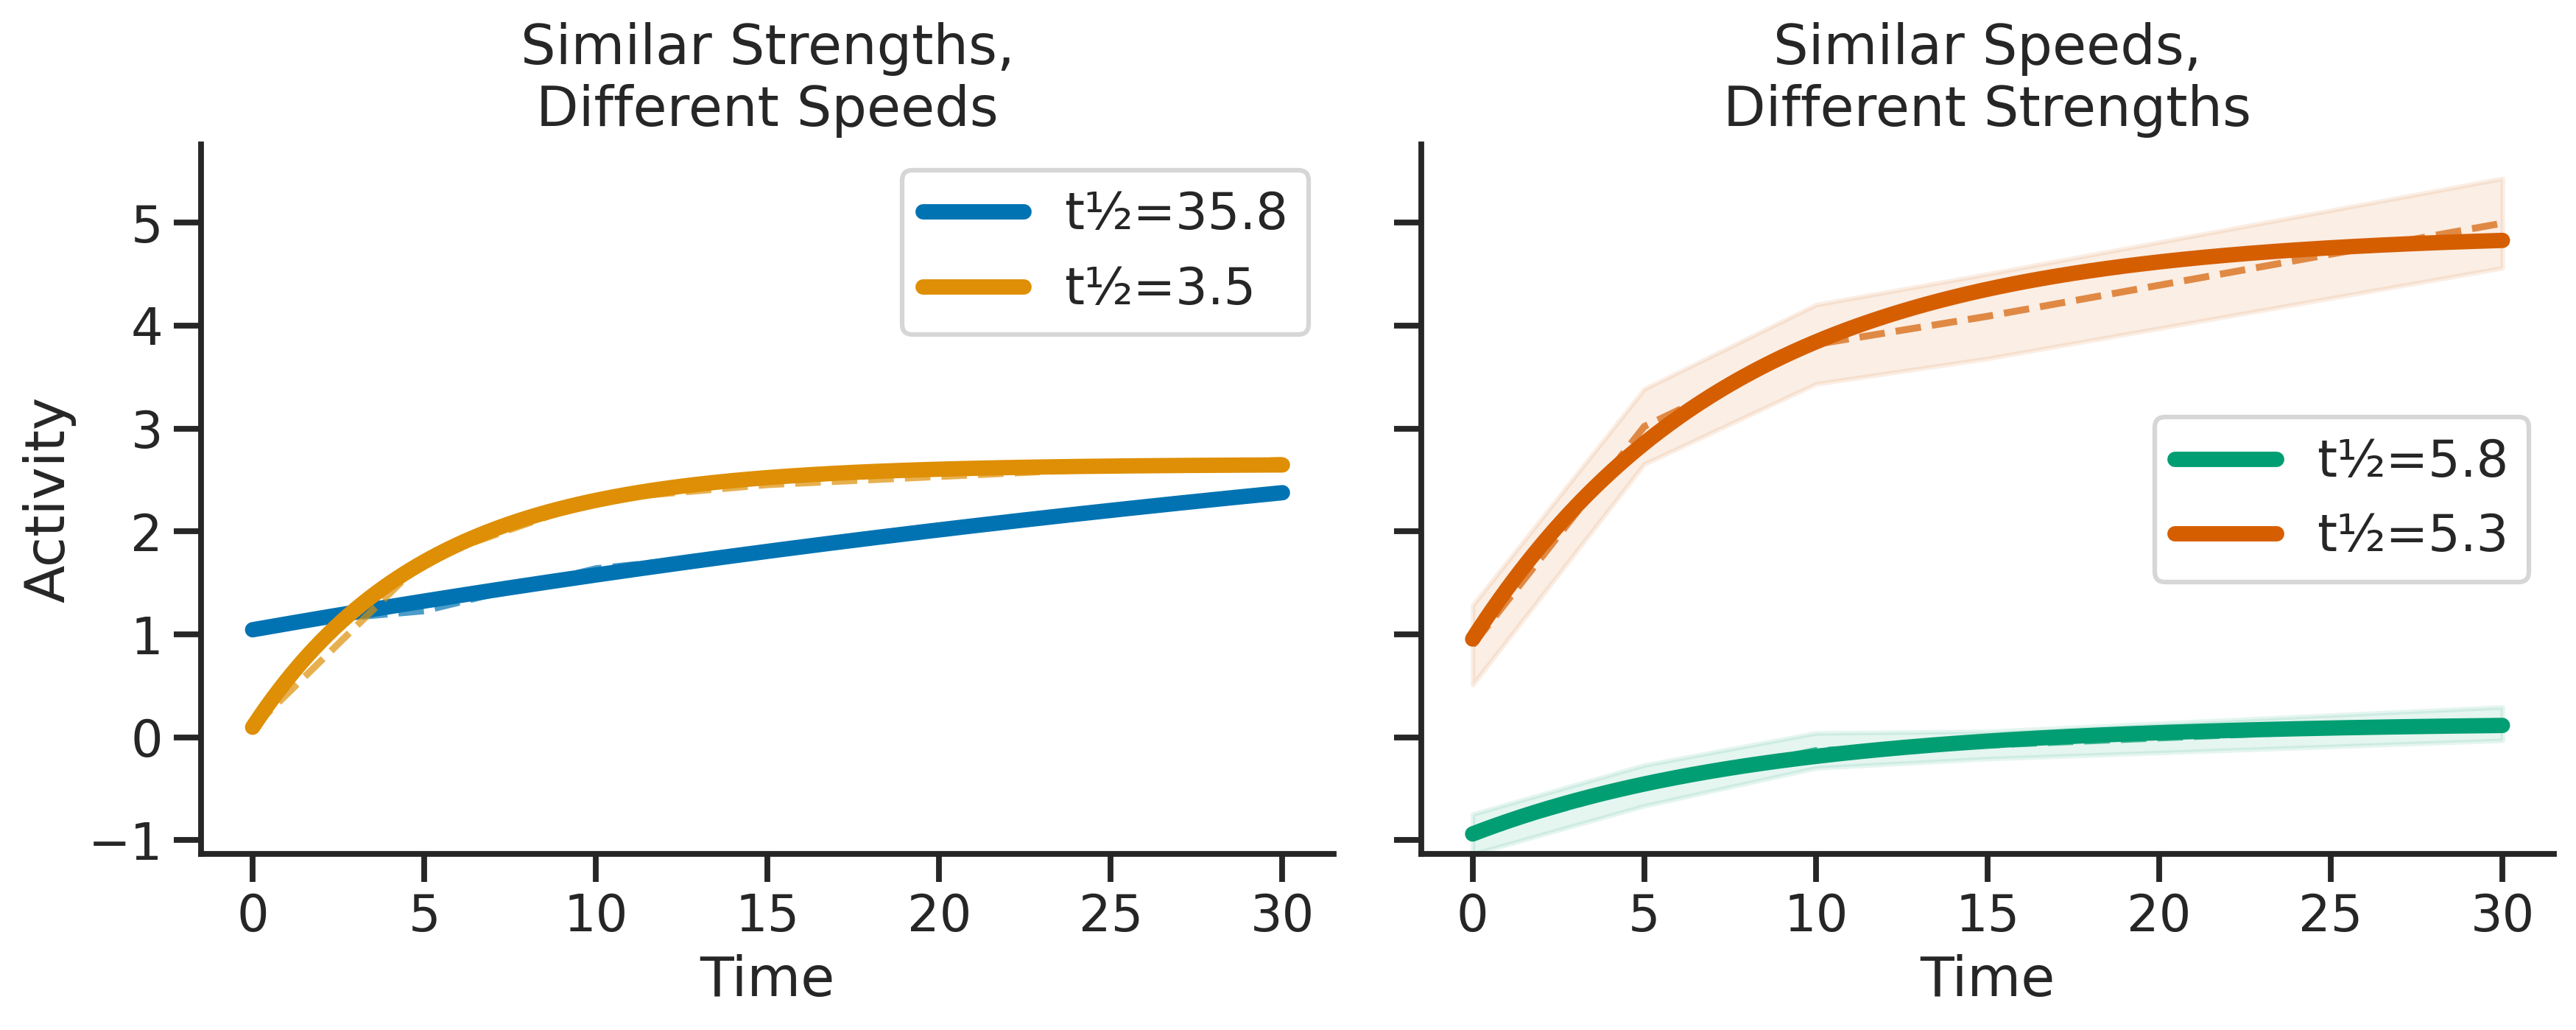

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi = 300)

# Colors for 4 sequences
colors = sns.color_palette('colorblind', n_colors=len(to_plot))

# --- first subplot: sequences 1 and 3 ---
for idx in [0, 1]:
    row = to_plot.iloc[idx]
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    axs[0].fill_between(t, y - sigma, y + sigma, color=colors[idx], alpha=0.1)
    axs[0].plot(t, y, color=colors[idx], markersize=4, alpha=0.7, linestyle='dashed')
    axs[0].plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
                color=colors[idx], linewidth=5, alpha=1,
                label=f"t½={row['t_half']:.1f}")

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].legend()
sns.despine(ax=axs[0])
axs[0].set_title("Similar Strengths,\nDifferent Speeds")

# --- second subplot: sequences 2 and 4 ---
for idx in [2, 3]:
    row = to_plot.iloc[idx]
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    axs[1].fill_between(t, y - sigma, y + sigma, color=colors[idx], alpha=0.1)
    axs[1].plot(t, y, color=colors[idx], markersize=4, alpha=0.7, linestyle='dashed')
    axs[1].plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
                color=colors[idx], linewidth=5, alpha=1,
                label=f"t½={row['t_half']:.1f}", zorder = 0)

axs[1].set_xlabel('Time')
axs[1].legend()
sns.despine(ax=axs[1])

# Set shared y-axis minimum
grps = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity'] - grps['error']).min()
for ax in axs:
    ax.set_ylim(bottom=y_min)
    
axs[1].set_title("Similar Speeds,\nDifferent Strengths")

plt.tight_layout()
plt.show()

# Subtracting t = 0 from everything

In [35]:
# Make a copy to avoid modifying original
activities_norm = active_tile_activities_count_filtered.copy()

# Get the time=0 activity for each ADseq
baseline = activities_norm[activities_norm["time"] == 0][["ADseq", "activity"]].set_index("ADseq")

# Subtract baseline from all time points
activities_norm = activities_norm.join(baseline, on="ADseq", rsuffix="_0")
activities_norm["activity_norm"] = activities_norm["activity"] - activities_norm["activity_0"]

# Optional: remove negative values if your exponential fit cannot handle them
activities_norm["activity_norm"] = activities_norm["activity_norm"].clip(lower=0)

# Now activities_norm["activity_norm"] is ready for exponential fitting
activities_norm = activities_norm.drop(columns = "activity_0")
activities_norm

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000,-0.114075,0.120087
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383,-0.498641,0.803710
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723,0.282038,1.251861
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393,0.125816,1.429790
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000,NaN,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881,NaN,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294,NaN,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377,NaN,NaN


In [36]:
last_activity = (
    activities_norm.sort_values("time")
      .groupby("ADseq", as_index=False)
      .tail(1)[["ADseq", "activity"]]
)
min(last_activity["activity"])

-1.1995151978315242

In [37]:
fit_results_norm = fit_rising_exponentials(
    activities_norm,
    time_col="time",
    activity_col="activity_norm",
    error_col="error",
    min_points=5,
    subtract_baseline=False,
    verbose=True
)

fit_results_norm

Fitting: 100%|██████████| 4713/4713 [01:06<00:00, 70.80it/s] 


,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.094331,0.319867,6.022144,1.926989,3.599229,5.531062,0.972274,ok,NaN
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,-0.002075,0.059638,9.289001,7.834024,1.235476,7.935872,0.960851,ok,NaN
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,0.001900,0.040876,4.727820,0.548043,2.170885,4.629259,0.985961,ok,NaN
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,0.017690,0.118027,4.346844,0.528314,1.993799,4.268537,0.995732,ok,NaN
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,0.008151,0.154746,4.455660,0.689937,2.505392,4.388778,0.998874,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,3.368061,0.071460,0.141788,0.007293,0.002198,0.051669,4.888605,0.251443,3.322391,4.809619,0.999213,ok,NaN
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,3.441662,0.104211,0.157731,0.008328,0.133935,0.102140,4.394499,0.232036,3.545278,4.088176,0.990357,ok,NaN
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,2.523455,0.092592,0.133525,0.011832,0.011755,0.065568,5.191132,0.460007,2.489257,5.050100,0.997692,ok,NaN
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.689938,0.100656,0.055910,0.007066,0.015100,0.031002,12.397552,1.566757,1.389226,9.198397,0.998031,ok,NaN


In [38]:
ok_norm = fit_results_norm[
    (fit_results_norm['flag'] == 'ok') &
    (fit_results_norm['r_squared'] > 0.7) 
].copy()

print(f"Keeping {len(ok_norm)} / {len(fit_results_norm)} sequences ({100*len(ok_norm)/len(fit_results_norm):.1f}%)")

Keeping 4572 / 4713 sequences (97.0%)


In [39]:
ok_norm.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/exponential_fit_baseline_norm.csv")

In [40]:
not_ok_norm = fit_results_norm[~fit_results_norm["ADseq"].isin(ok_norm["ADseq"])]
not_ok_norm

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
80,AFSLEEFTAFGGGASTTAYSSPAIPGYDVNASSSSSSTTN,185.218457,9.996170e+04,2.916193e-04,1.581022e-01,0.418438,0.813293,2.376890e+03,1.288638e+06,2.031769,11.062124,0.484381,ok,NaN
140,ALAAQLLTGHAAEPNVAYHSTFGELSSTGDGGLFGMDEHF,42360.184584,5.200161e-12,5.779984e-07,3.660957e-07,0.025467,0.245198,1.199220e+06,7.595685e+05,0.759984,14.488978,0.554879,ok,NaN
154,ALQNQRVAAIIQSTGHSINTSALTNRFTPQQSSIQQFYAS,44229.129242,6.622507e-12,5.333464e-07,5.243860e-07,0.049378,0.366711,1.299619e+06,1.277785e+06,0.757056,13.947896,0.340934,ok,NaN
170,ALTSLTSPSIYGDTSPDFGDGYDVSPSFGSGDFDVPSSDV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN
209,APNSTAFTALTSPSPYESPDFDVYDVSPHFSTTDFDSGGP,28278.357467,2.264611e-10,2.139738e-06,1.778946e-06,0.335377,0.795360,3.239403e+05,2.693192e+05,2.150567,12.204409,0.419766,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4578,VSSEQPLLRFSRSPTATIPPQDFTVFTTDSQQSTWLPSRA,0.718070,7.746331e-01,1.786414e-01,4.817424e-01,-0.037286,0.595281,3.880105e+00,1.046348e+01,0.677406,4.148297,0.319218,ok,NaN
4579,VSVFGASSQVELFSLETRFAQLINLSSIDVPFHSSSRFPY,1.112536,2.261685e+00,3.232938e-02,1.078263e-01,0.075989,0.246748,2.144016e+01,7.150817e+01,0.766732,9.979960,0.659994,ok,NaN
4620,WYPLFPSMGDAGAEVTSKPLQAPVDVSAVNAALDDATTMR,1.154626,5.865416e-01,1.391321e-01,1.711063e-01,-0.051844,0.421435,4.981936e+00,6.126846e+00,1.085010,5.170341,0.689980,ok,NaN
4622,WYSLFPETNPDPEDSVSPPMPNIPQTDALIGDQSGRLDEE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fit_error: Residuals are not finite in the ini...,NaN


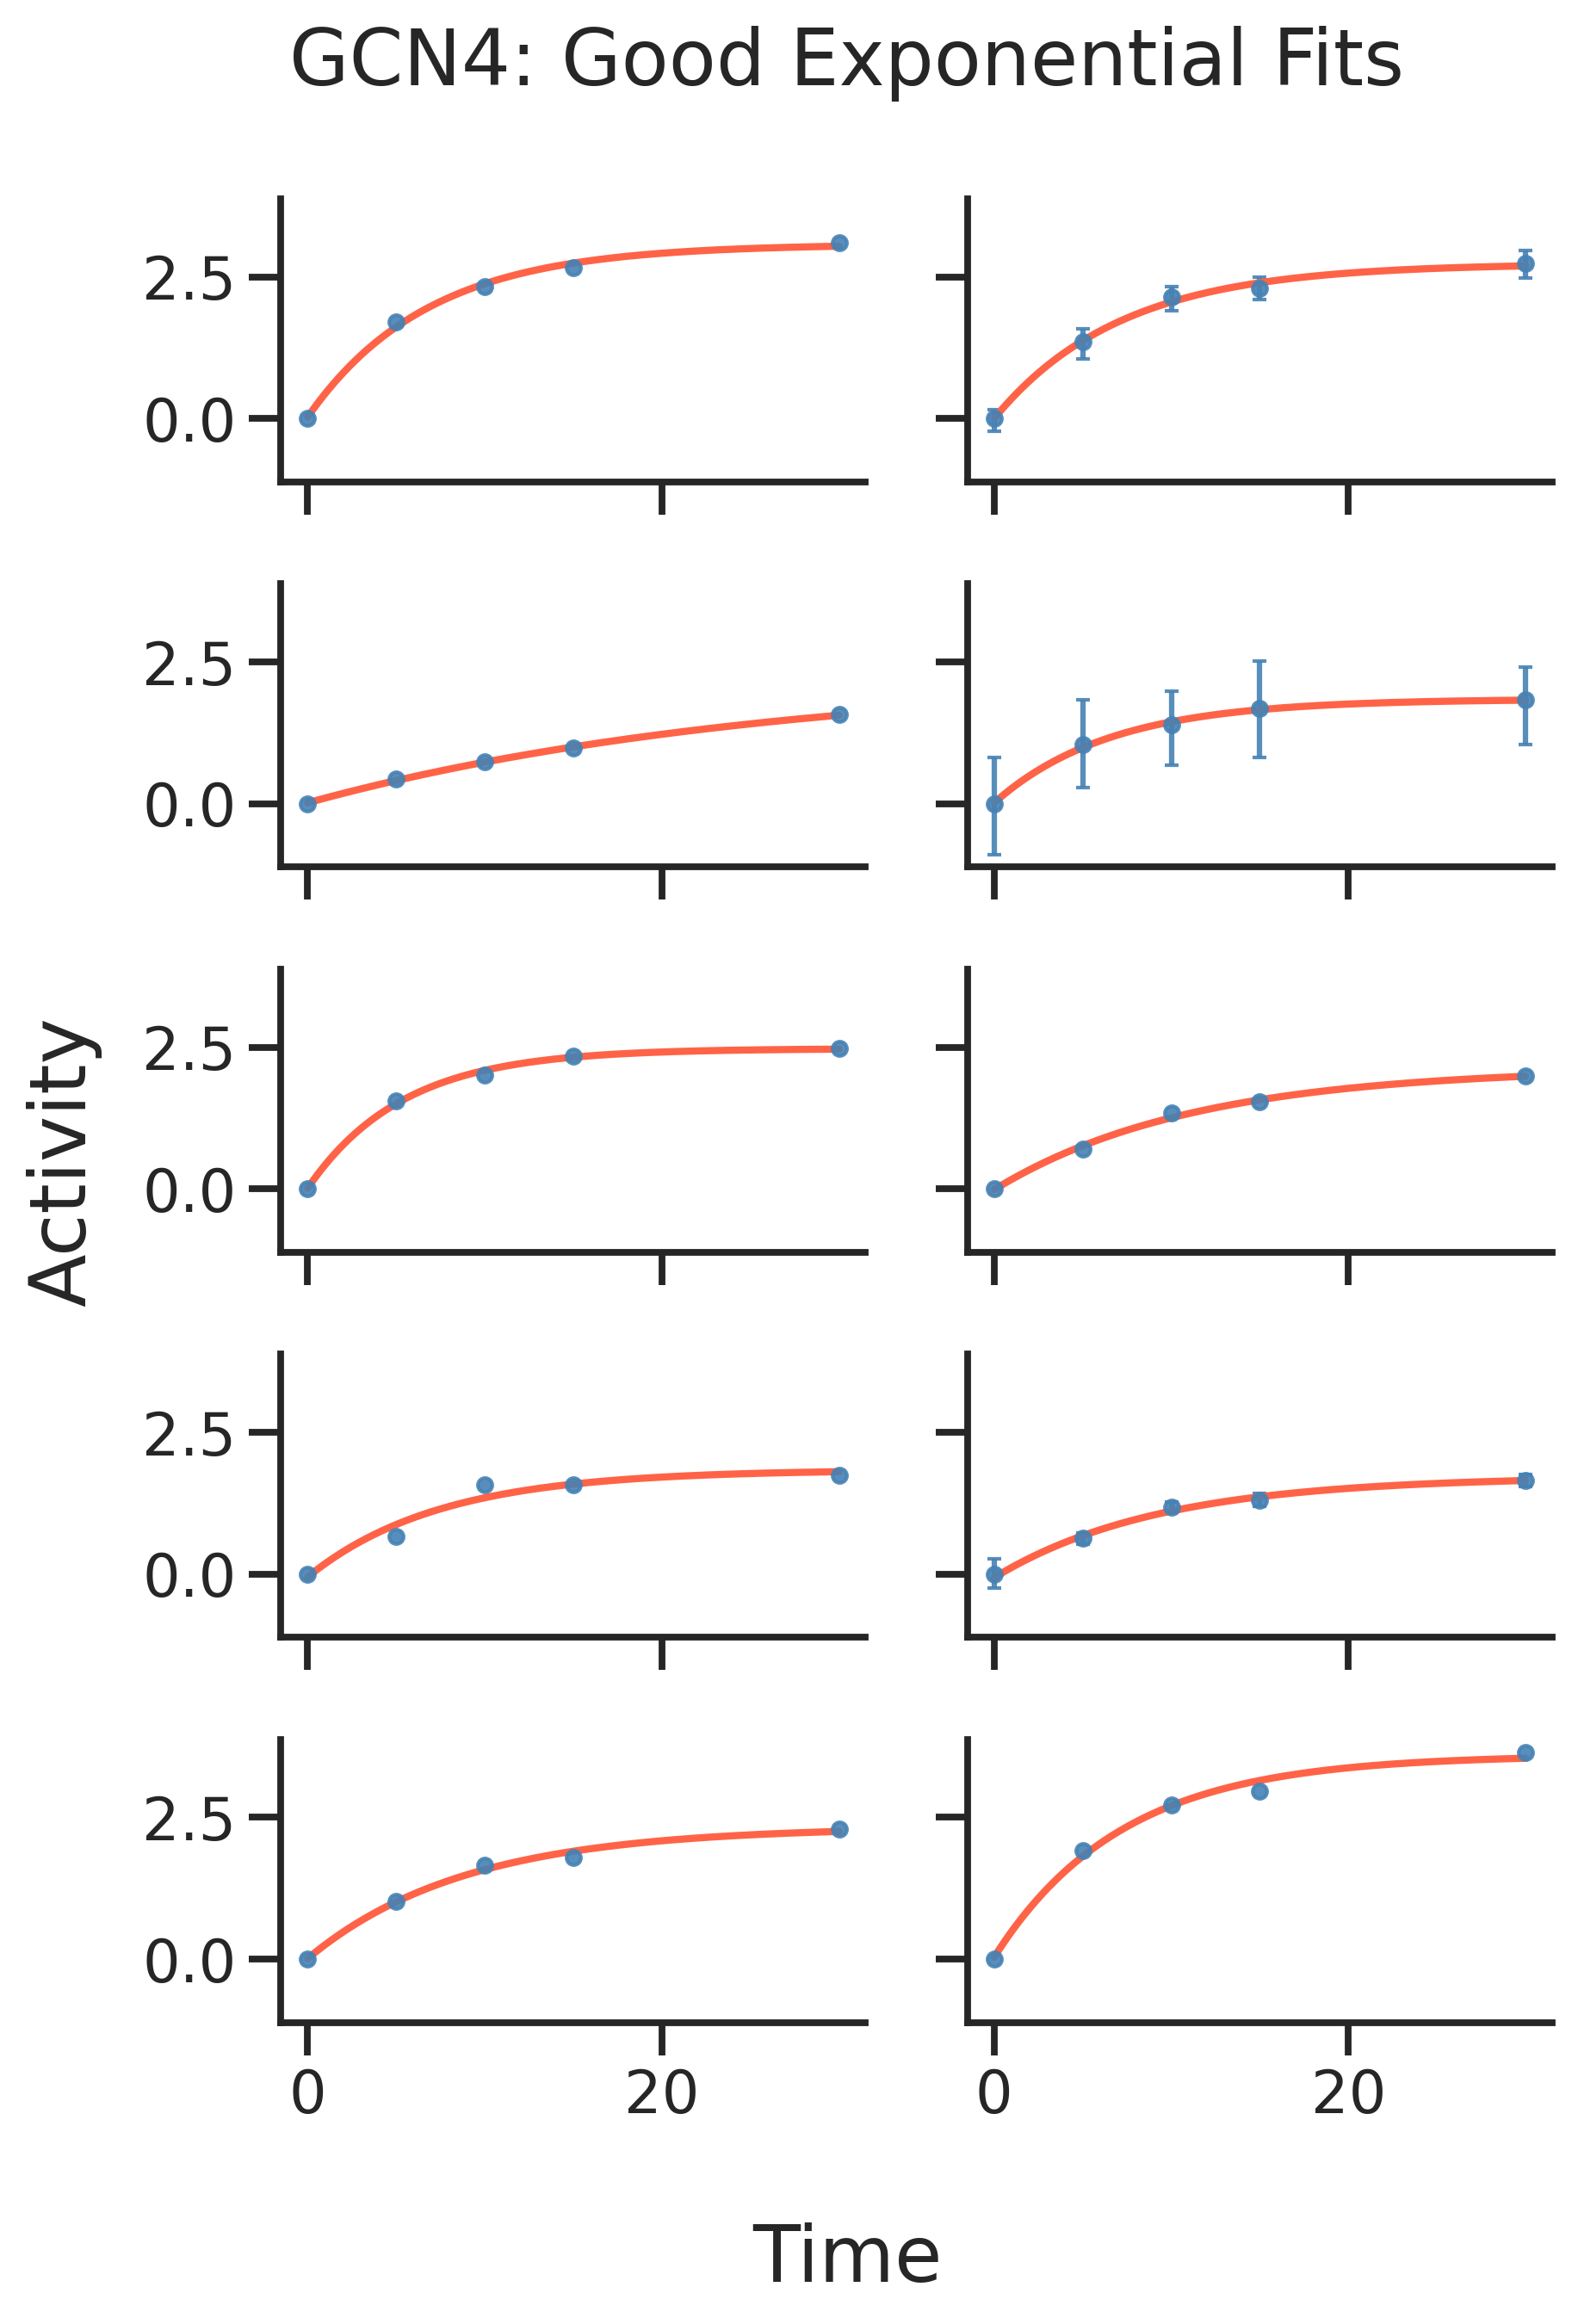

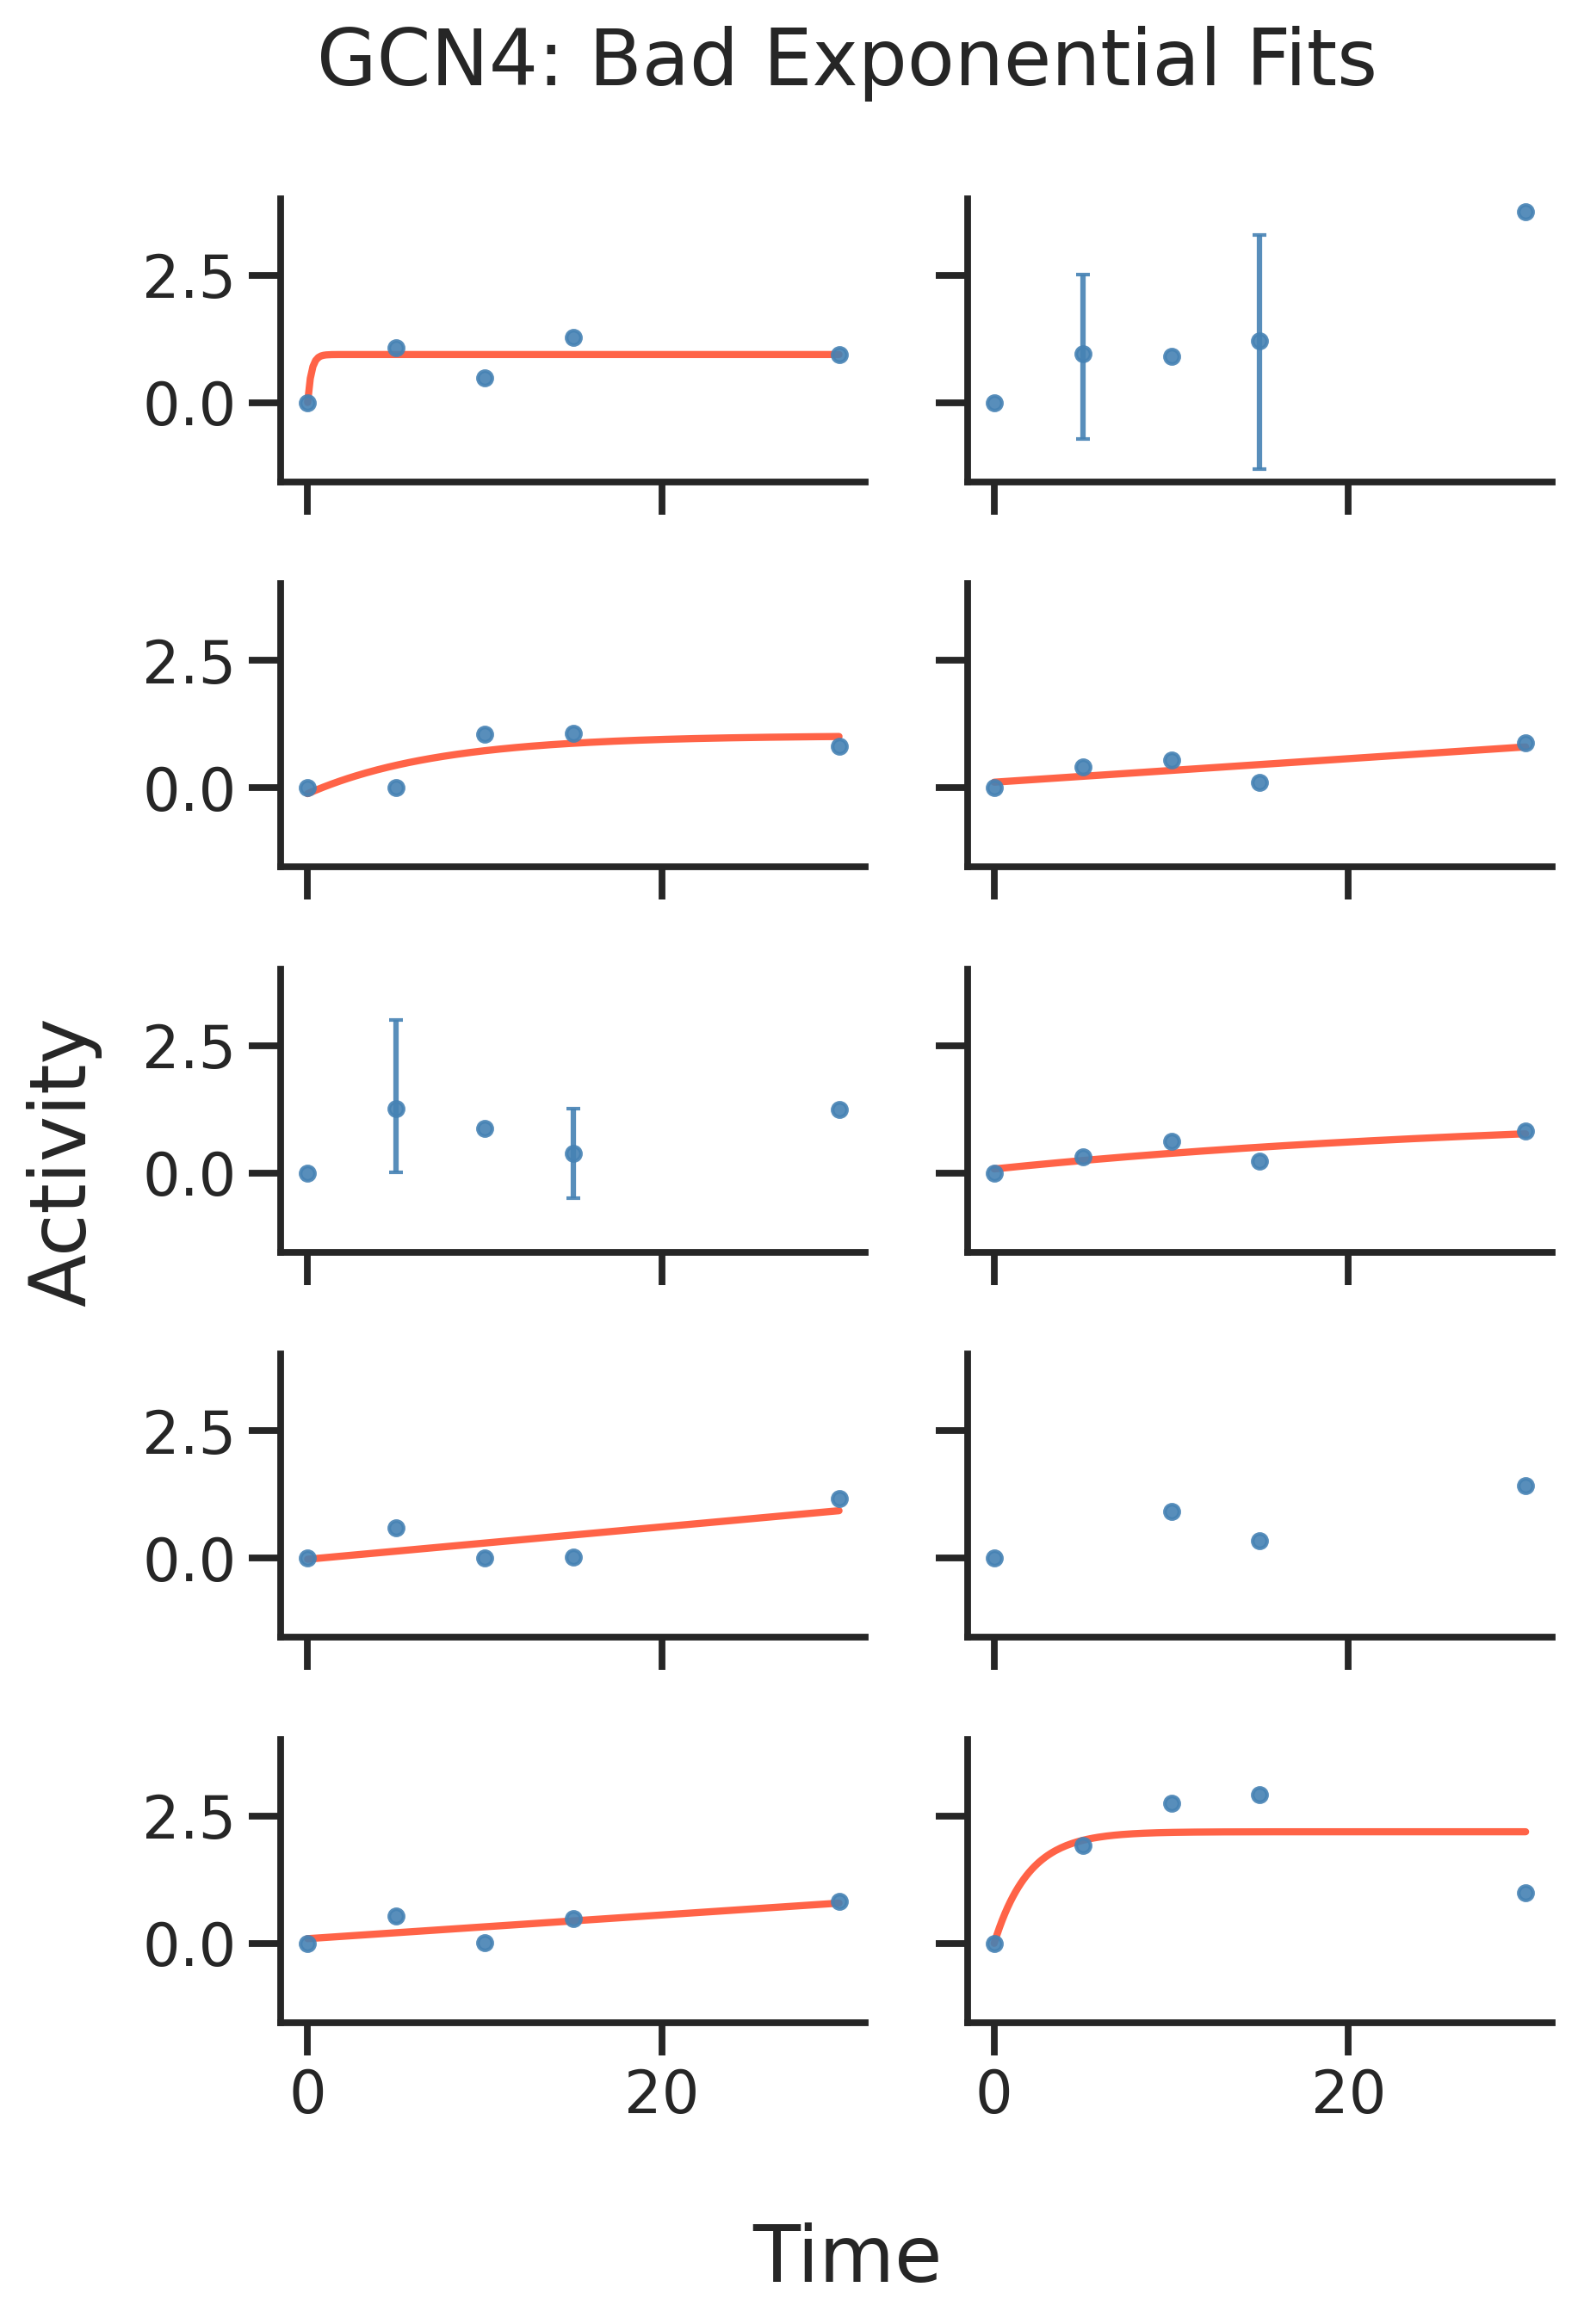

In [41]:
for df, title in zip([ok_norm, not_ok_norm], ["Good", "Bad"]):
    sample_adseqs = df.sample(16, random_state=42)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities_norm,
        fit_results=fit_results_norm,
        sample_adseqs=sample_adseqs,
        model_fn=rising_exponential,
        model_params=['A', 'k', 'C'],
        y_col='activity_norm',
        ci_low_col="ci_low_norm",
        ci_hi_col="ci_hi_norm",
        title=f'GCN4: {title} Exponential Fits'
    )

Pearson r = 0.019, p = 0.211
Spearman rho = 0.608, p = 0


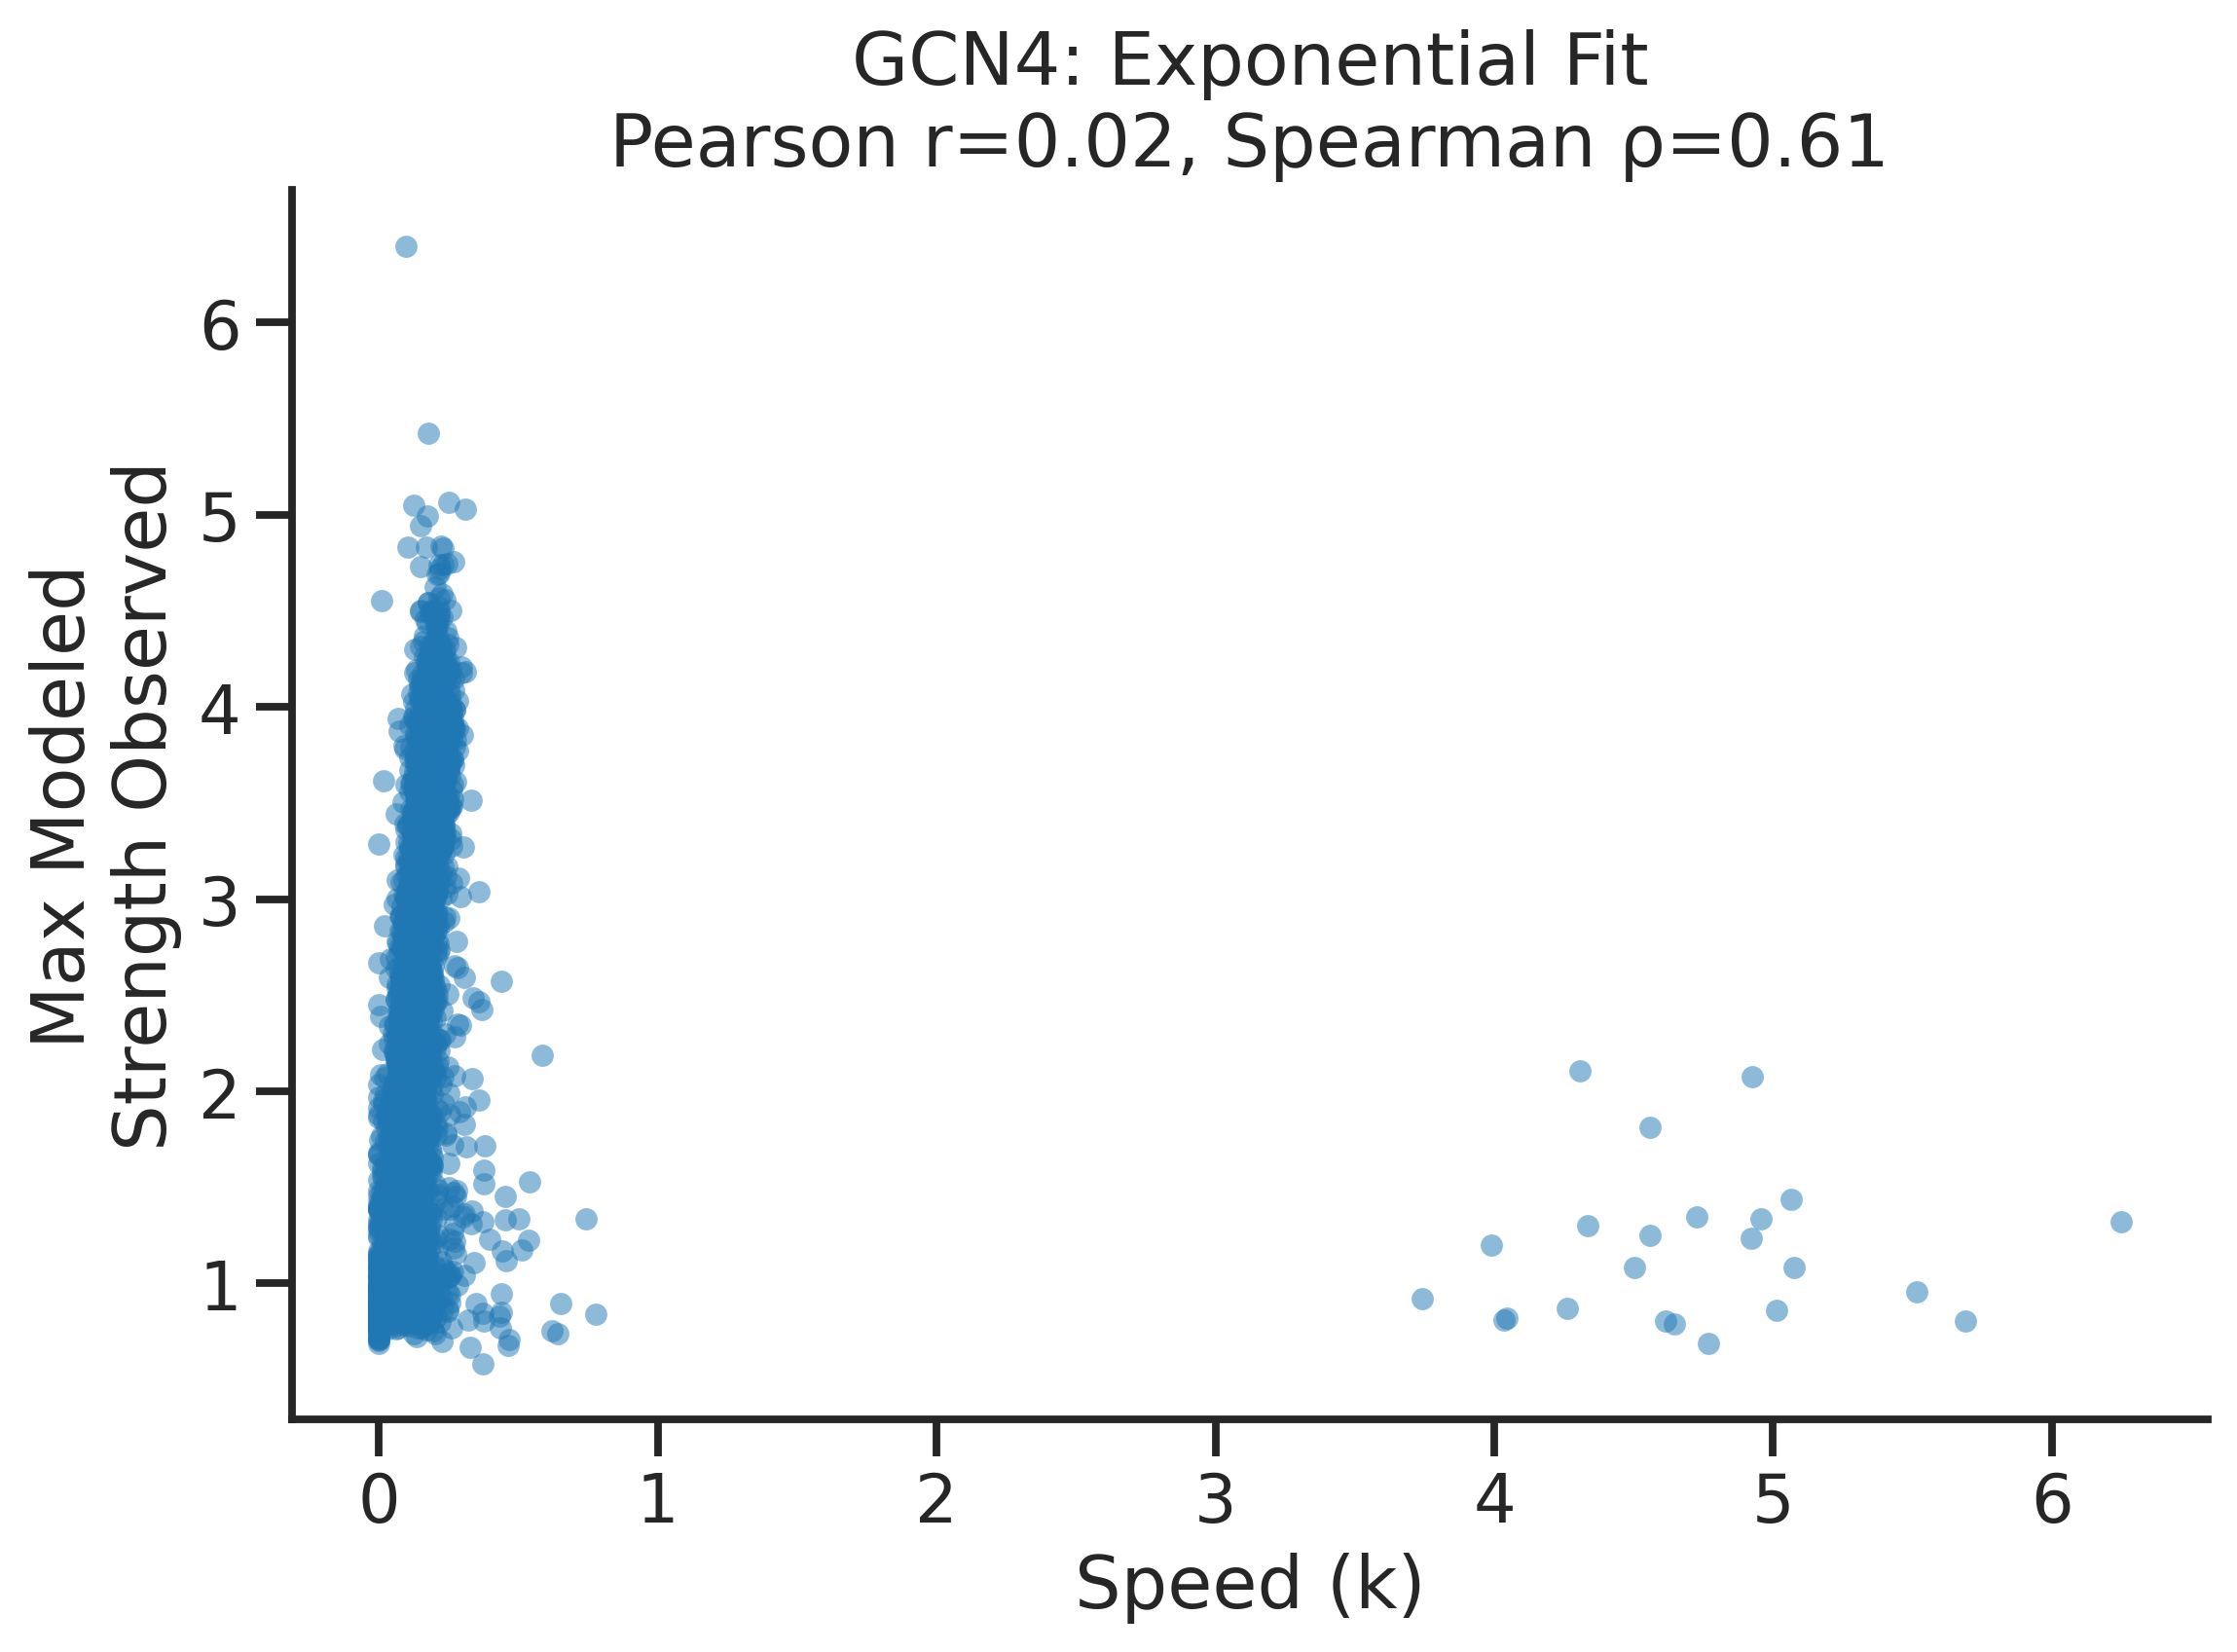

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok_norm['k'], ok_norm['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok_norm['k'], ok_norm['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [43]:
import numpy as np
import pandas as pd

# --- filter the valid range first ---
filtered = ok_norm[
    (ok_norm['k'] >= 0) & (ok['k'] <= 0.2) &
    (ok_norm['obs_max'] >= 0) & (ok_norm['obs_max'] <= 5)
].copy()

# --- 1. Similar A, different k ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.2  # ±0.3 SD around median

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) & (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('k')

# Pick two sequences with widely separated k
seq_simA_diffk = similar_A_sorted.iloc[[1, -2]]  # first and last k

# --- 2. Similar k, different A ---
k_target = filtered['k'].median()
k_tol = filtered['k'].std() * 0.2  # ±0.3 SD around median

similar_k = filtered[(filtered['k'] >= k_target - k_tol) & (filtered['k'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

# Pick two sequences with widely separated A
seq_simk_diffA = similar_k_sorted.iloc[[1, -2]]  # lowest and highest A

# --- Combine for inspection ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA])
to_plot

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
2545,NNHTITEDDLVFNSFIKNESPVLSELELVSTTSEFTTGIS,3.366918,0.875881,0.037554,0.017179,0.064576,0.129021,18.457536,8.443607,2.340173,10.581162,0.987291,ok,NaN
3721,SPSESYDTSPLYNGDDVSSDGQWYSLFPETNPDPEDSVSP,2.290992,0.069498,0.198747,0.015435,0.002971,0.054519,3.487587,0.270854,2.288067,3.486974,0.998296,ok,NaN
4408,VAPGTTGQAQTGWRQSFSTSSLQTANISNQDFPVFTTDPQ,0.784340,0.197909,0.117990,0.071618,0.042325,0.133046,5.874621,3.565814,0.803902,5.170341,0.905891,ok,NaN
3805,SSGYFSHDTSPLFADADLGSGHEQWESLFPTDPTPLPEVK,4.224388,0.220572,0.127864,0.016093,0.044604,0.153609,5.420990,0.682301,4.177823,5.170341,0.995410,ok,NaN


In [44]:
#to_plot.to_csv("../../../output/GCN4_speed_strength_diff_examples_for_CC.csv")

Pearson r = 0.019, p = 0.211
Spearman rho = 0.608, p = 0


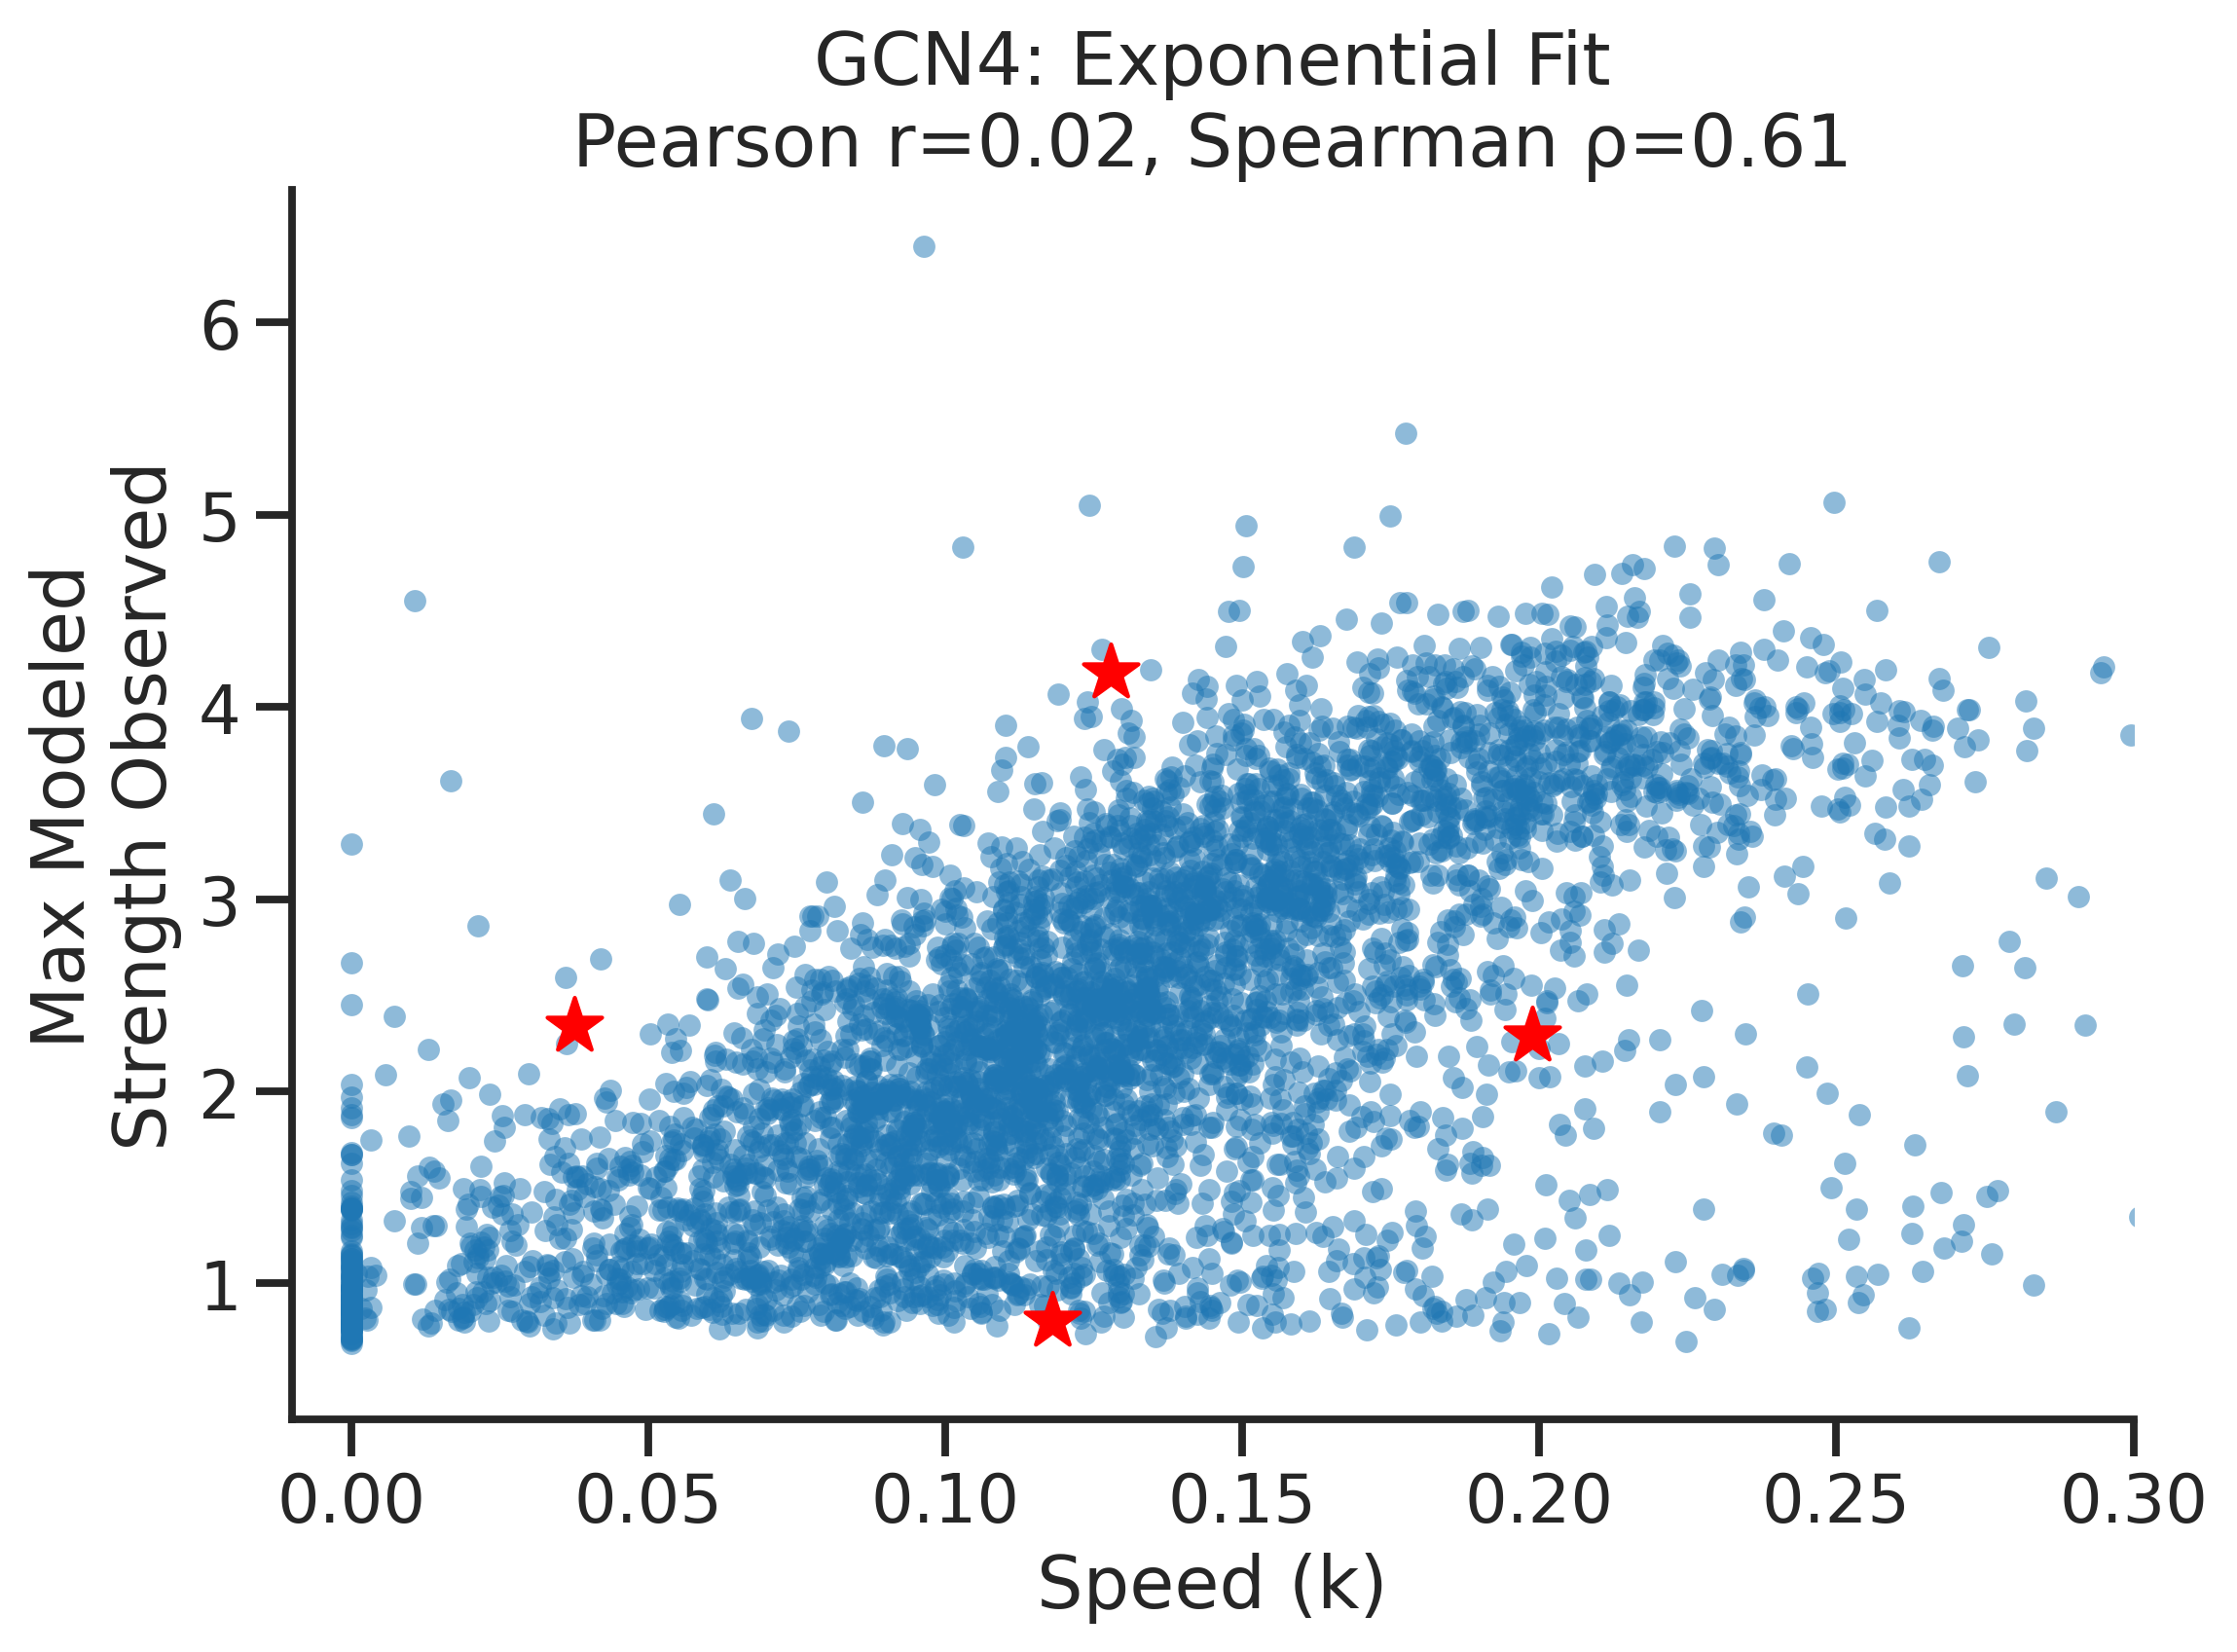

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok_norm['k'], ok_norm ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok_norm['k'], ok_norm['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['k'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)
ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

ax.set_xlim(-0.01, 0.3)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [46]:
 sns.color_palette('colorblind', n_colors=len(to_plot))

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

ValueError: Axis limits cannot be NaN or Inf

<Figure size 1920x1440 with 0 Axes>

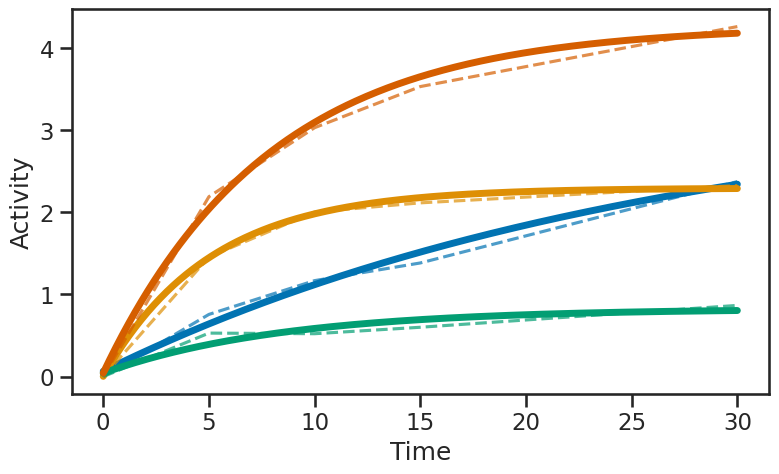

In [47]:
plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)
fig, ax = plt.subplots(figsize=(9,5))

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

for (_, row), color in zip(to_plot.iterrows(), colors):
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    ax.fill_between(t, y - sigma, y + sigma, color=color, alpha=0.1)
    ax.plot(t, y, color=color, markersize=4, alpha=0.7, linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
            color=color, linewidth=5, alpha=1,
            label=f"t½={row['t_half']:.1f}")

ax.set_xlabel('Time')
ax.set_ylabel('Activity')

# get lowest observed value across all plotted sequences
grps = activities_norm[activities_norm['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()
ax.set_ylim(bottom=y_min)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1,1), loc='upper right', ncols = 2)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

# --- first subplot: sequences 1 and 3 ---
for idx in [0, 1]:

    row = to_plot.iloc[idx]
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[0].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=4,
        alpha=0.9
    )

    axs[0].plot(
        t_fine,
        rising_exponential(t_fine, row['A'], row['k'], row['C']),
        color=colors[idx],
        linewidth=4,
        alpha=1,
        label=f"t½={row['t_half']:.1f}"
    )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].legend()
sns.despine(ax=axs[0])
axs[0].set_title("Similar Strengths, Different Speeds")

# --- second subplot: sequences 2 and 4 ---
for idx in [2, 3]:

    row = to_plot.iloc[idx]
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[1].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=4,
        alpha=0.9
    )

    axs[1].plot(
        t_fine,
        rising_exponential(t_fine, row['A'], row['k'], row['C']),
        color=colors[idx],
        linewidth=4,
        alpha=1,
        label=f"t½={row['t_half']:.1f}"
    )

axs[1].set_xlabel('Time')
axs[1].legend()
sns.despine(ax=axs[1])

# --- shared y-axis scaling ---
grps = activities_norm[activities_norm['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

axs[1].set_title("Similar Speeds, Different Strengths")

plt.suptitle("GCN4: Exponential Fit", y=0.912)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper')
sns.set_style('white')

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ok_norm.sample(4, random_state=92)['ADseq'].values
t_fine = np.linspace(0, activities_norm['time'].max(), 200)

pearson_corr, pearson_p   = pearsonr(ok_norm['k'], ok_norm['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm['obs_max'])

fig = plt.figure(figsize=(5,2.5), dpi=300)
outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25, figure=fig)

inner_gs = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=outer_gs[0], wspace=0.05, hspace=0.05
)

axes_left = []
ax0 = fig.add_subplot(inner_gs[0, 0])
axes_left.append(ax0)
for r in range(2):
    for c in range(2):
        if r == 0 and c == 0:
            continue
        ax = fig.add_subplot(inner_gs[r, c], sharex=ax0, sharey=ax0)
        axes_left.append(ax)

for ax, adseq in zip(axes_left, sample_adseqs):
    grp = activities_norm[activities_norm['ADseq'] == adseq].sort_values('time')
    t     = grp['time'].values
    y     = grp['activity_norm'].values
    sigma = grp['error'].values
    row_fit = fit_results_norm[fit_results_norm['ADseq'] == adseq].iloc[0]
    A, k, C = row_fit['A'], row_fit['k'], row_fit['C']

    ax.fill_between(t, y - sigma, y + sigma, color='steelblue', alpha=0.2)
    ax.plot(t, y, color='steelblue', linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, A, k, C), color='tomato', linewidth=1.25)
    
# hide inner tick labels
for ax in [axes_left[0], axes_left[1]]:
    ax.tick_params(labelbottom=False)
for ax in [axes_left[1], axes_left[3]]:
    ax.tick_params(labelleft=False)

# sup axis labels scoped to left block
left_bbox = outer_gs[0].get_position(fig)
fig.text(left_bbox.x0 + left_bbox.width / 2, left_bbox.y0 - 0.07,
         'Time', ha='center', va='top',
         fontsize=plt.rcParams['axes.labelsize'])
fig.text(left_bbox.x0 - 0.03, left_bbox.y0 + left_bbox.height / 2,
         'Activity', ha='right', va='center', rotation='vertical',
         fontsize=plt.rcParams['axes.labelsize'])

# legend
# data_patch = mpatches.Patch(color='steelblue', alpha=0.4, label='data ± SE')
# fit_line = mlines.Line2D([], [], color='tomato', linewidth=2,
#                           label='exponential fit:\n' + r'$A(1-e^{-\mathbf{k}t})+C$')
# axes_left[1].legend(handles=[data_patch, fit_line],
#                     loc='upper right', fontsize='small', bbox_to_anchor = (1.1,1.15), ncols = 2)

data_patch = mpatches.Patch(color='steelblue', alpha=0.4, label='data ± SE')
fit_line   = mlines.Line2D([], [], color='tomato', linewidth=2,
                            label='exponential fit:\n' + r'$A(1-e^{-\mathbf{k}t})+C$')

fig.legend(handles=[data_patch, fit_line],
           loc='upper right',
           bbox_to_anchor=(0.5,0.92),  # centered under 2x2
           fontsize='x-small',
           frameon=False,
           handlelength=1,
           columnspacing=0,
           handletextpad=0.4,
          labelspacing = 0.6)

# right scatter
ax_right = fig.add_subplot(outer_gs[1])
ax_right.scatter(ok_norm['k'], ok_norm['obs_max'], alpha=0.5, s=7, edgecolor='none')
ax_right.set_xlabel('Speed (k)', labelpad = -0.5)
ax_right.set_ylabel('Strength', labelpad = 0)

ax_right.text(0.05, 1.01,
              f'Spearman\nρ = {spearman_corr:.2f},\n\nPearson\nr = {pearson_corr:.2f}',
              transform=ax_right.transAxes, ha='left', va='top',
              fontsize='small', color = 'red')

# on one panel only (e.g. top-left), show the model equation
# axes_left[0].text(0.1,1,          # center of the panel
#     r'$\mathbf{A(1-e^{-kt})+C}$',
#     transform=axes_left[0].transAxes,
#     ha='left', va='top', fontsize='small', color='tomato')

# # on all panels, label k from the fit
# ax.text(0.05, 0.95, f'k = {k:.3f}',
#         transform=ax.transAxes, ha='left', va='top',
#         fontsize='x-small', color='tomato', fontweight='bold')

# tighten ticks on all left axes
for ax in axes_left:
    ax.tick_params(axis='x', pad=2, length=0)
    ax.tick_params(axis='y', pad=2, length=0)

# also on right
ax_right.tick_params(axis='x', pad=2, length=0)
ax_right.tick_params(axis='y', pad=2, length=0)
ax_right.set_xlim(-0.01, 0.3)
sns.despine(fig=fig)
plt.tight_layout(pad=0.1)
plt.show()